In [ ]:
pip install opencv-python torch torchvision numpy pandas scikit-image matplotlib pillow scipy scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 73.6 MB 5.2 MB/s eta 0:00:011
     |████████████████████████████████| 1.9 MB 9.5 MB/s eta 0:00:01
     |████████████████████████████████| 10.8 MB 23.4 MB/s eta 0:00:01
     |████████████████████████████████| 13.4 MB 23.2 MB/s eta 0:00:01
     |████████████████████████████████| 7.8 MB 42.6 MB/s eta 0:00:01
     |████████████████████████████████| 30.3 MB 12.5 MB/s eta 0:00:01
     |████████████████████████████████| 11.1 MB 18.7 MB/s eta 0:00:01
     |████████████████████████████████| 6.3 MB 29.2 MB/s eta 0:00:01
     |████████████████████████████████| 1.6 MB 47.0 MB/s eta 0:00:01
     |████████████████████████████████| 134 kB 19.8 MB/s eta 0:00:01
     |████████████████████████████████| 200 kB 27.1 MB/s eta 0:00:01
     |████████████████████████████████| 348 kB 23.4 MB/s eta 0:00:01
     |████████████████████████████████| 508 kB 19.2 MB/s eta 0:00:01
     |███████████████

In [14]:
import os
import cv2
import math
import torch
import random
import torchvision
import numpy as np
import pandas as pd
import torch.nn as nn
from datetime import date
from skimage import io, color
from torchvision import models
import skimage.morphology as mo
import matplotlib.pyplot as plt
import torch.nn.functional as F
from PIL import Image, ImageFilter
from scipy.ndimage import median_filter
from torch.utils.data import random_split, Dataset, DataLoader
import torchvision.transforms.functional as TF
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.autograd import Variable
from torchvision.utils import save_image

# 1. ELIMINAMOS la conexión a Drive (borramos de aquí 'from google.colab import drive')

# 2. DEFINIMOS tu carpeta local (cambia esto por tu ruta real en Windows o Mac)
ruta_local = r"/Volumes/Engineering/RangerLab/Newborn Project Data" 

# 3. LE DECIMOS al código que trabaje desde ahí
os.chdir(ruta_local)
print(f"Conectado a la carpeta local: {os.getcwd()}")

Conectado a la carpeta local: /Volumes/Engineering/RangerLab/Newborn Project Data


In [17]:
root_dir = '/Volumes/Engineering/RangerLab/Newborn Project Data/combined_cropped_images'

# Creamos los contadores
total_abd = 0
total_bicep = 0
total_quad = 0
total_imagenes = 0
total_bebes = 0

# 1. Entramos en la carpeta principal
for patient in os.listdir(root_dir):
    ruta_paciente = os.path.join(root_dir, patient)
    
    # Comprobamos que es la carpeta de un bebé
    if os.path.isdir(ruta_paciente):
        total_bebes += 1
        
        # 2. Entramos en las subcarpetas (ABD, BICEP, QUAD)
        for subcarpeta in os.listdir(ruta_paciente):
            ruta_subcarpeta = os.path.join(ruta_paciente, subcarpeta)
            
            if os.path.isdir(ruta_subcarpeta):
                # Contamos las imágenes ignorando los archivos ocultos de Mac (los que empiezan por punto)
                imagenes = [img for img in os.listdir(ruta_subcarpeta) if not img.startswith('.')]
                cantidad = len(imagenes)
                
                # Clasificamos según el nombre de la carpeta
                nombre_sub = subcarpeta.upper()
                if 'ABD' in nombre_sub:
                    total_abd += cantidad
                elif 'BICEP' in nombre_sub or 'BIC' in nombre_sub:
                    total_bicep += cantidad
                elif 'QUAD' in nombre_sub:
                    total_quad += cantidad
                
                # Sumamos al total general
                total_imagenes += cantidad

# 3. Imprimimos los resultados bien organizados
print(f"Total de bebés procesados: {total_bebes}")
print("-" * 30)
print(f"Ecografías de Abdomen (ABD):    {total_abd}")
print(f"Ecografías de Bíceps (BICEP):   {total_bicep}")
print(f"Ecografías de Cuádriceps (QUAD): {total_quad}")
print("=" * 30)
print(f"TOTAL REAL DE IMÁGENES:         {total_imagenes}")

Total de bebés procesados: 113
------------------------------
Ecografías de Abdomen (ABD):    419
Ecografías de Bíceps (BICEP):   422
Ecografías de Cuádriceps (QUAD): 486
TOTAL REAL DE IMÁGENES:         1327


In [18]:
root_dir = '/Volumes/Engineering/RangerLab/Newborn Project Data/combined_cropped_images'

# Aquí guardaremos la información de cada bebé
datos_pacientes = []

# Usamos sorted() para que los pacientes aparezcan en orden alfabético/numérico
for patient in sorted(os.listdir(root_dir)):
    ruta_paciente = os.path.join(root_dir, patient)
    
    # Comprobamos que sea una carpeta y no un archivo oculto del Mac
    if os.path.isdir(ruta_paciente) and not patient.startswith('.'):
        
        # Contadores individuales para este bebé
        abd = 0
        bicep = 0
        quad = 0
        
        for subcarpeta in os.listdir(ruta_paciente):
            ruta_subcarpeta = os.path.join(ruta_paciente, subcarpeta)
            
            if os.path.isdir(ruta_subcarpeta):
                # Contamos las imágenes ignorando los .DS_Store
                imagenes = [img for img in os.listdir(ruta_subcarpeta) if not img.startswith('.')]
                cantidad = len(imagenes)
                
                nombre_sub = subcarpeta.upper()
                if 'ABD' in nombre_sub:
                    abd += cantidad
                elif 'BICEP' in nombre_sub or 'BIC' in nombre_sub:
                    bicep += cantidad
                elif 'QUAD' in nombre_sub:
                    quad += cantidad
        
        # Añadimos los datos de este bebé a nuestra lista
        datos_pacientes.append({
            'ID Paciente': patient,
            'ABD': abd,
            'BICEP': bicep,
            'QUAD': quad,
            'Total Ecografías': abd + bicep + quad
        })

# Convertimos la lista en una tabla de Pandas
df_pacientes = pd.DataFrame(datos_pacientes)

# Configuramos Pandas para que al imprimir no corte la tabla si es muy larga
pd.set_option('display.max_rows', None)

# Imprimimos la tabla
print(df_pacientes)

    ID Paciente  ABD  BICEP  QUAD  Total Ecografías
0            10    4      4     5                13
1          1001    3      3     3                 9
2          1002    4      4     6                14
3          1003    4      3     6                13
4      10030618    4      3     3                10
5          1004    4      5     3                12
6          1005    3      3     3                 9
7          1006    3      3     6                12
8          1007    3      6     3                12
9          1008    3      3     2                 8
10         1009    3      3     6                12
11         1010    3      3     4                10
12         1011    3      3     3                 9
13         1012    3      5     3                11
14         1013    3      3     6                12
15         1015    3      3     6                12
16         1016    6      3     3                12
17         1017    3      6     3                12
18         1

# Get our labels from excel file and turn it into a dictionary

Read csv data into a dataframe and collect all patient 'Study ID'. Print out number of patients in csv file and in folder. Number of patients in folder determine our dataset size for training and testing.

In [ ]:
df = pd.read_csv('/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/Data_11.5.23_modified.csv')
patients = df['Study_ID']
folders = os.listdir('/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images') #cropped_images_bluethingremoved
print('Number of patients in csv file: ', len(patients))
print('Number of patients in folder: ', len(folders))

Number of patients in csv file:  65
Number of patients in folder:  65


Create two dictionary, using 'Study ID' as key, and ['FM', 'FFM', 'Weight_visit', 'Length_visit'] as value. Create the test dictionary from the training dictionary.

In [ ]:
labels_dict = df.set_index('Study_ID')[['FM', 'FFM', 'Weight_visit', 'Length_visit']].apply(list, axis=1).to_dict()
test_data = [17042418, 9021218, 35080318, 58041919, 65050619, 57032919, 50102518]#, , , 57032919, 67062119, 60042419, 44091318]
test_labels_dict = {k: labels_dict[k] for k in test_data if k in labels_dict}
for i in test_data:
  del labels_dict[i]
PATIENTS = [str(num) for num in test_data]
print(len(labels_dict))
print(len(test_labels_dict))

58
7


# Functions

In [ ]:
class PatientDataset(Dataset):
    def __init__(self, transform = None,
                 augmented_dataset = False, # Determine if we want to augment entire dataset instead of augmenting individual image
                 augment = 0, # this can be 0 (no augmentation), 5 (augment by 4 times plus original image), 8 and 15
                 threshold = False, # Remove all pixels under a certain threshold
                 speckle = False, # Apply median filter
                 despeckle = False, # Apply fast NL mean denoising
                 region_combination = "BAQ", # this can be B, A, Q, BA, BQ, AQ, BAQ
                 number_of_image = 3, # this can be 1, 2, 3, number of image for each region
                 crop = [1, 1, 1], # Only keep the x percentage of the image in the order of Abdomen, Biceps, and Quadriceps
                 output = "FM" # this can be FM or FFM, depending on which we want to predict
                 ):
        self.root_dir = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images' #cropped_images_bluethingremoved
        self.patients = os.listdir(self.root_dir)
        for data in test_data:
          self.patients.remove(str(data))
        self.transform = transform
        self.augment = augment
        self.threshold = threshold
        self.speckle = speckle
        self.augmented_dataset = augmented_dataset
        self.despeckle = despeckle
        self.region_combination = region_combination
        self.number_of_image = number_of_image
        self.crop = crop
        self.output = output

    def __len__(self):
        return len(self.patients)

    def __getitem__(self, idx):
        patient_id = self.patients[idx]
        patient_path = os.path.join(self.root_dir, patient_id)
        images = self.load_patient_data(patient_path)
        label_FM = labels_dict[int(patient_id)][0]
        label_FFM = labels_dict[int(patient_id)][1]
        if self.output == "FM":
          return images, label_FM, labels_dict[int(patient_id)][2], labels_dict[int(patient_id)][3]
        if self.output == "FFM":
          return images, label_FFM, labels_dict[int(patient_id)][2], labels_dict[int(patient_id)][3]

    def preprocess(self, img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, crop):
        image = Image.open(img_path)
        width, height = image.size
        crop_rectangle = (0, 0, width, round(height*crop))
        image = image.crop(crop_rectangle)
        if self.speckle:
          image = image.filter(ImageFilter.MedianFilter(size=MF_size))
        if self.threshold:
          image = torch.where(image < threshold/255, torch.tensor(0.0), image)
        if self.despeckle:
          image_np = np.array(image)
          despeckled_image = cv2.fastNlMeansDenoisingColored(image_np, None, h=10, templateWindowSize=7, searchWindowSize=21)
          image = Image.fromarray(despeckled_image)
        if not self.augmented_dataset:
          image = self.transform(image)
        images.append(image)

        ## Augmentation
        # Augment by 5 times
        if self.augment >= 5:
          imx = image
          imx = TF.hflip(imx)
          images.append(imx)
          imx = TF.vflip(imx)
          images.append(imx)
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        # Augment by 8 times
        if self.augment >= 8:
          imx = TF.vflip(imx)
          images.append(imx)
          angle = random.choice([15])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([45])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        # Augment by 15 times
        if self.augment >= 15:
          imx = image
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          imx = image
          angle = random.choice([-90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          imx = image
          angle = random.choice([-60])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-45])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-15])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([30])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([60])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        return images

    def load_patient_data(self, patient_path):
        images = []
        threshold = 100
        AB = 0
        BICEP = 0
        QUAD = 0
        MF_size = 5
        h = 10
        templateWindowSize = 7
        searchWindowSize = 21
        for img_file in os.listdir(patient_path):
          # Process Abdomen images
          if 'A' in self.region_combination and '_A' in img_file and AB < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images = self.preprocess(img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, self.crop[0])
              AB += 1
          # Process Bicep images
          elif 'B' in self.region_combination and '_B' in img_file and BICEP < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images = self.preprocess(img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, self.crop[1])
              BICEP += 1
          # Process Quad images
          elif 'Q' in self.region_combination and '_Q' in img_file and QUAD < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images = self.preprocess(img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, self.crop[2])
              QUAD += 1
        return images

In [ ]:
class AugmentedPatientDataset(Dataset):
    def __init__(self, original_dataset, transform = None, augmentations=5):
        self.original_dataset = original_dataset
        self.augmentations = augmentations
        self.transform = transform

    def __len__(self):
        # Multiply the length by the number of augmentations
        return len(self.original_dataset) * self.augmentations

    def __getitem__(self, idx):
        original_idx = idx // self.augmentations
        augmentation_state = idx % self.augmentations

        # Fetch the list of images and label for the original index
        images_list, label = self.original_dataset[original_idx]

        # Initialize an empty list to store augmented images
        augmented_images_list = []

        # Apply the same augmentation to each image in the list
        for image in images_list:
            augmented_image = self.apply_augmentation(image, augmentation_state)
            augmented_image = self.transform(augmented_image)
            augmented_images_list.append(augmented_image)

        return augmented_images_list, label

    def apply_augmentation(self, image, state):
        # Ensure image is a PIL Image for torchvision transforms
        if not isinstance(image, Image.Image):
            raise TypeError(f"Expected PIL Image, but got {type(image)}")

        # Apply augmentation based on state
        if state == 1:
            return TF.hflip(image)
        elif state == 2:
            return TF.vflip(image)
        elif state == 3:
            #angle = 30  # Example rotation
            angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
            return TF.rotate(image, angle)
        elif state == 4:
            #angle = 30  # Example rotation
            angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
            return TF.rotate(image, angle)
        # Add more augmentation states if needed
        return image  # Return the original image for state 0 or any undefined state

In [ ]:
def im_converterX(tensor):
  image = tensor.cpu().clone().detach().numpy()
  image = image.transpose(1,2,0)
  image = image * np.array((1, 1, 1))
  image = image.clip(0, 1)
  return image

In [ ]:
class MAPELoss(nn.Module):
    def __init__(self):
        super(MAPELoss, self).__init__()

    def forward(self, input, target):
        """
        Calculate the Mean Absolute Percentage Error (MAPE) between `input` and `target`.
        """
        return torch.mean(torch.abs((target - input) / target)) * 100

In [ ]:
class CustomLoss(nn.Module):
    def __init__(self, weight_mse=0.6, weight_l1=0.4):
        super(CustomLoss, self).__init__()
        self.weight_mse = weight_mse
        self.weight_l1 = weight_l1
        self.mse_loss = nn.MSELoss()
        self.l1_loss = nn.L1Loss()

    def forward(self, input, target):
        mse_loss = self.mse_loss(input, target)
        l1_loss = self.l1_loss(input, target)
        total_loss = self.weight_mse * mse_loss + self.weight_l1 * l1_loss
        return total_loss

In [ ]:
def custom_loss(output, target):
    mse_loss = nn.MSELoss()(output, target)
    penalty = torch.mean(F.relu(-output))  # Penalize negative predictions
    return mse_loss + penalty

In [ ]:
def training(epochs, criterion, lr, model, MODEL, adaptive = True, weight_length = False):
  if criterion == "MSE":
    criterion = nn.MSELoss()
  if criterion == "MAE":
    criterion = nn.L1Loss()
  if criterion == "MAPE":
    criterion = MAPELoss()
  if criterion == "Custom":
    criterion = CustomLoss()

  ### Optimizer
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  if adaptive == True:
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
  ## SGD
  # optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
  train_running_loss_history = []
  validation_running_loss_history =[]
  for e in range(epochs):
    train_running_loss = 0.0
    validation_running_loss = 0.0
    model.train()
    for ith_batch, batch in enumerate(train_loader):
      X_train = [image.to('cuda') for image in batch[0]]
      if weight_length == True:
        if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
          additional_data_train = torch.tensor([[batch[2].item(), batch[3].item()]]).to('cuda').float()
        elif MODEL == "UNet":
          weight = batch[2].to('cuda').float()[0]
          length = batch[3].to('cuda').float()[0]
          # Print weight and length for verification
          print(f"Epoch: {e + 1}, Batch: {ith_batch}, Weight: {weight.item()}, Length: {length.item()}")
        y_train = batch[1].to('cuda').float()[0]
        if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
          y_pred = model(X_train, weight, length)
        else:
          if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
            y_pred = model(X_train, weight, length)
          else:
            y_pred = model(X_train, weight, length)[0]
      else:
        y_train = batch[1].to('cuda').float()[0]
        if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
          y_pred = model(X_train)
        else:
          y_pred = model(X_train)[0]
      if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
        loss = criterion(y_pred, y_train)
      else:
        loss = custom_loss(y_pred, y_train)
      loss.backward()
      optimizer.step()
      if ith_batch % 5 == 0:
        print('Epoch: ', e + 1, 'Batch: ', ith_batch, 'Current Loss: ', loss.item())
      train_running_loss += loss.item()
    else:
      with torch.no_grad():
        model.eval()
        for ith_batch, batch in enumerate(test_loader):
          X_val = [image.to('cuda') for image in batch[0]]
          if weight_length == True:
            if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
              additional_data_train = torch.tensor([[batch[2].item(), batch[3].item()]]).to('cuda').float()
            elif MODEL == "UNet":
              weight = batch[2].to('cuda').float()[0]
              length = batch[3].to('cuda').float()[0]
            if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
              y_val = batch[1].to('cuda').float()
            else:
              y_val = batch[1].to('cuda').float()[0]
            if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
              y_out = model(X_val, weight, length)
            else:
              y_out = model(X_val, weight, length)[0]
          else:
            if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
              y_val = batch[1].to('cuda').float()
            else:
              y_val = batch[1].to('cuda').float()[0]
            if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
              y_out = model(X_val)
            else:
              y_out = model(X_val)[0]
            if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
              val_loss = criterion(y_out, y_val)
              # print(f'val_loss = {val_loss}')
              validation_running_loss += val_loss.item()
            else:
              val_loss = custom_loss(y_out, y_val)
              validation_running_loss += val_loss.item()
        print("================================================================================")
        print("Epoch {} completed".format(e + 1))
        train_epoch_loss = train_running_loss / len(train_loader)
        # print(f'validation_running_loss = {validation_running_loss}')
        validation_epoch_loss = validation_running_loss / len(test_loader)
        print("Average train loss is {}: ".format(train_epoch_loss))
        print("Average validation loss is {}".format(validation_epoch_loss))
        print("================================================================================")
        train_running_loss_history.append(train_epoch_loss)
        validation_running_loss_history.append(validation_epoch_loss)
    torch.cuda.empty_cache()
    if adaptive == True:
      scheduler.step()
  return train_running_loss_history, validation_running_loss_history

In [ ]:
class TestPatientDataset(Dataset):
    def __init__(self, transform = None,
                 augmented_dataset = False,
                 augment = 0, # this can be 0 (no augmentation), 5 (augment by 4 times plus original image), 8 and 15
                 threshold = False,
                 speckle = False,
                 despeckle = False,
                 region_combination = "BAQ",
                 number_of_image = 3,
                 crop = [1, 1, 1],
                 output = "FM"):
        self.root_dir = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images' #cropped_images_bluethingremoved
        self.patients = PATIENTS
        self.transform = transform
        self.augment = augment
        self.threshold = threshold
        self.speckle = speckle
        self.augmented_dataset = augmented_dataset
        self.despeckle = despeckle
        self.region_combination = region_combination
        self.number_of_image = number_of_image
        # Crop in the order of Abdomen, Biceps, and Quadriceps
        self.crop = crop
        self.output = output

    def __len__(self):
        return len(self.patients)

    def __getitem__(self, idx):
        patient_id = self.patients[idx]
        patient_path = os.path.join(self.root_dir, patient_id)
        images = self.load_patient_data(patient_path)
        if self.output == "FM":
          return images, test_labels_dict[int(patient_id)][0], test_labels_dict[int(patient_id)][2], test_labels_dict[int(patient_id)][3]
        if self.output == "FFM":
          return images, test_labels_dict[int(patient_id)][1], test_labels_dict[int(patient_id)][2], test_labels_dict[int(patient_id)][3]

    def preprocess(self, img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, crop):
        image = Image.open(img_path)
        width, height = image.size
        crop_rectangle = (0, 0, width, round(height*crop))
        image = image.crop(crop_rectangle)
        if self.speckle:
          image = image.filter(ImageFilter.MedianFilter(size=MF_size))
        if self.threshold:
          image = torch.where(image < threshold/255, torch.tensor(0.0), image)
        if self.despeckle:
          image_np = np.array(image)
          despeckled_image = cv2.fastNlMeansDenoisingColored(image_np, None, h=10, templateWindowSize=7, searchWindowSize=21)
          image = Image.fromarray(despeckled_image)
        if not self.augmented_dataset:
          image = self.transform(image)
        images.append(image)

        ## Augmentation
        if self.augment >= 5:
          imx = image
          imx = TF.hflip(imx)
          images.append(imx)
          imx = TF.vflip(imx)
          images.append(imx)
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        if self.augment >= 8:
          imx = TF.vflip(imx)
          images.append(imx)
          angle = random.choice([15])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([45])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        if self.augment >= 15:
          imx = image
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          imx = image
          angle = random.choice([-90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          imx = image
          angle = random.choice([-60])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-45])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-15])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([30])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([60])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        return images

    def load_patient_data(self, patient_path):
        images = []
        threshold = 100
        AB = 0
        BICEP = 0
        QUAD = 0
        MF_size = 5
        h = 10
        templateWindowSize = 7
        searchWindowSize = 21
        for img_file in os.listdir(patient_path):
          # Process Abdomen images
          if 'A' in self.region_combination and '_A' in img_file and AB < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images = self.preprocess(img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, self.crop[0])
              AB += 1
          # Process Bicep images
          elif 'B' in self.region_combination and '_B' in img_file and BICEP < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images = self.preprocess(img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, self.crop[1])
              BICEP += 1
          # Process Quad images
          elif 'Q' in self.region_combination and '_Q' in img_file and QUAD < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images = self.preprocess(img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, self.crop[2])
              QUAD += 1
        return images

In [ ]:
def mean_absolute_error(y_true, y_pred):
    return torch.mean(torch.abs(y_true - y_pred))
def mean_squared_error(y_true, y_pred):
    return torch.mean((y_true - y_pred)**2)
def root_mean_squared_error(y_true, y_pred):
    return math.sqrt(torch.mean((y_true - y_pred)**2))
def mean_absolute_percentage_error(y_true, y_pred):
    return torch.mean(torch.abs((y_true - y_pred) / y_true)) * 100
def r_squared(y_true, y_pred):
    ss_residual = torch.sum((y_true - y_pred)**2)
    ss_total = torch.sum((y_true - torch.mean(y_true))**2)
    r2 = 1 - (ss_residual / ss_total)
    return r2

# EfficientNet_B1

In [ ]:
!pip install efficientnet_pytorch
from efficientnet_pytorch import EfficientNet

## Set up EfficientNet-B1 model - Finetune

V1

In [ ]:
from efficientnet_pytorch import EfficientNet
class EfficientNetB1Model(nn.Module):
    def __init__(self):
        super(EfficientNetB1Model, self).__init__()
        # Initialize the EfficientNet B1 with pre-trained weights
        self.efficientnet = EfficientNet.from_pretrained('efficientnet-b1')

        # Freeze all the layers of the EfficientNet B1 model
        for param in self.efficientnet.parameters():
            param.requires_grad = False

        # The '_fc' attribute is the classification head of the EfficientNet which we will replace
        # Get the input features of the original fully connected layer
        num_features = self.efficientnet._fc.in_features

        # Replace the fully connected layer with an Identity, since we don't need its output
        self.efficientnet._fc = nn.Identity()

        # Additional layer for regression, only this layer's parameters will be trained
        self.regression = nn.Linear(num_features, 1)

    def forward(self, x_list):
        x_list = [x.squeeze(0) if x.dim() == 4 else x for x in x_list]
        # Process each image through EfficientNet B1 and collect the features
        features_list = [self.efficientnet(x.unsqueeze(0)) for x in x_list]

        # Aggregate the features (e.g., by averaging)
        aggregated_features = torch.mean(torch.stack(features_list), dim=0)

        # Pass the aggregated features through the regression layer
        output = self.regression(aggregated_features)
        return output.squeeze()

V2

In [ ]:
from efficientnet_pytorch import EfficientNet
class EfficientNetB1Model(nn.Module):
    def __init__(self):
        super(EfficientNetB1Model, self).__init__()
        # Initialize the EfficientNet B1 with pre-trained weights
        self.efficientnet = EfficientNet.from_pretrained('efficientnet-b1')

        # Freeze all the layers of the EfficientNet B1 model
        for param in self.efficientnet.parameters():
            param.requires_grad = False

        # The '_fc' attribute is the classification head of the EfficientNet which we will replace
        # Get the input features of the original fully connected layer
        num_features = self.efficientnet._fc.in_features

        # Replace the fully connected layer with an Identity, since we don't need its output
        self.efficientnet._fc = nn.Identity()

        # Additional layer for regression, only this layer's parameters will be trained
        self.regression = nn.Linear(num_features, 1)

    def forward(self, x_list):
        x_list = [x.squeeze(0) if x.dim() == 4 else x for x in x_list]
        # Process each image through EfficientNet B1 and collect the features
        features_list = [self.efficientnet(x.unsqueeze(0)) for x in x_list]

        # Aggregate the features (e.g., by averaging)
        aggregated_features = torch.mean(torch.stack(features_list), dim=0)

        # Pass the aggregated features through the regression layer
        output = self.regression(aggregated_features)
        return output.squeeze()

In [ ]:
MODEL = "EffNet_FT"
model = EfficientNetB1Model().to('cuda')

Loaded pretrained weights for efficientnet-b1


EffNet Custom Loss compatibe training

In [ ]:
def training(epochs, criterion, lr, model, MODEL, adaptive = True, weight_length = False):
  if criterion == "MSE":
    criterion = nn.MSELoss()
  if criterion == "MAE":
    criterion = nn.L1Loss()
  if criterion == "MAPE":
    criterion = MAPELoss()
  if criterion == "Custom":
    criterion = CustomLoss()

  ### Optimizer
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  if adaptive == True:
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
  ## SGD
  # optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
  train_running_loss_history = []
  validation_running_loss_history =[]
  for e in range(epochs):
    train_running_loss = 0.0
    validation_running_loss = 0.0
    model.train()
    for ith_batch, batch in enumerate(train_loader):
      X_train = [image.to('cuda') for image in batch[0]]
      if weight_length == True:
        if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
          additional_data_train = torch.tensor([[batch[2].item(), batch[3].item()]]).to('cuda').float()
        elif MODEL == "UNet":
          weight = batch[2].to('cuda').float()[0]
          length = batch[3].to('cuda').float()[0]
          # Print weight and length for verification
          print(f"Epoch: {e + 1}, Batch: {ith_batch}, Weight: {weight.item()}, Length: {length.item()}")
        y_train = batch[1].to('cuda').float()[0]
        if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
          y_pred = model(X_train, weight, length)
        else:
          if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
            y_pred = model(X_train, weight, length)
          else:
            y_pred = model(X_train, weight, length)[0]
      else:
        y_train = batch[1].to('cuda').float()[0]
        if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
          y_pred = model(X_train)
        else:
          y_pred = model(X_train)[0]
      if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
        loss = criterion(y_pred, y_train)
      else:
        loss = custom_loss(y_pred, y_train)
      loss.backward()
      optimizer.step()
      if ith_batch % 5 == 0:
        print('Epoch: ', e + 1, 'Batch: ', ith_batch, 'Current Loss: ', loss.item())
      train_running_loss += loss.item()
    else:
      with torch.no_grad():
        model.eval()
        for ith_batch, batch in enumerate(test_loader):
          X_val = [image.to('cuda') for image in batch[0]]
          if weight_length == True:
            if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
              additional_data_train = torch.tensor([[batch[2].item(), batch[3].item()]]).to('cuda').float()
            elif MODEL == "UNet":
              weight = batch[2].to('cuda').float()[0]
              length = batch[3].to('cuda').float()[0]
            if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
              y_val = batch[1].to('cuda').float()
            else:
              y_val = batch[1].to('cuda').float()[0]
            if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
              y_out = model(X_val, weight, length)
            else:
              y_out = model(X_val, weight, length)[0]
          else:
            if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
              y_val = batch[1].to('cuda').float()
            else:
              y_val = batch[1].to('cuda').float()[0]
            if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
              y_out = model(X_val)
            else:
              y_out = model(X_val)[0]
            if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
              val_loss = criterion(y_out, y_val)
              # print(f'val_loss = {val_loss}')
              validation_running_loss += val_loss.item()
            else:
              val_loss = custom_loss(y_out, y_val)
              validation_running_loss += val_loss.item()
        print("================================================================================")
        print("Epoch {} completed".format(e + 1))
        train_epoch_loss = train_running_loss / len(train_loader)
        # print(f'validation_running_loss = {validation_running_loss}')
        validation_epoch_loss = validation_running_loss / len(test_loader)
        print("Average train loss is {}: ".format(train_epoch_loss))
        print("Average validation loss is {}".format(validation_epoch_loss))
        print("================================================================================")
        train_running_loss_history.append(train_epoch_loss)
        validation_running_loss_history.append(validation_epoch_loss)
    torch.cuda.empty_cache()
    if adaptive == True:
      scheduler.step()
  return train_running_loss_history, validation_running_loss_history

EffNet grad-cam compatibility

In [ ]:
def training(epochs, criterion, lr, model, MODEL, adaptive=True, weight_length=False):
    if criterion == "MSE":
        criterion = nn.MSELoss()
    elif criterion == "MAE":
        criterion = nn.L1Loss()
    elif criterion == "MAPE":
        criterion = MAPELoss()
    elif criterion == "Custom":
        criterion = CustomLoss()

    model = model.to('cuda')
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    if adaptive:
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    train_running_loss_history = []
    validation_running_loss_history = []

    for e in range(epochs):
        train_running_loss = 0.0
        validation_running_loss = 0.0
        model.train()

        for ith_batch, batch in enumerate(train_loader):
            # Prepare images
            if isinstance(batch[0], torch.Tensor):
                X_train = batch[0].to('cuda').float()
            else:
                X_train = torch.stack([img.to('cuda').float() for img in batch[0]])

            if X_train.dim() == 5:
                X_train = X_train.squeeze(1)  # shape: (num_images, 3, H, W)

            # Targets
            y_train = batch[1].to('cuda').float()
            if y_train.dim() == 0:
                y_train = y_train.view(1)

            # Optional inputs
            if weight_length:
                if MODEL in ["EffNet_LP", "EffNet_FT"]:
                    weight = batch[2].to('cuda').float().view(1)
                    length = batch[3].to('cuda').float().view(1)
                    y_pred = model(X_train, weight, length)
                else:
                    weight = batch[2].to('cuda').float().view(1)
                    length = batch[3].to('cuda').float().view(1)
                    y_pred = model(X_train, weight, length)[0]
            else:
                if MODEL in ["EffNet_LP", "EffNet_FT"]:
                    y_pred = model(X_train)
                else:
                    y_pred = model(X_train)[0]

            if y_pred.dim() == 0:
                y_pred = y_pred.view(1)

            loss = criterion(y_pred, y_train)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if ith_batch % 5 == 0:
                print('Epoch: ', e + 1, 'Batch: ', ith_batch, 'Current Loss: ', loss.item())

            train_running_loss += loss.item()

        # Validation
        with torch.no_grad():
            model.eval()
            for ith_batch, batch in enumerate(test_loader):
                if isinstance(batch[0], torch.Tensor):
                    X_val = batch[0].to('cuda').float()
                else:
                    X_val = torch.stack([img.to('cuda').float() for img in batch[0]])

                if X_val.dim() == 5:
                    X_val = X_val.squeeze(1)

                y_val = batch[1].to('cuda').float()
                if y_val.dim() == 0:
                    y_val = y_val.view(1)

                if weight_length:
                    if MODEL in ["EffNet_LP", "EffNet_FT"]:
                        weight = batch[2].to('cuda').float().view(1)
                        length = batch[3].to('cuda').float().view(1)
                        y_out = model(X_val, weight, length)
                    else:
                        weight = batch[2].to('cuda').float().view(1)
                        length = batch[3].to('cuda').float().view(1)
                        y_out = model(X_val, weight, length)[0]
                else:
                    if MODEL in ["EffNet_LP", "EffNet_FT"]:
                        y_out = model(X_val)
                    else:
                        y_out = model(X_val)[0]

                if y_out.dim() == 0:
                    y_out = y_out.view(1)

                val_loss = criterion(y_out, y_val)
                validation_running_loss += val_loss.item()

        train_epoch_loss = train_running_loss / len(train_loader)
        validation_epoch_loss = validation_running_loss / len(test_loader)

        print("================================================================================")
        print("Epoch {} completed".format(e + 1))
        print("Average train loss is {}: ".format(train_epoch_loss))
        print("Average validation loss is {}".format(validation_epoch_loss))
        print("================================================================================")

        train_running_loss_history.append(train_epoch_loss)
        validation_running_loss_history.append(validation_epoch_loss)

        torch.cuda.empty_cache()
        if adaptive:
            scheduler.step()

    return train_running_loss_history, validation_running_loss_history


## Set up EfficientNet-B1 model - Linear Probing

In [ ]:
class EfficientNetB1Model(nn.Module):
    def __init__(self):
        super(EfficientNetB1Model, self).__init__()
        # Initialize the EfficientNet B1 with pre-trained weights
        self.efficientnet = EfficientNet.from_pretrained('efficientnet-b1')

        # Freeze all the layers of the EfficientNet B1 model
        for param in self.efficientnet.parameters():
            param.requires_grad = False

        # The '_fc' attribute is the classification head of the EfficientNet which we will replace
        # Get the input features of the original fully connected layer
        num_features = self.efficientnet._fc.in_features

        # Replace the fully connected layer with an Identity, since we don't need its output
        self.efficientnet._fc = nn.Identity()

        # Additional layer for regression, only this layer's parameters will be trained
        self.regression = nn.Linear(num_features, 1)

    def forward(self, x_list):
        x_list = [x.squeeze(0) if x.dim() == 4 else x for x in x_list]
        # Process each image through EfficientNet B1 and collect the features
        features_list = [self.efficientnet(x.unsqueeze(0)) for x in x_list]

        # Aggregate the features (e.g., by averaging)
        aggregated_features = torch.mean(torch.stack(features_list), dim=0)

        # Pass the aggregated features through the regression layer
        output = self.regression(aggregated_features)
        return output.squeeze()

In [ ]:
MODEL = "EffNet_LP"
model = EfficientNetB1Model().to('cuda')

# Resnet18

## Set up Resnet 18 - Finetune

In [ ]:
class ResNet18Model(nn.Module):
    def __init__(self):
        super(ResNet18Model, self).__init__()
        self.resnet = models.resnet18(pretrained = False)
        # Replace the last fully connected layer
        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()  # We will handle the final regression separately

        # Additional layer for regression
        self.regression = nn.Linear(num_features, 1)

    def forward(self, x_list):
        x_list = [x.squeeze(0) if x.dim() == 4 else x for x in x_list]
        # Process each image through ResNet-101 and collect the features
        features_list = [self.resnet(x.unsqueeze(0)) for x in x_list]

        # Aggregate the features (e.g., by averaging)
        aggregated_features = torch.mean(torch.stack(features_list), dim=0)

        # Pass the aggregated features through the regression layer
        output = self.regression(aggregated_features)
        return output.squeeze()

In [ ]:
MODEL = "ResNet18_FT"
model = ResNet18Model().to('cuda')

## Set up Resnet 18 - Linear Probing

In [ ]:
class ResNet18Model(nn.Module):
    def __init__(self):
        super(ResNet18Model, self).__init__()
        # Initialize the ResNet-18
        self.resnet = models.resnet18()  # assuming you want to use the pretrained weights

        # Freeze all the layers of the ResNet-18 model
        for param in self.resnet.parameters():
            param.requires_grad = False

        num_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()  # We will handle the final regression separately

        self.regression = nn.Linear(num_features, 1)

    def forward(self, x_list):
        x_list = [x.squeeze(0) if x.dim() == 4 else x for x in x_list]
        # Process each image through ResNet-18 and collect the features
        features_list = [self.resnet(x.unsqueeze(0)) for x in x_list]

        # Aggregate the features (e.g., by averaging)
        aggregated_features = torch.mean(torch.stack(features_list), dim=0)

        # Pass the aggregated features through the regression layer
        output = self.regression(aggregated_features)
        return output.squeeze()

In [ ]:
MODEL = "ResNet18_LP"
model = ResNet18Model().to('cuda')

# UNet

In [ ]:
class double_conv(nn.Module):
  '''(conv => BN => ReLU) * 2'''
  def __init__(self, in_ch, out_ch):
    super(double_conv, self).__init__()
    self.conv = nn.Sequential(
      nn.Conv2d(in_ch, out_ch, 3, padding=1),
      nn.BatchNorm2d(out_ch),
      #nn.Dropout2d(0.7),
      nn.LeakyReLU(0.1, inplace=True),
      nn.Conv2d(out_ch, out_ch, 3, padding=1),
      nn.BatchNorm2d(out_ch),
      #nn.Dropout2d(0.77),
      nn.LeakyReLU(0.1, inplace=True),
    )

  def forward(self, x):
    x = self.conv(x)
    return x

class inconv(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(inconv, self).__init__()
    self.conv = double_conv(in_ch, out_ch)

  def forward(self, x):
    x = self.conv(x)
    return x

class down(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(down, self).__init__()
    self.mpconv = nn.Sequential(
        nn.MaxPool2d(2),
        double_conv(in_ch, out_ch)
    )

  def forward(self, x):
    x = self.mpconv(x)
    return x


class up(nn.Module):
  def __init__(self, in_ch, out_ch, bilinear=False):
    super(up, self).__init__()
    if bilinear: # Upsampling will not be learnable
      self.up = nn.Upsample(
        scale_factor=2, mode='bilinear', align_corners=True)
    else:  # it will be learnable here
      self.up = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, kernel_size=2, stride=2)
    self.conv = double_conv(in_ch, out_ch)

  def forward(self, x1, x2):
    x1 = self.up(x1)
    # input is CHW
    diff1 = x2.shape[2]-x1.shape[2]
    diff2 = x2.shape[3]-x1.shape[3]
    x1 = F.pad(x1, pad=(diff1//2, diff1-diff1//2, diff2//2, diff2-diff2//2))
    x = torch.cat([x2, x1], dim=1)
    x = self.conv(x)
    return x


class outconv(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(outconv, self).__init__()
    self.conv = nn.Conv2d(in_ch, out_ch, 1)

  def forward(self, x):
    x = self.conv(x)
    return x

class UNet(nn.Module):
  def __init__(self, n_channels, n_classes):
    super(UNet, self).__init__()
    self.inc = inconv(n_channels, 64)
    self.down1 = down(64, 128)
    self.down2 = down(128, 256)
    self.down3 = down(256, 512)
    self.down4 = down(512, 512)
    self.up1 = up(1024, 256, bilinear = True) # upsampling weights are made learnable
    self.up2 = up(512, 128, bilinear = True)
    self.up3 = up(256, 64, bilinear = True)
    self.up4 = up(128, 64, bilinear = True)
    self.outc = outconv(64, n_classes)
    self.dropout = torch.nn.Dropout2d(0.1)
    self.flatten = nn.Flatten()
    self.linear1 = nn.Linear(256*256, 1)
    self.linear2 = nn.Linear(2*1, 1)
    self.linear3 = nn.Linear(2*1+2, 1)
    self.apply(self._init_weights)

    #self.linear2 = nn.Linear(2, 1) # 2*3 for 3 body parts, 2*2 for 2 body parts, 2*1 for 1 body part
    #self.linear3 = nn.Linear(2*3+2, 1)
    self.apply(self._init_weights)

  def forward(self, x, weight = None, length = None):
    outputs = []
    for image in x:
      x = image.float()
      x1 = self.inc(x)
      x2 = self.down1(x1)
      x2 = self.dropout(x2)
      x3 = self.down2(x2)
      x4 = self.down3(x3)
      x5 = self.down4(x4)
      x = self.up1(x5, x4)
      x = self.up2(x, x3)
      x = self.dropout(x)
      x = self.up3(x, x2)
      x = self.dropout(x)
      x = self.up4(x, x1)
      x = self.outc(x)
      x = torch.sigmoid(x)
      x = self.flatten(x)
      x = self.linear1(x)
      outputs.append(x)
    # ## For weight and length
    # # outputs.append(weight)
    # # outputs.append(length)
    # outputs = torch.tensor(outputs).to('cuda')
    # outputs = self.linear2(outputs)

    outputs = torch.tensor(outputs).to('cuda')


    try:
      outputs = self.linear2(outputs)
    except:
      outputs = self.linear3(outputs)
    return outputs
  def _init_weights(self, module):
    if isinstance(module, nn.Conv2d) or isinstance(module, nn.ConvTranspose2d):
        nn.init.uniform_(module.weight, a=0.0, b=1.0)
        if module.bias is not None:
            nn.init.constant_(module.bias, 0.1)


In [ ]:
MODEL = "UNet"
model = UNet(3, 1).cuda()

# UNet with weight/length

In [ ]:
class double_conv(nn.Module):
  '''(conv => BN => ReLU) * 2'''
  def __init__(self, in_ch, out_ch):
    super(double_conv, self).__init__()
    self.conv = nn.Sequential(
      nn.Conv2d(in_ch, out_ch, 3, padding=1),
      nn.BatchNorm2d(out_ch),
      #nn.Dropout2d(0.7),
      nn.LeakyReLU(0.1, inplace=True),
      nn.Conv2d(out_ch, out_ch, 3, padding=1),
      nn.BatchNorm2d(out_ch),
      #nn.Dropout2d(0.77),
      nn.LeakyReLU(0.1, inplace=True),
    )

  def forward(self, x):
    x = self.conv(x)
    return x

class inconv(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(inconv, self).__init__()
    self.conv = double_conv(in_ch, out_ch)

  def forward(self, x):
    x = self.conv(x)
    return x

class down(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(down, self).__init__()
    self.mpconv = nn.Sequential(
        nn.MaxPool2d(2),
        double_conv(in_ch, out_ch)
    )

  def forward(self, x):
    x = self.mpconv(x)
    return x


class up(nn.Module):
  def __init__(self, in_ch, out_ch, bilinear=False):
    super(up, self).__init__()
    if bilinear: # Upsampling will not be learnable
      self.up = nn.Upsample(
        scale_factor=2, mode='bilinear', align_corners=True)
    else:  # it will be learnable here
      self.up = nn.ConvTranspose2d(in_ch // 2, in_ch // 2, kernel_size=2, stride=2)
    self.conv = double_conv(in_ch, out_ch)

  def forward(self, x1, x2):
    x1 = self.up(x1)
    # input is CHW
    diff1 = x2.shape[2]-x1.shape[2]
    diff2 = x2.shape[3]-x1.shape[3]
    x1 = F.pad(x1, pad=(diff1//2, diff1-diff1//2, diff2//2, diff2-diff2//2))
    x = torch.cat([x2, x1], dim=1)
    x = self.conv(x)
    return x


class outconv(nn.Module):
  def __init__(self, in_ch, out_ch):
    super(outconv, self).__init__()
    self.conv = nn.Conv2d(in_ch, out_ch, 1)

  def forward(self, x):
    x = self.conv(x)
    return x

class UNet(nn.Module):
  def __init__(self, n_channels, n_classes):
    super(UNet, self).__init__()
    self.inc = inconv(n_channels, 64)
    self.down1 = down(64, 128)
    self.down2 = down(128, 256)
    self.down3 = down(256, 512)
    self.down4 = down(512, 512)
    self.up1 = up(1024, 256, bilinear = True) # upsampling weights are made learnable
    self.up2 = up(512, 128, bilinear = True)
    self.up3 = up(256, 64, bilinear = True)
    self.up4 = up(128, 64, bilinear = True)
    self.outc = outconv(64, n_classes)
    self.dropout = torch.nn.Dropout2d(0.1)
    self.flatten = nn.Flatten()
    self.linear1 = nn.Linear(256*256, 1)
    self.linear2 = nn.Linear(6, 1)
    self.linear3 = nn.Linear(7, 1)
    self.apply(self._init_weights)

  def forward(self, x, weight = None, length = None):
    outputs = []
    for image in x:
      x = image.float()
      x1 = self.inc(x)
      x2 = self.down1(x1)
      x2 = self.dropout(x2)
      x3 = self.down2(x2)
      x4 = self.down3(x3)
      x5 = self.down4(x4)
      x = self.up1(x5, x4)
      x = self.up2(x, x3)
      x = self.dropout(x)
      x = self.up3(x, x2)
      x = self.dropout(x)
      x = self.up4(x, x1)
      x = self.outc(x)
      x = torch.sigmoid(x)
      x = self.flatten(x)
      x = self.linear1(x)
      outputs.append(x)


    ## if adding length

    #if length is not None:
      #print(f"Outputs before appending length: {[o.shape for o in outputs]}")
      #outputs.append(length)
      #print(f'length shape {length.shape}')

    ## if adding weight
    if weight is not None:
      print(f"Outputs before appending length: {[o.shape for o in outputs]}")
      outputs.append(weight)
      print(f'length shape {weight.shape}')

    outputs = torch.tensor(outputs).to('cuda')

    try:
      outputs = self.linear2(outputs)
    except:
      outputs = self.linear3(outputs)
    return outputs

  def _init_weights(self, module):
    if isinstance(module, nn.Conv2d) or isinstance(module, nn.ConvTranspose2d):
        nn.init.uniform_(module.weight, a=0.0, b=1.0)
        if module.bias is not None:
            nn.init.constant_(module.bias, 0.1)


In [ ]:
MODEL = "UNet"
model = UNet(3, 1).cuda()

# Attention UNet

In [ ]:
class conv_block(nn.Module):
    def __init__(self,ch_in,ch_out):
        super(conv_block,self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(ch_in, ch_out, kernel_size=3,stride=1,padding=1,bias=True),
            nn.BatchNorm2d(ch_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch_out, ch_out, kernel_size=3,stride=1,padding=1,bias=True),
            nn.BatchNorm2d(ch_out),
            nn.ReLU(inplace=True)
        )
    def forward(self,x):
        x = self.conv(x)
        return x

class up_conv(nn.Module):
    def __init__(self,ch_in,ch_out):
        super(up_conv,self).__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(ch_in,ch_out,kernel_size=3,stride=1,padding=1,bias=True),
		    nn.BatchNorm2d(ch_out),
			nn.ReLU(inplace=True)
        )

    def forward(self,x):
        x = self.up(x)
        return x

class Attention_block(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(Attention_block, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        try:
            psi = self.relu(g1+x1)
        except:
            psi = self.relu(F.pad(g1,(1,0,1,0)) + x1)
        psi = self.psi(psi)
        return x * psi


class AttUNet(nn.Module):
    def __init__(self, img_ch=1, output_ch=1):
        super(AttUNet, self).__init__()
        self.Maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.Conv1 = conv_block(ch_in=img_ch, ch_out=64)
        self.Conv2 = conv_block(ch_in=64, ch_out=128)
        self.Conv3 = conv_block(ch_in=128, ch_out=256)
        self.Conv4 = conv_block(ch_in=256, ch_out=512)
        self.Conv5 = conv_block(ch_in=512, ch_out=1024)
        self.Up5 = up_conv(ch_in=1024, ch_out=512)
        self.Att5 = Attention_block(F_g=512, F_l=512, F_int=256)
        self.Up_conv5 = conv_block(ch_in=1024, ch_out=512)
        self.Up4 = up_conv(ch_in=512, ch_out=256)
        self.Att4 = Attention_block(F_g=256, F_l=256, F_int=128)
        self.Up_conv4 = conv_block(ch_in=512, ch_out=256)
        self.Up3 = up_conv(ch_in=256, ch_out=128)
        self.Att3 = Attention_block(F_g=128, F_l=128, F_int=64)
        self.Up_conv3 = conv_block(ch_in=256, ch_out=128)
        self.Up2 = up_conv(ch_in=128, ch_out=64)
        self.Att2 = Attention_block(F_g=64, F_l=64, F_int=32)
        self.Up_conv2 = conv_block(ch_in=128, ch_out=64)
        self.Conv_1x1 = nn.Conv2d(64, output_ch, kernel_size=1, stride=1, padding=0)
        self.sigmoid = nn.Sigmoid()
        self.linear1 = nn.Linear(256*256, 1)
        self.linear2 = nn.Linear(6, 1)
        self.flatten = nn.Flatten()
    def forward(self, x):
        # encoding path
        outputs = []
        for image in x:
          x1 = self.Conv1(image)
          x2 = self.Maxpool(x1)
          x2 = self.Conv2(x2)
          x3 = self.Maxpool(x2)
          x3 = self.Conv3(x3)
          x4 = self.Maxpool(x3)
          x4 = self.Conv4(x4)
          x5 = self.Maxpool(x4)
          x5 = self.Conv5(x5)
          # decoding + concat path
          d5 = self.Up5(x5)
          x4 = self.Att5(g=d5, x=x4)
          d5 = torch.cat((x4, d5), dim=1) #F.pad(d5,(1,0,1,0)))
          d5 = self.Up_conv5(d5)
          d4 = self.Up4(d5)
          x3 = self.Att4(g=d4, x=x3)
          d4 = torch.cat((x3, d4), dim=1) #F.pad(d4,(1,0,1,0)
          d4 = self.Up_conv4(d4)
          d3 = self.Up3(d4)
          x2 = self.Att3(g=d3, x=x2)
          d3 = torch.cat((x2, d3), dim=1)
          d3 = self.Up_conv3(d3)
          d2 = self.Up2(d3)
          x1 = self.Att2(g=d2, x=x1)
          d2 = torch.cat((x1, d2), dim=1)
          d2 = self.Up_conv2(d2)
          d1 = self.Conv_1x1(d2)
          d1 = self.sigmoid(d1)
          d1 = self.flatten(d1)
          d1 = self.linear1(d1)
          outputs.append(d1)
        outputs = torch.tensor(outputs).to('cuda')
        outputs = self.linear2(outputs)
        return outputs

In [ ]:
MODEL = "AttUNet"
model = AttUNet(3, 1).cuda()

# Model Diagram Generation

In [ ]:
!pip install onnx onnxruntime torch onnxsim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 107.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch

# Define a dummy input tensor (adjust input channels & size if needed)
dummy_input = torch.randn(1, 3, 256, 256).to('cuda')  # (Batch size, Channels, Height, Width)

# Export the model to ONNX
torch.onnx.export(model, dummy_input, "attunet.onnx", opset_version=11)

In [ ]:
from google.colab import files
files.download("attunet.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install graphviz

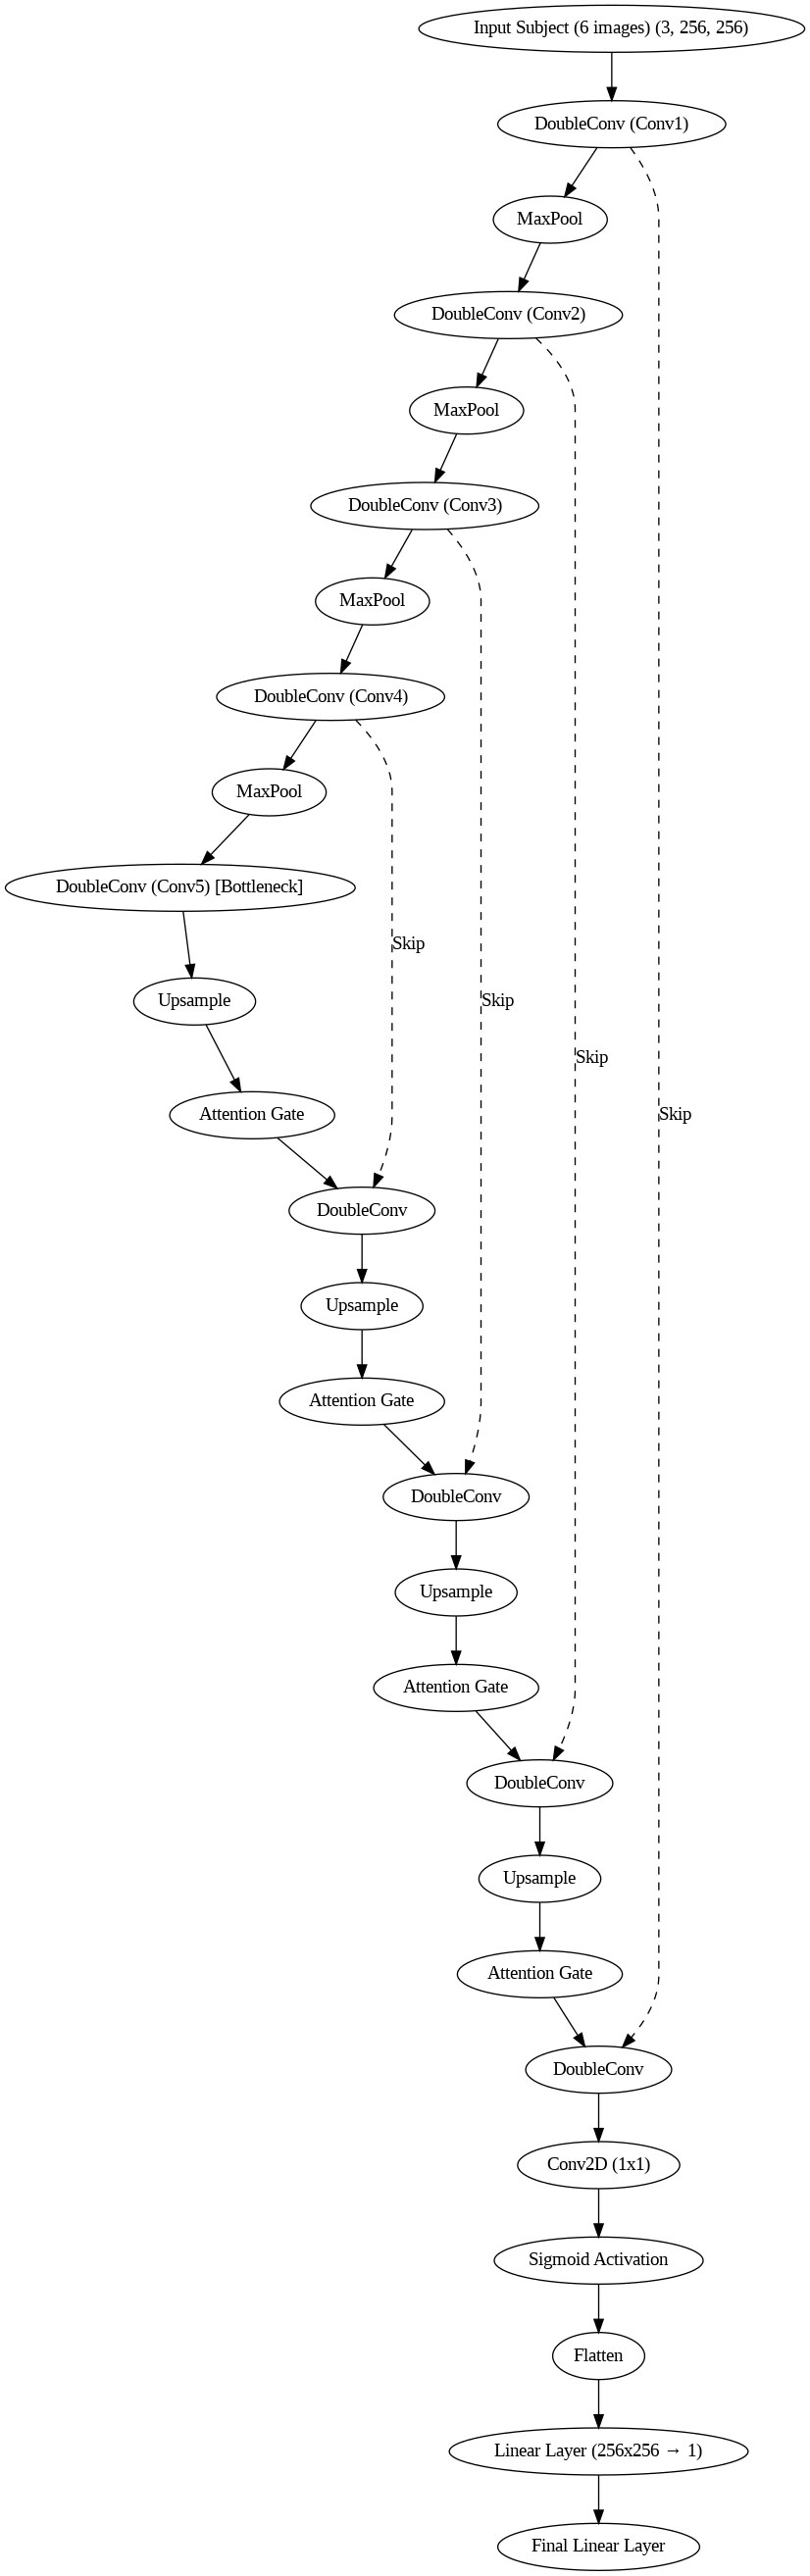

In [ ]:
from graphviz import Digraph

# Create a Graphviz Digraph
dot = Digraph(format="png")

# Define Nodes for Key Layers
dot.node("Input", "Input Subject (6 images) (3, 256, 256)")

# Encoder Path
dot.node("Conv1", "DoubleConv (Conv1)")
dot.node("Down1", "MaxPool")
dot.node("Conv2", "DoubleConv (Conv2)")
dot.node("Down2", "MaxPool")
dot.node("Conv3", "DoubleConv (Conv3)")
dot.node("Down3", "MaxPool")
dot.node("Conv4", "DoubleConv (Conv4)")
dot.node("Down4", "MaxPool")
dot.node("Conv5", "DoubleConv (Conv5) [Bottleneck]")

# Decoder Path
dot.node("Up5", "Upsample")
dot.node("Att5", "Attention Gate")
dot.node("UpConv5", "DoubleConv")
dot.node("Up4", "Upsample")
dot.node("Att4", "Attention Gate")
dot.node("UpConv4", "DoubleConv")
dot.node("Up3", "Upsample")
dot.node("Att3", "Attention Gate")
dot.node("UpConv3", "DoubleConv")
dot.node("Up2", "Upsample")
dot.node("Att2", "Attention Gate")
dot.node("UpConv2", "DoubleConv")

# Output Processing
dot.node("ConvOut", "Conv2D (1x1)")
dot.node("Sigmoid", "Sigmoid Activation")
dot.node("Flatten", "Flatten")
dot.node("Linear1", "Linear Layer (256x256 → 1)")
dot.node("Linear2", "Final Linear Layer")

# Skip Connections (Dashed Arrows)
dot.edge("Conv1", "UpConv2", style="dashed", label="Skip")
dot.edge("Conv2", "UpConv3", style="dashed", label="Skip")
dot.edge("Conv3", "UpConv4", style="dashed", label="Skip")
dot.edge("Conv4", "UpConv5", style="dashed", label="Skip")

# Encoder Connections
dot.edge("Input", "Conv1")
dot.edge("Conv1", "Down1")
dot.edge("Down1", "Conv2")
dot.edge("Conv2", "Down2")
dot.edge("Down2", "Conv3")
dot.edge("Conv3", "Down3")
dot.edge("Down3", "Conv4")
dot.edge("Conv4", "Down4")
dot.edge("Down4", "Conv5")

# Decoder Connections
dot.edge("Conv5", "Up5")
dot.edge("Up5", "Att5")
dot.edge("Att5", "UpConv5")
dot.edge("UpConv5", "Up4")
dot.edge("Up4", "Att4")
dot.edge("Att4", "UpConv4")
dot.edge("UpConv4", "Up3")
dot.edge("Up3", "Att3")
dot.edge("Att3", "UpConv3")
dot.edge("UpConv3", "Up2")
dot.edge("Up2", "Att2")
dot.edge("Att2", "UpConv2")
dot.edge("UpConv2", "ConvOut")

# Output Processing
dot.edge("ConvOut", "Sigmoid")
dot.edge("Sigmoid", "Flatten")
dot.edge("Flatten", "Linear1")
dot.edge("Linear1", "Linear2")

# Render and Save
dot.render("attunet_simplified_diagram")

# Display
from IPython.display import Image
Image("attunet_simplified_diagram.png")


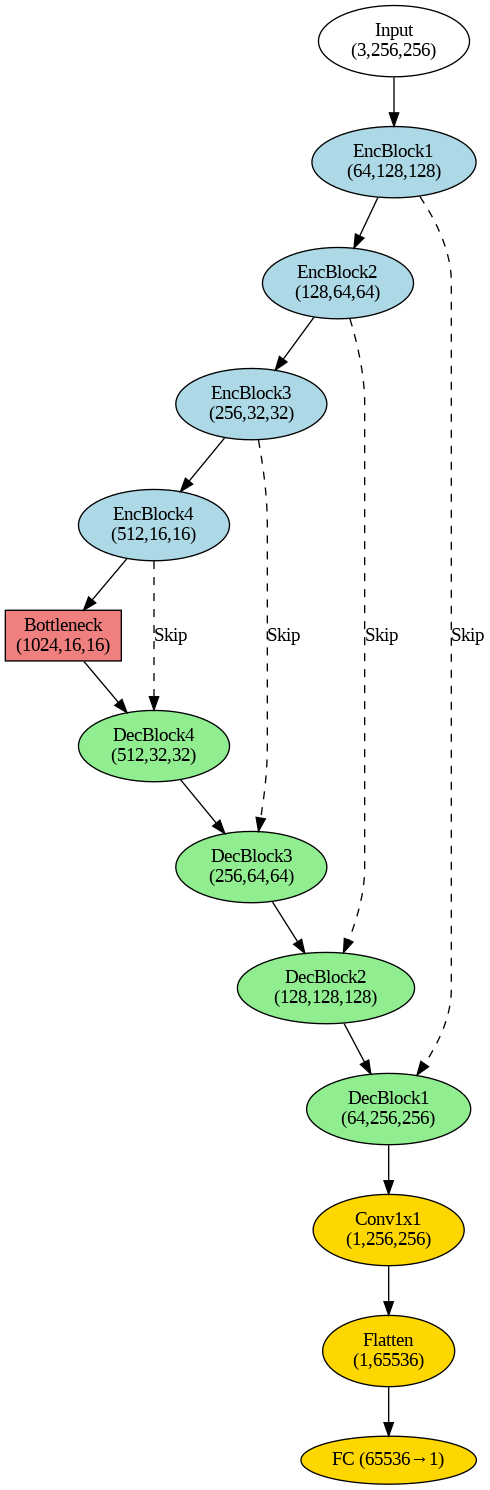

In [ ]:
from graphviz import Digraph

# Create a Graphviz Digraph
dot = Digraph(format="png")
#dot.attr(rankdir="TB")  # Top-to-Bottom U-Shape
#dot.attr(size="5,5")    # Compact layout

# Define Nodes (Simplified Encoder - Left Side)
dot.node("Input", "Input\n(3,256,256)", shape="oval", width="1.2")
dot.node("Enc1", "EncBlock1\n(64,128,128)", width="1.2", style="filled", fillcolor="lightblue")
dot.node("Enc2", "EncBlock2\n(128,64,64)", width="1.2", style="filled", fillcolor="lightblue")
dot.node("Enc3", "EncBlock3\n(256,32,32)", width="1.2", style="filled", fillcolor="lightblue")
dot.node("Enc4", "EncBlock4\n(512,16,16)", width="1.2", style="filled", fillcolor="lightblue")

# Bottleneck (Centered at Bottom)
dot.node("Bottleneck", "Bottleneck\n(1024,16,16)", shape="box", width="1.2", style="filled", fillcolor="lightcoral")

# Define Nodes (Simplified Decoder - Right Side)
dot.node("Dec4", "DecBlock4\n(512,32,32)", width="1.2", style="filled", fillcolor="lightgreen")
dot.node("Dec3", "DecBlock3\n(256,64,64)", width="1.2", style="filled", fillcolor="lightgreen")
dot.node("Dec2", "DecBlock2\n(128,128,128)", width="1.2", style="filled", fillcolor="lightgreen")
dot.node("Dec1", "DecBlock1\n(64,256,256)", width="1.2", style="filled", fillcolor="lightgreen")

# Output Layers (Fully Connected)
dot.node("ConvOut", "Conv1x1\n(1,256,256)", width="1.2", style="filled", fillcolor="gold")
dot.node("Flatten", "Flatten\n(1,65536)", width="1.2", style="filled", fillcolor="gold")
dot.node("Linear", "FC (65536→1)", width="1.2", style="filled", fillcolor="gold")

# Encoder Connections (Grouped Downsampling Path)
dot.edge("Input", "Enc1")
dot.edge("Enc1", "Enc2")
dot.edge("Enc2", "Enc3")
dot.edge("Enc3", "Enc4")
dot.edge("Enc4", "Bottleneck")

# Decoder Connections (Grouped Upsampling Path)
dot.edge("Bottleneck", "Dec4")
dot.edge("Dec4", "Dec3")
dot.edge("Dec3", "Dec2")
dot.edge("Dec2", "Dec1")
dot.edge("Dec1", "ConvOut")

# Output Processing
dot.edge("ConvOut", "Flatten")
dot.edge("Flatten", "Linear")

# Skip Connections (Dashed)
dot.edge("Enc1", "Dec1", style="dashed", label="Skip")
dot.edge("Enc2", "Dec2", style="dashed", label="Skip")
dot.edge("Enc3", "Dec3", style="dashed", label="Skip")
dot.edge("Enc4", "Dec4", style="dashed", label="Skip")

# Render and Save
dot.render("simplified_attunet_diagram")

# Display in Colab
from IPython.display import Image
Image("simplified_attunet_diagram.png")


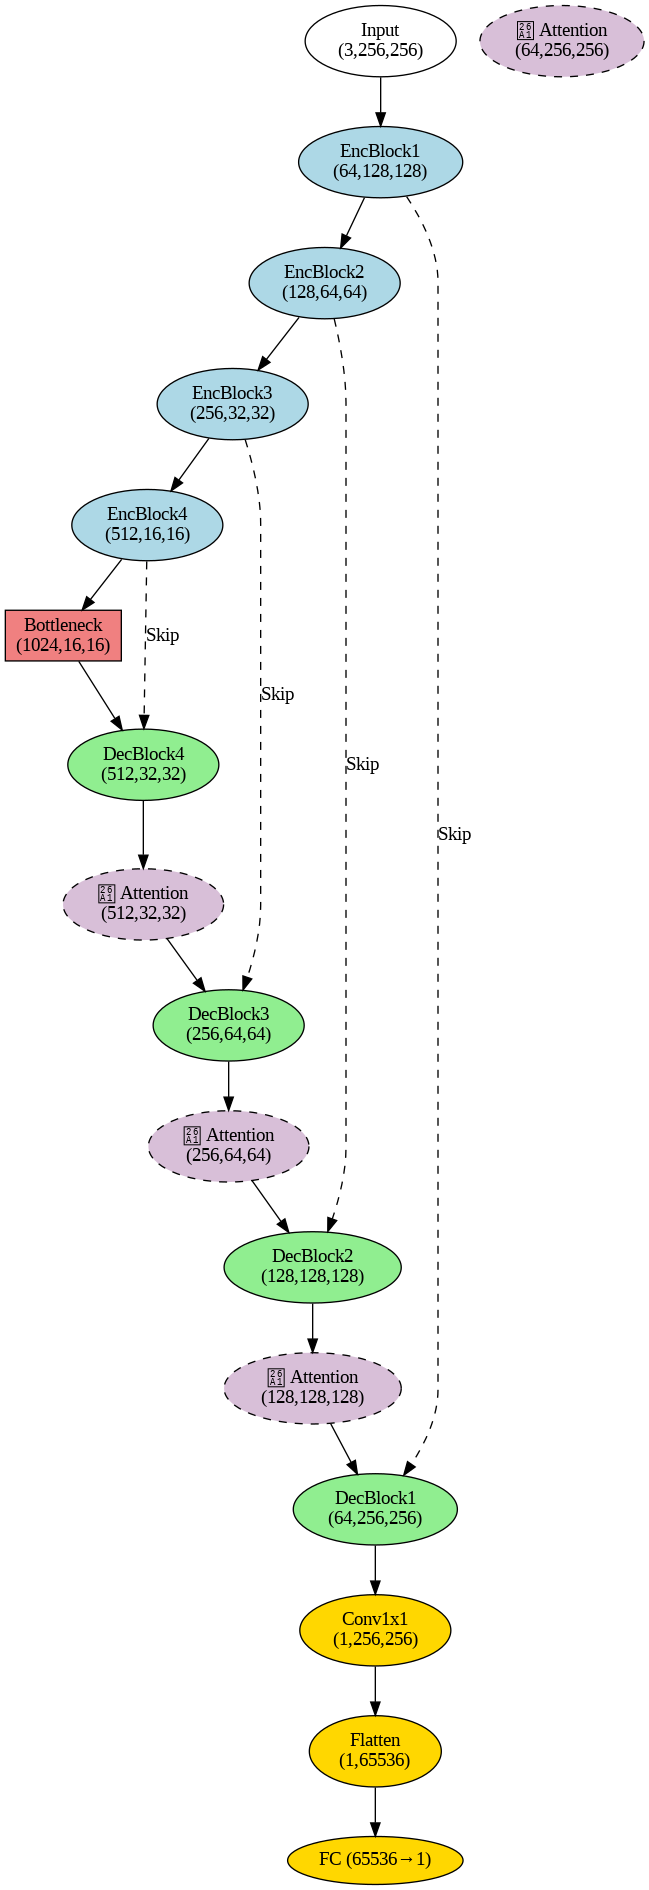

In [ ]:
from graphviz import Digraph

# Create a Graphviz Digraph
dot = Digraph(format="png")
dot.attr(rankdir="TB")  # Top-to-Bottom for U-Shape
#dot.attr(size="5,5")    # Compact layout

# Define Nodes (Simplified Encoder - Left Side)
dot.node("Input", "Input\n(3,256,256)", shape="oval", width="1.2")
dot.node("Enc1", "EncBlock1\n(64,128,128)", width="1.2", style="filled", fillcolor="lightblue")
dot.node("Enc2", "EncBlock2\n(128,64,64)", width="1.2", style="filled", fillcolor="lightblue")
dot.node("Enc3", "EncBlock3\n(256,32,32)", width="1.2", style="filled", fillcolor="lightblue")
dot.node("Enc4", "EncBlock4\n(512,16,16)", width="1.2", style="filled", fillcolor="lightblue")

# Bottleneck (Centered at Bottom)
dot.node("Bottleneck", "Bottleneck\n(1024,16,16)", shape="box", width="1.2", style="filled", fillcolor="lightcoral")

# Define Nodes (Simplified Decoder - Right Side)
dot.node("Dec4", "DecBlock4\n(512,32,32)", width="1.2", style="filled", fillcolor="lightgreen")
dot.node("Dec3", "DecBlock3\n(256,64,64)", width="1.2", style="filled", fillcolor="lightgreen")
dot.node("Dec2", "DecBlock2\n(128,128,128)", width="1.2", style="filled", fillcolor="lightgreen")
dot.node("Dec1", "DecBlock1\n(64,256,256)", width="1.2", style="filled", fillcolor="lightgreen")

# Emphasized Attention Layers (Dashed + Light Purple Fill)
dot.node("Att4", "⚡ Attention\n(512,32,32)", width="1.2", style="dashed, filled", fillcolor="thistle")
dot.node("Att3", "⚡ Attention\n(256,64,64)", width="1.2", style="dashed, filled", fillcolor="thistle")
dot.node("Att2", "⚡ Attention\n(128,128,128)", width="1.2", style="dashed, filled", fillcolor="thistle")
dot.node("Att1", "⚡ Attention\n(64,256,256)", width="1.2", style="dashed, filled", fillcolor="thistle")

# Output Layers (Fully Connected)
dot.node("ConvOut", "Conv1x1\n(1,256,256)", width="1.2", style="filled", fillcolor="gold")
dot.node("Flatten", "Flatten\n(1,65536)", width="1.2", style="filled", fillcolor="gold")
dot.node("Linear", "FC (65536→1)", width="1.2", style="filled", fillcolor="gold")

# Encoder Connections (Grouped Downsampling Path)
dot.edge("Input", "Enc1")
dot.edge("Enc1", "Enc2")
dot.edge("Enc2", "Enc3")
dot.edge("Enc3", "Enc4")
dot.edge("Enc4", "Bottleneck")

# Decoder Connections (Grouped Upsampling Path)
dot.edge("Bottleneck", "Dec4")
dot.edge("Dec4", "Att4")
dot.edge("Att4", "Dec3")
dot.edge("Dec3", "Att3")
dot.edge("Att3", "Dec2")
dot.edge("Dec2", "Att2")
dot.edge("Att2", "Dec1")
dot.edge("Dec1", "ConvOut")

# Output Processing
dot.edge("ConvOut", "Flatten")
dot.edge("Flatten", "Linear")

# Skip Connections (Dashed)
dot.edge("Enc1", "Dec1", style="dashed", label="Skip")
dot.edge("Enc2", "Dec2", style="dashed", label="Skip")
dot.edge("Enc3", "Dec3", style="dashed", label="Skip")
dot.edge("Enc4", "Dec4", style="dashed", label="Skip")

# Render and Save
dot.render("simplified_attunet_diagram_with_attention")

# Display in Colab
from IPython.display import Image
Image("simplified_attunet_diagram_with_attention.png")


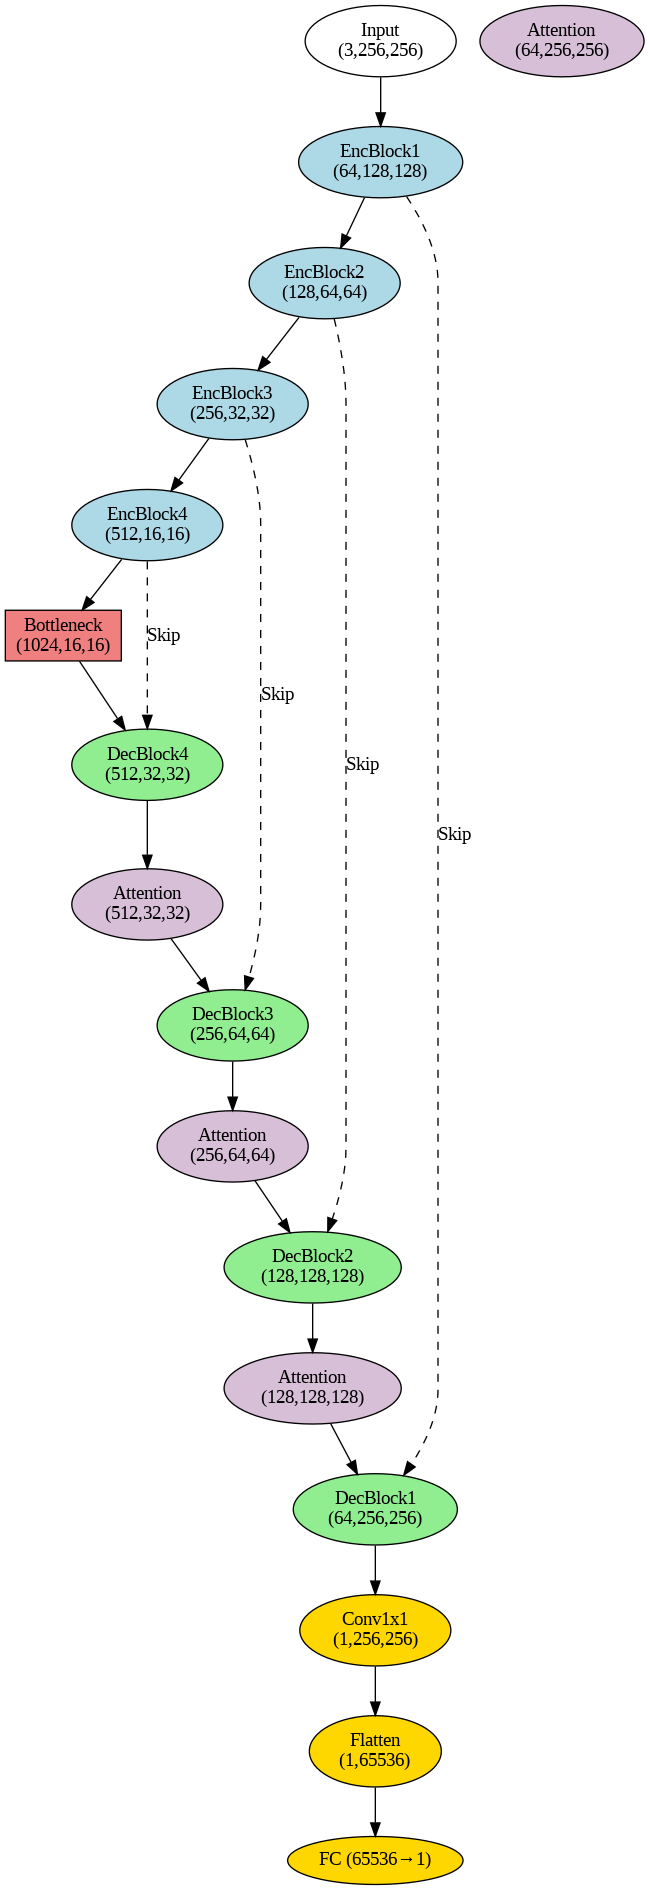

In [ ]:
from graphviz import Digraph

# Create a Graphviz Digraph
dot = Digraph(format="png")
dot.attr(rankdir="TB")  # Top-to-Bottom for U-Shape
#dot.attr(size="5,5")    # Compact layout

# Define Nodes (Simplified Encoder - Left Side)
dot.node("Input", "Input\n(3,256,256)", shape="oval", width="1.2")
dot.node("Enc1", "EncBlock1\n(64,128,128)", width="1.2", style="filled", fillcolor="lightblue")
dot.node("Enc2", "EncBlock2\n(128,64,64)", width="1.2", style="filled", fillcolor="lightblue")
dot.node("Enc3", "EncBlock3\n(256,32,32)", width="1.2", style="filled", fillcolor="lightblue")
dot.node("Enc4", "EncBlock4\n(512,16,16)", width="1.2", style="filled", fillcolor="lightblue")

# Bottleneck (Centered at Bottom)
dot.node("Bottleneck", "Bottleneck\n(1024,16,16)", shape="box", width="1.2", style="filled", fillcolor="lightcoral")

# Define Nodes (Simplified Decoder - Right Side)
dot.node("Dec4", "DecBlock4\n(512,32,32)", width="1.2", style="filled", fillcolor="lightgreen")
dot.node("Dec3", "DecBlock3\n(256,64,64)", width="1.2", style="filled", fillcolor="lightgreen")
dot.node("Dec2", "DecBlock2\n(128,128,128)", width="1.2", style="filled", fillcolor="lightgreen")
dot.node("Dec1", "DecBlock1\n(64,256,256)", width="1.2", style="filled", fillcolor="lightgreen")

# Emphasized Attention Layers (Ellipses)
dot.node("Att4", "Attention\n(512,32,32)", shape="ellipse", width="1.5", style="filled", fillcolor="thistle")
dot.node("Att3", "Attention\n(256,64,64)", shape="ellipse", width="1.5", style="filled", fillcolor="thistle")
dot.node("Att2", "Attention\n(128,128,128)", shape="ellipse", width="1.5", style="filled", fillcolor="thistle")
dot.node("Att1", "Attention\n(64,256,256)", shape="ellipse", width="1.5", style="filled", fillcolor="thistle")

# Output Layers (Fully Connected)
dot.node("ConvOut", "Conv1x1\n(1,256,256)", width="1.2", style="filled", fillcolor="gold")
dot.node("Flatten", "Flatten\n(1,65536)", width="1.2", style="filled", fillcolor="gold")
dot.node("Linear", "FC (65536→1)", width="1.2", style="filled", fillcolor="gold")

# Encoder Connections (Grouped Downsampling Path)
dot.edge("Input", "Enc1")
dot.edge("Enc1", "Enc2")
dot.edge("Enc2", "Enc3")
dot.edge("Enc3", "Enc4")
dot.edge("Enc4", "Bottleneck")

# Decoder Connections (Grouped Upsampling Path)
dot.edge("Bottleneck", "Dec4")
dot.edge("Dec4", "Att4")
dot.edge("Att4", "Dec3")
dot.edge("Dec3", "Att3")
dot.edge("Att3", "Dec2")
dot.edge("Dec2", "Att2")
dot.edge("Att2", "Dec1")
dot.edge("Dec1", "ConvOut")

# Output Processing
dot.edge("ConvOut", "Flatten")
dot.edge("Flatten", "Linear")

# Skip Connections (Dashed)
dot.edge("Enc1", "Dec1", style="dashed", label="Skip")
dot.edge("Enc2", "Dec2", style="dashed", label="Skip")
dot.edge("Enc3", "Dec3", style="dashed", label="Skip")
dot.edge("Enc4", "Dec4", style="dashed", label="Skip")

# Render and Save
dot.render("simplified_attunet_diagram_with_attention_ellipses")

# Display in Colab
from IPython.display import Image
Image("simplified_attunet_diagram_with_attention_ellipses.png")


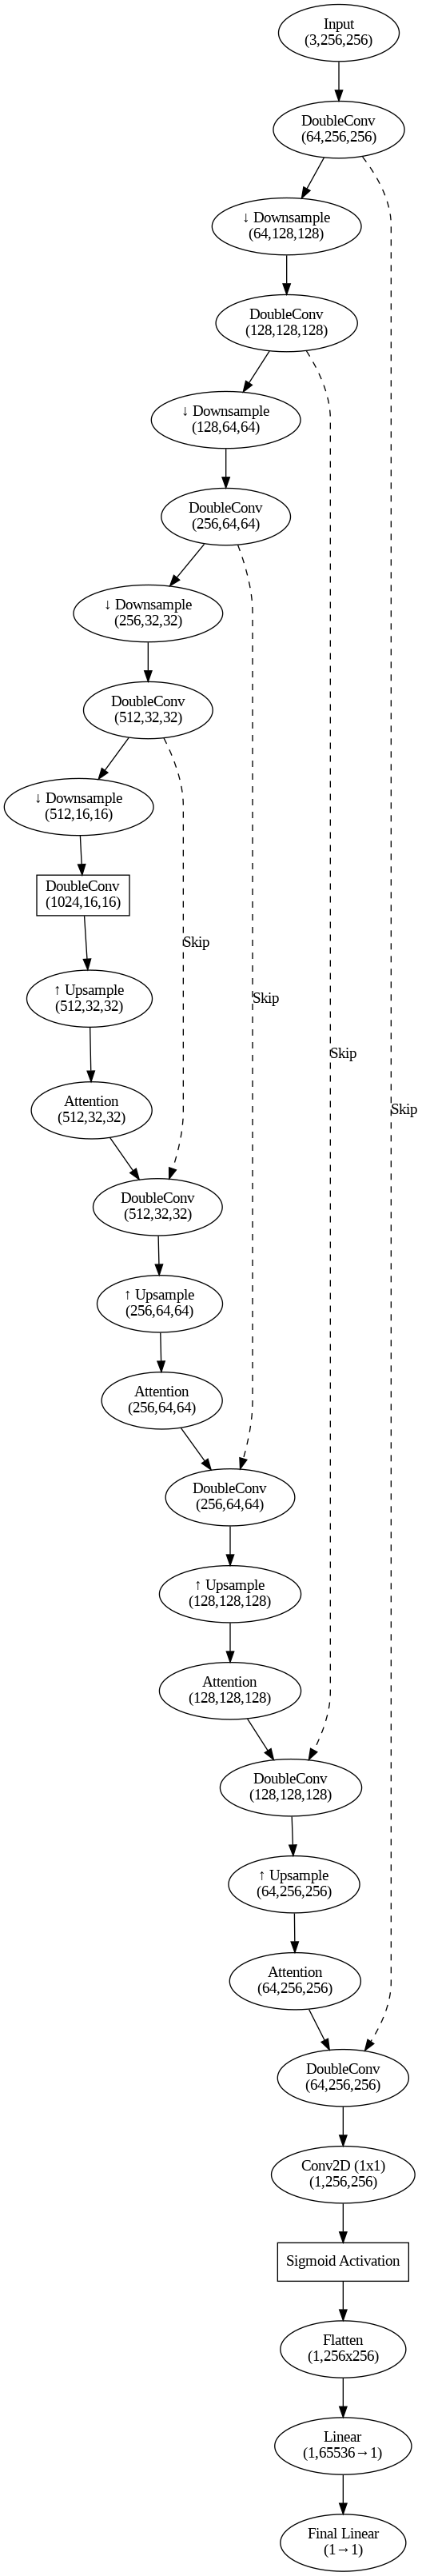

In [ ]:
from graphviz import Digraph

# Create a Graphviz Digraph
dot = Digraph(format="png")
dot.attr(rankdir="TB")  # Top-to-Bottom for U-Shape
#dot.attr(size="5,5")    # Compact layout

# Define Nodes (Encoder - Left Side with Dimensions)
dot.node("Input", "Input\n(3,256,256)", shape="oval", width="0.9")
dot.node("Conv1", "DoubleConv\n(64,256,256)", width="1")
dot.node("Down1", "↓ Downsample\n(64,128,128)", width="1")
dot.node("Conv2", "DoubleConv\n(128,128,128)", width="1")
dot.node("Down2", "↓ Downsample\n(128,64,64)", width="1")
dot.node("Conv3", "DoubleConv\n(256,64,64)", width="1")
dot.node("Down3", "↓ Downsample\n(256,32,32)", width="1")
dot.node("Conv4", "DoubleConv\n(512,32,32)", width="1")
dot.node("Down4", "↓ Downsample\n(512,16,16)", width="1")

# Bottleneck (Centered at Bottom)
dot.node("Bottleneck", "DoubleConv\n(1024,16,16)", shape="box", width="1")

# Define Nodes (Decoder - Right Side with Dimensions)
dot.node("Up4", "↑ Upsample\n(512,32,32)", width="1")
dot.node("Att4", "Attention\n(512,32,32)", width="1")
dot.node("UpConv4", "DoubleConv\n(512,32,32)", width="1")
dot.node("Up3", "↑ Upsample\n(256,64,64)", width="1")
dot.node("Att3", "Attention\n(256,64,64)", width="1")
dot.node("UpConv3", "DoubleConv\n(256,64,64)", width="1")
dot.node("Up2", "↑ Upsample\n(128,128,128)", width="1")
dot.node("Att2", "Attention\n(128,128,128)", width="1")
dot.node("UpConv2", "DoubleConv\n(128,128,128)", width="1")
dot.node("Up1", "↑ Upsample\n(64,256,256)", width="1")
dot.node("Att1", "Attention\n(64,256,256)", width="1")
dot.node("UpConv1", "DoubleConv\n(64,256,256)", width="1")

# Output Layers (Top Right with Dimensions)
dot.node("ConvOut", "Conv2D (1x1)\n(1,256,256)", width="1")
dot.node("Sigmoid", "Sigmoid Activation", shape="box", width="1")
dot.node("Flatten", "Flatten\n(1,256x256)", width="1")
dot.node("Linear1", "Linear\n(1,65536→1)", width="1")
dot.node("Linear2", "Final Linear\n(1→1)", width="1")

# Encoder Connections (Downsampling Path)
dot.edge("Input", "Conv1")
dot.edge("Conv1", "Down1")
dot.edge("Down1", "Conv2")
dot.edge("Conv2", "Down2")
dot.edge("Down2", "Conv3")
dot.edge("Conv3", "Down3")
dot.edge("Down3", "Conv4")
dot.edge("Conv4", "Down4")
dot.edge("Down4", "Bottleneck")

# Decoder Connections (Upsampling Path)
dot.edge("Bottleneck", "Up4")
dot.edge("Up4", "Att4")
dot.edge("Att4", "UpConv4")
dot.edge("UpConv4", "Up3")
dot.edge("Up3", "Att3")
dot.edge("Att3", "UpConv3")
dot.edge("UpConv3", "Up2")
dot.edge("Up2", "Att2")
dot.edge("Att2", "UpConv2")
dot.edge("UpConv2", "Up1")
dot.edge("Up1", "Att1")
dot.edge("Att1", "UpConv1")
dot.edge("UpConv1", "ConvOut")

# Output Processing
dot.edge("ConvOut", "Sigmoid")
dot.edge("Sigmoid", "Flatten")
dot.edge("Flatten", "Linear1")
dot.edge("Linear1", "Linear2")

# Skip Connections (Dashed)
dot.edge("Conv1", "UpConv1", style="dashed", label="Skip")
dot.edge("Conv2", "UpConv2", style="dashed", label="Skip")
dot.edge("Conv3", "UpConv3", style="dashed", label="Skip")
dot.edge("Conv4", "UpConv4", style="dashed", label="Skip")

# Render and Save
dot.render("attunet_u_diagram_with_dims")

# Display in Colab
from IPython.display import Image
Image("attunet_u_diagram_with_dims.png")


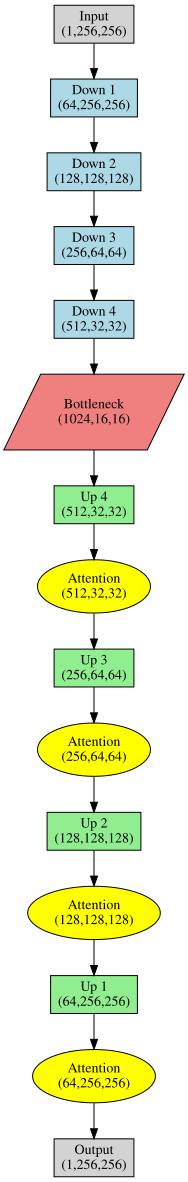

In [ ]:
from graphviz import Digraph

def draw_simplified_unet():
    dot = Digraph(format='png', graph_attr={'rankdir': 'TB'})  # TB = Top to Bottom (U-shape)

    # Encoder Path (Downsampling)
    dot.node('Input', 'Input\n(1,256,256)', shape='rect', style='filled', fillcolor='lightgray')
    dot.node('Down1', 'Down 1\n(64,256,256)', shape='box', style='filled', fillcolor='lightblue')
    dot.node('Down2', 'Down 2\n(128,128,128)', shape='box', style='filled', fillcolor='lightblue')
    dot.node('Down3', 'Down 3\n(256,64,64)', shape='box', style='filled', fillcolor='lightblue')
    dot.node('Down4', 'Down 4\n(512,32,32)', shape='box', style='filled', fillcolor='lightblue')

    # Bottleneck (Deepest part)
    dot.node('Bottleneck', 'Bottleneck\n(1024,16,16)', shape='parallelogram', style='filled', fillcolor='lightcoral')

    # Decoder Path (Upsampling)
    dot.node('Up4', 'Up 4\n(512,32,32)', shape='box', style='filled', fillcolor='lightgreen')
    dot.node('Att4', 'Attention\n(512,32,32)', shape='ellipse', style='filled', fillcolor='yellow')

    dot.node('Up3', 'Up 3\n(256,64,64)', shape='box', style='filled', fillcolor='lightgreen')
    dot.node('Att3', 'Attention\n(256,64,64)', shape='ellipse', style='filled', fillcolor='yellow')

    dot.node('Up2', 'Up 2\n(128,128,128)', shape='box', style='filled', fillcolor='lightgreen')
    dot.node('Att2', 'Attention\n(128,128,128)', shape='ellipse', style='filled', fillcolor='yellow')

    dot.node('Up1', 'Up 1\n(64,256,256)', shape='box', style='filled', fillcolor='lightgreen')
    dot.node('Att1', 'Attention\n(64,256,256)', shape='ellipse', style='filled', fillcolor='yellow')

    dot.node('Output', 'Output\n(1,256,256)', shape='rect', style='filled', fillcolor='lightgray')

    # Encoder (Downsampling) Connections
    dot.edge('Input', 'Down1')
    dot.edge('Down1', 'Down2')
    dot.edge('Down2', 'Down3')
    dot.edge('Down3', 'Down4')
    dot.edge('Down4', 'Bottleneck')

    # Decoder (Upsampling) Connections
    dot.edge('Bottleneck', 'Up4')
    dot.edge('Up4', 'Att4')
    dot.edge('Att4', 'Up3')
    dot.edge('Up3', 'Att3')
    dot.edge('Att3', 'Up2')
    dot.edge('Up2', 'Att2')
    dot.edge('Att2', 'Up1')
    dot.edge('Up1', 'Att1')
    dot.edge('Att1', 'Output')

    # Render the graph
    return dot

# Display U-Net Architecture Diagram
unet_graph = draw_simplified_unet()
unet_graph.render('unet_diagram', format='png', cleanup=False)  # Saves the image
unet_graph  # Displays the image


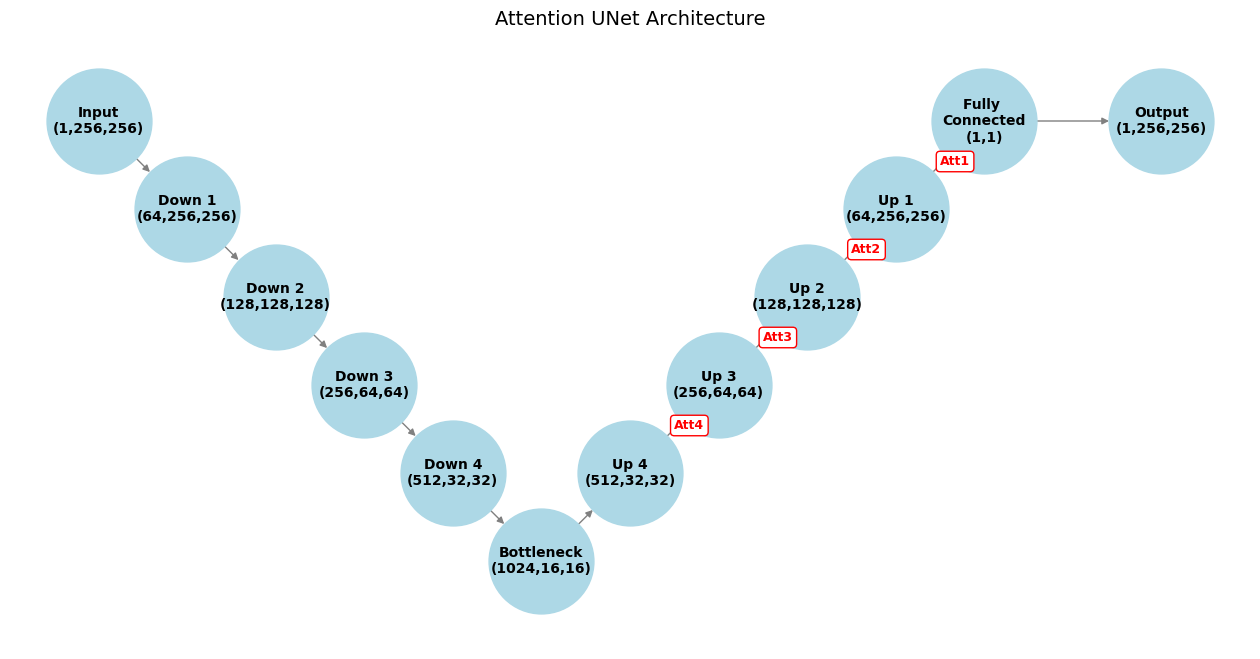

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_perfect_attention_unet():
    G = nx.DiGraph()

    # Define positions ensuring perfect U-shape & proper spacing
    positions = {
        "Input": (1, 7),
        "Down1": (2, 6),
        "Down2": (3, 5),
        "Down3": (4, 4),
        "Down4": (5, 3),
        "Bottleneck": (6, 2),
        "Up4": (7, 3),
        "Up3": (8, 4),
        "Up2": (9, 5),
        "Up1": (10, 6),
        "FullyConnected": (11, 7),
        "Output": (13, 7)  # Output moved farther right for no overlap
    }

    # Define text labels with proper line breaks for best fit
    node_labels = {
        "Input": "Input\n(1,256,256)",
        "Down1": "Down 1\n(64,256,256)",
        "Down2": "Down 2\n(128,128,128)",  # Adjusted text positioning
        "Down3": "Down 3\n(256,64,64)",
        "Down4": "Down 4\n(512,32,32)",
        "Bottleneck": "Bottleneck\n(1024,16,16)",
        "Up4": "Up 4\n(512,32,32)",
        "Up3": "Up 3\n(256,64,64)",
        "Up2": "Up 2\n(128,128,128)",  # Adjusted text positioning
        "Up1": "Up 1\n(64,256,256)",
        "FullyConnected": "Fully \nConnected\n(1,1)",
        "Output": "Output\n(1,256,256)"
    }

    # Define edges (Layer connections with proper spacing)
    edges = [
        ("Input", "Down1"),
        ("Down1", "Down2"),
        ("Down2", "Down3"),
        ("Down3", "Down4"),
        ("Down4", "Bottleneck"),
        ("Bottleneck", "Up4"),
        ("Up4", "Up3"),
        ("Up3", "Up2"),
        ("Up2", "Up1"),
        ("Up1", "FullyConnected"),
        ("FullyConnected", "Output")  # Directed to the right
    ]

    # Create the graph
    for node in node_labels:
        G.add_node(node)

    for edge in edges:
        G.add_edge(*edge)

    # Define arrow styles for Attention Layers
    attention_edges = {
        ("Up4", "Up3"): "Att4",
        ("Up3", "Up2"): "Att3",
        ("Up2", "Up1"): "Att2",
        ("Up1", "FullyConnected"): "Att1"
    }

    # Increase figure size to prevent cutting off edges
    plt.figure(figsize=(16, 8))  # Wider figure for better spacing
    ax = plt.gca()

    # Draw nodes with **oval shape**
    nx.draw(
        G, pos=positions, with_labels=True, node_size=5700, node_color="lightblue",
        edge_color="gray", font_size=10, font_weight="bold", labels=node_labels,
        verticalalignment="center", node_shape="o", arrows=True
    )

    # Draw attention indicators on specific edges
    for (edge, att_name) in attention_edges.items():
        start, end = edge
        x1, y1 = positions[start]
        x2, y2 = positions[end]
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2

        plt.text(mid_x, mid_y, att_name, fontsize=9, color="red", fontweight="bold",
                 bbox=dict(facecolor="white", edgecolor="red", boxstyle="round,pad=0.3"))

    # Increase border padding to prevent cutoffs
    plt.xlim(0, 14)
    plt.ylim(1, 8)

    plt.title("Attention UNet Architecture", fontsize=14)
    plt.show()

# Run function to display the final optimized diagram
draw_perfect_attention_unet()


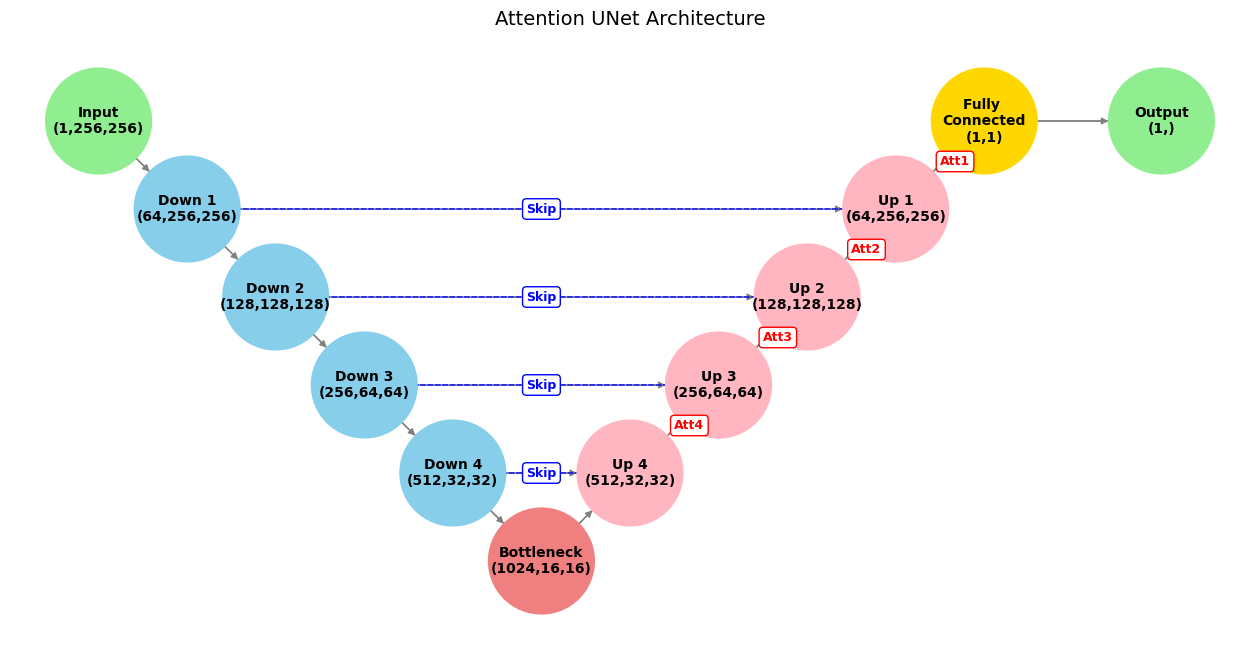

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_perfect_attention_unet():
    G = nx.DiGraph()

    # Define positions ensuring perfect U-shape & proper spacing
    positions = {
        "Input": (1, 7),
        "Down1": (2, 6),
        "Down2": (3, 5),
        "Down3": (4, 4),
        "Down4": (5, 3),
        "Bottleneck": (6, 2),
        "Up4": (7, 3),
        "Up3": (8, 4),
        "Up2": (9, 5),
        "Up1": (10, 6),
        "FullyConnected": (11, 7),
        "Output": (13, 7)  # Output moved farther right for no overlap
    }

    # Define text labels with proper line breaks for best fit
    node_labels = {
        "Input": "Input\n(1,256,256)",
        "Down1": "Down 1\n(64,256,256)",
        "Down2": "Down 2\n(128,128,128)",
        "Down3": "Down 3\n(256,64,64)",
        "Down4": "Down 4\n(512,32,32)",
        "Bottleneck": "Bottleneck\n(1024,16,16)",
        "Up4": "Up 4\n(512,32,32)",
        "Up3": "Up 3\n(256,64,64)",
        "Up2": "Up 2\n(128,128,128)",
        "Up1": "Up 1\n(64,256,256)",
        "FullyConnected": "Fully \nConnected\n(1,1)",
        "Output": "Output\n(1,)"
    }

    # Define edges (Layer connections with proper spacing)
    edges = [
        ("Input", "Down1"),
        ("Down1", "Down2"),
        ("Down2", "Down3"),
        ("Down3", "Down4"),
        ("Down4", "Bottleneck"),
        ("Bottleneck", "Up4"),
        ("Up4", "Up3"),
        ("Up3", "Up2"),
        ("Up2", "Up1"),
        ("Up1", "FullyConnected"),
        ("FullyConnected", "Output")  # Directed to the right
    ]

    # Add skip connections
    skip_connections = [
        ("Down4", "Up4"),
        ("Down3", "Up3"),
        ("Down2", "Up2"),
        ("Down1", "Up1")
    ]

    # Define color groups for visualization
    node_colors = {
        "Input": "lightgreen",  # Input color
        "Output": "lightgreen",  # Output color
        "Bottleneck": "lightcoral",  # Bottleneck layer color
        "FullyConnected": "gold"
    }
    downsample_color = "skyblue"
    upsample_color = "lightpink"

    # Create the graph
    for node in node_labels:
        G.add_node(node)

    for edge in edges:
        G.add_edge(*edge)

    for edge in skip_connections:
        G.add_edge(*edge, color='blue', style='dashed')

    # Assign colors to downsampling and upsampling layers
    for node in positions.keys():
        if "Down" in node:
            node_colors[node] = downsample_color
        elif "Up" in node:
            node_colors[node] = upsample_color

    # Increase figure size to prevent cutting off edges
    plt.figure(figsize=(16, 8))
    ax = plt.gca()

    # Draw nodes with colors
    node_color_list = [node_colors.get(node, "gray") for node in G.nodes()]
    nx.draw(
        G, pos=positions, with_labels=True, node_size=5800, node_color=node_color_list,
        edge_color="gray", font_size=10, font_weight="bold", labels=node_labels,
        verticalalignment="center", node_shape="o", arrows=True
    )

    # Draw skip connections separately (dashed blue)
    edge_colors = ["blue" if edge in skip_connections else "gray" for edge in G.edges()]
    edge_styles = ["dashed" if edge in skip_connections else "solid" for edge in G.edges()]

    for edge in skip_connections:
        # Label skip connections at their precise midpoint
        x1, y1 = positions[edge[0]]
        x2, y2 = positions[edge[1]]
        midpoint_x = (x1 + x2) / 2
        midpoint_y = (y1 + y2) / 2
        plt.text(midpoint_x, midpoint_y, "Skip", fontsize=9, color="blue", fontweight="bold",
                 ha='center', va='center',
                 bbox=dict(facecolor="white", edgecolor="blue", boxstyle="round,pad=0.3"))

    for edge, color, style in zip(G.edges(), edge_colors, edge_styles):
        nx.draw_networkx_edges(G, positions, edgelist=[edge], edge_color=color, style=style)

    # Define arrow styles for Attention Layers
    attention_edges = {
        ("Up4", "Up3"): "Att4",
        ("Up3", "Up2"): "Att3",
        ("Up2", "Up1"): "Att2",
        ("Up1", "FullyConnected"): "Att1"
    }

    # Draw attention indicators on specific edges
    for (edge, att_name) in attention_edges.items():
        start, end = edge
        x1, y1 = positions[start]
        x2, y2 = positions[end]
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2

        plt.text(mid_x, mid_y, att_name, fontsize=9, color="red", fontweight="bold",
                 bbox=dict(facecolor="white", edgecolor="red", boxstyle="round,pad=0.3"))


    # Increase border padding to prevent cutoffs
    plt.xlim(0, 14)
    plt.ylim(1, 8)
    plt.savefig("attention_unet_highres.png", dpi=600, bbox_inches='tight')
    plt.title("Attention UNet Architecture", fontsize=14)


# Show the plot
plt.show()

# Run function to display the final optimized diagram
draw_perfect_attention_unet()


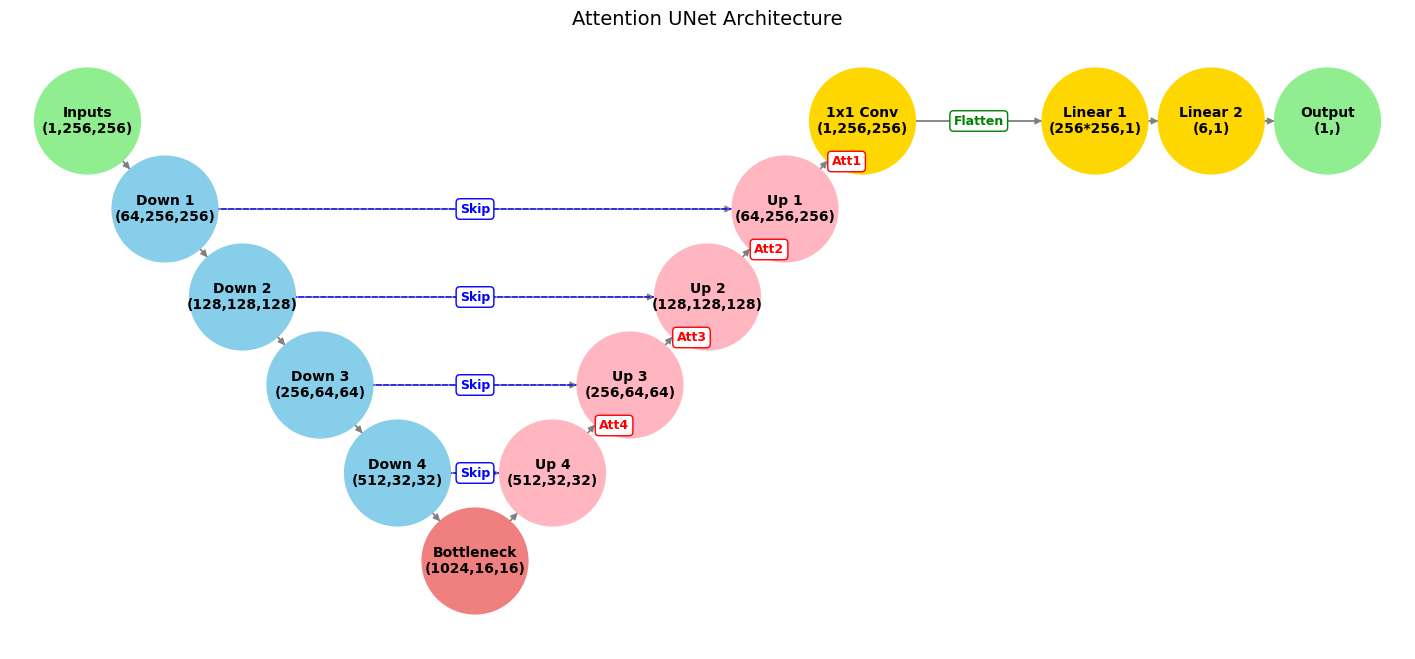

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_attention_unet_with_linear_layers():
    G = nx.DiGraph()

    # Define positions ensuring equal spacing
    positions = {
        "Input": (1, 7),
        "Down1": (2, 6),
        "Down2": (3, 5),
        "Down3": (4, 4),
        "Down4": (5, 3),
        "Bottleneck": (6, 2),
        "Up4": (7, 3),
        "Up3": (8, 4),
        "Up2": (9, 5),
        "Up1": (10, 6),
        "Conv1x1": (11, 7),
        "Linear1": (14, 7),
        "Linear2": (15.5, 7),
        "Output": (17, 7)
    }

    # Define text labels with dimensions
    node_labels = {
        "Input": "Inputs\n(1,256,256)",
        "Down1": "Down 1\n(64,256,256)",
        "Down2": "Down 2\n(128,128,128)",
        "Down3": "Down 3\n(256,64,64)",
        "Down4": "Down 4\n(512,32,32)",
        "Bottleneck": "Bottleneck\n(1024,16,16)",
        "Up4": "Up 4\n(512,32,32)",
        "Up3": "Up 3\n(256,64,64)",
        "Up2": "Up 2\n(128,128,128)",
        "Up1": "Up 1\n(64,256,256)",
        "Conv1x1": "1x1 Conv\n(1,256,256)",
        "Linear1": "Linear 1\n(256*256,1)",
        "Linear2": "Linear 2\n(6,1)",
        "Output": "Output\n(1,)"
    }

    # Define edges (Layer connections)
    edges = [
        ("Input", "Down1"),
        ("Down1", "Down2"),
        ("Down2", "Down3"),
        ("Down3", "Down4"),
        ("Down4", "Bottleneck"),
        ("Bottleneck", "Up4"),
        ("Up4", "Up3"),
        ("Up3", "Up2"),
        ("Up2", "Up1"),
        ("Up1", "Conv1x1"),
        ("Conv1x1", "Linear1"),
        ("Linear1", "Linear2"),
        ("Linear2", "Output")
    ]

    # Add skip connections
    skip_connections = [
        ("Down4", "Up4"),
        ("Down3", "Up3"),
        ("Down2", "Up2"),
        ("Down1", "Up1")
    ]

    # Define color groups for visualization
    node_colors = {
        "Input": "lightgreen",  # Input color
        "Output": "lightgreen",  # Output color
        "Bottleneck": "lightcoral",  # Bottleneck layer color
        "Conv1x1": "gold",
        "Linear1": "gold",
        "Linear2": "gold"
    }


    downsample_color = "skyblue"
    upsample_color = "lightpink"

    # Create the graph
    for node in node_labels:
        G.add_node(node)

    for edge in edges:
        G.add_edge(*edge)

    for edge in skip_connections:
        G.add_edge(*edge, color='blue', style='dashed')

    # Assign colors to downsampling and upsampling layers
    for node in positions.keys():
        if "Down" in node:
            node_colors[node] = downsample_color
        elif "Up" in node:
            node_colors[node] = upsample_color

    # Increase figure size to prevent cutting off edges
    plt.figure(figsize=(18, 8))
    ax = plt.gca()

    # Draw nodes with colors
    node_color_list = [node_colors.get(node, "gray") for node in G.nodes()]
    nx.draw(
        G, pos=positions, with_labels=True, node_size=5800, node_color=node_color_list,
        edge_color="gray", font_size=10, font_weight="bold", labels=node_labels,
        verticalalignment="center", node_shape="o", arrows=True
    )

    # Draw skip connections separately (dashed blue)
    edge_colors = ["blue" if edge in skip_connections else "gray" for edge in G.edges()]
    edge_styles = ["dashed" if edge in skip_connections else "solid" for edge in G.edges()]

    for edge in skip_connections:
        # Label skip connections at their precise midpoint
        x1, y1 = positions[edge[0]]
        x2, y2 = positions[edge[1]]
        midpoint_x = (x1 + x2) / 2
        midpoint_y = (y1 + y2) / 2
        plt.text(midpoint_x, midpoint_y, "Skip", fontsize=9, color="blue", fontweight="bold",
                 ha='center', va='center',
                 bbox=dict(facecolor="white", edgecolor="blue", boxstyle="round,pad=0.3"))

    for edge, color, style in zip(G.edges(), edge_colors, edge_styles):
        nx.draw_networkx_edges(G, positions, edgelist=[edge], edge_color=color, style=style)

    # Define arrow styles for Attention Layers
    attention_edges = {
        ("Up4", "Up3"): "Att4",
        ("Up3", "Up2"): "Att3",
        ("Up2", "Up1"): "Att2",
        ("Up1", "Conv1x1"): "Att1"
    }

    edge_labels = {
        ("Conv1x1","Linear1"): "Flatten"
    }

    # Define colors for each label
    edge_label_colors = {
        ("Conv1x1", "Linear1"): "green",  # Flatten label in green
        ("Up4", "Up3"): "red",
        ("Up3", "Up2"): "red",
        ("Up2", "Up1"): "red",
        ("Up1", "Conv1x1"): "red"
    }


    for edge, label in edge_labels.items():
      nx.draw_networkx_edge_labels(
          G, pos=positions,
          edge_labels={edge: label},
          label_pos=0.5,  # Position label at the center of the edge
          font_size=9,
          font_color=edge_label_colors[edge],
          font_weight="bold",
          bbox=dict(facecolor="white", edgecolor=edge_label_colors[edge], boxstyle="round,pad=0.3")
      )

    # Draw edge labels individually with specified colors
    for edge, label in attention_edges.items():
        label_pos = 0.5  # Position of the label along the edge
        font_size = 9
        font_color = edge_label_colors.get(edge, "black")
        x1, y1 = positions[edge[0]]
        x2, y2 = positions[edge[1]]
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2

        # Adjust position to place label in front of the node
        offset = 0.1  # Adjust this value as needed
        if x2 > x1:
            mid_x += offset
        else:
            mid_x -= offset

        plt.text(mid_x, mid_y, label, fontsize=font_size, color=font_color, fontweight="bold",
                 bbox=dict(facecolor="white", edgecolor=font_color, boxstyle="round,pad=0.3"))

    # Increase border padding to prevent cutoffs
    plt.xlim(0, 18)
    plt.ylim(1, 8)
    plt.title("Attention UNet Architecture", fontsize=14)
    plt.savefig("attention_unet_with_linear_layers.png", dpi=600, bbox_inches='tight')
    plt.show()

# Run function to display the updated diagram
draw_attention_unet_with_linear_layers()


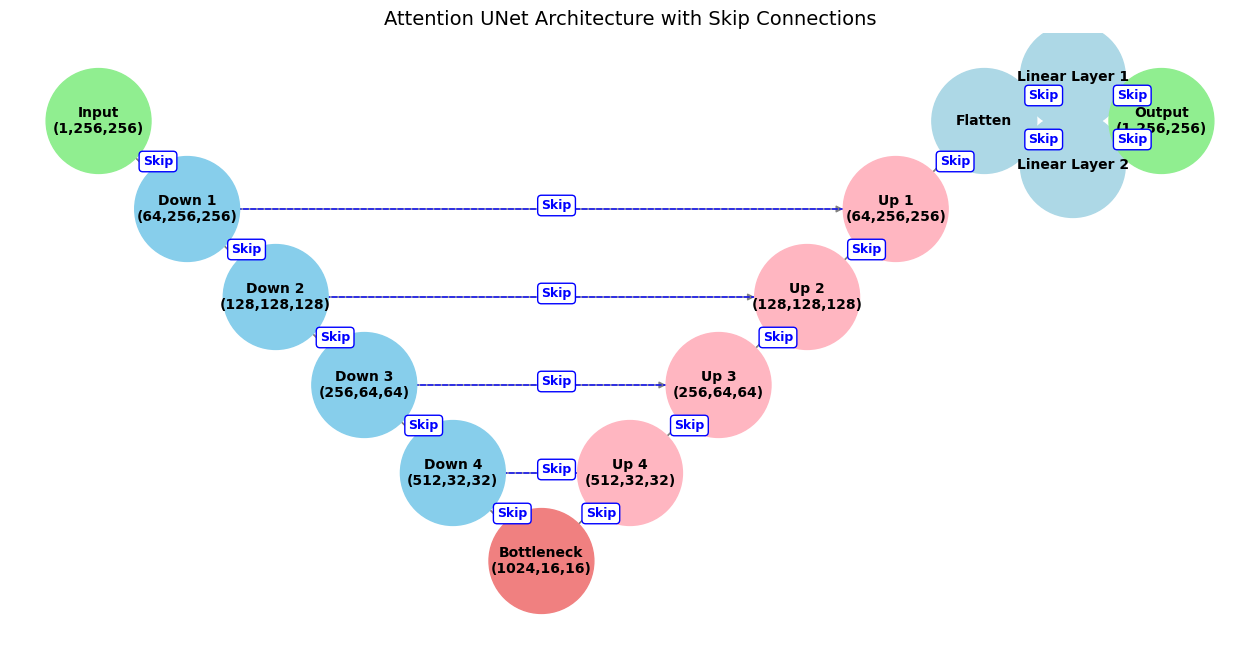

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_perfect_attention_unet():
    G = nx.DiGraph()

    # Define positions ensuring perfect U-shape & proper spacing
    positions = {
        "Input": (1, 7),
        "Down1": (2, 6),
        "Down2": (3, 5),
        "Down3": (4, 4),
        "Down4": (5, 3),
        "Bottleneck": (6, 2),
        "Up4": (7, 3),
        "Up3": (8, 4),
        "Up2": (9, 5),
        "Up1": (10, 6),
        "Flatten": (11, 7),
        "Linear1": (12, 7.5),
        "Linear2": (12, 6.5),
        "Output": (13, 7)  # Output moved farther right for no overlap
    }

    # Define text labels with proper line breaks for best fit
    node_labels = {
        "Input": "Input\n(1,256,256)",
        "Down1": "Down 1\n(64,256,256)",
        "Down2": "Down 2\n(128,128,128)",
        "Down3": "Down 3\n(256,64,64)",
        "Down4": "Down 4\n(512,32,32)",
        "Bottleneck": "Bottleneck\n(1024,16,16)",
        "Up4": "Up 4\n(512,32,32)",
        "Up3": "Up 3\n(256,64,64)",
        "Up2": "Up 2\n(128,128,128)",
        "Up1": "Up 1\n(64,256,256)",
        "Flatten": "Flatten",
        "Linear1": "Linear Layer 1",
        "Linear2": "Linear Layer 2",
        "Output": "Output\n(1,256,256)"
    }

    # Define edges (Layer connections with proper spacing)
    edges = [
        ("Input", "Down1"),
        ("Down1", "Down2"),
        ("Down2", "Down3"),
        ("Down3", "Down4"),
        ("Down4", "Bottleneck"),
        ("Bottleneck", "Up4"),
        ("Up4", "Up3"),
        ("Up3", "Up2"),
        ("Up2", "Up1"),
        ("Up1", "Flatten"),
        ("Flatten", "Linear1"),
        ("Flatten", "Linear2"),
        ("Linear1", "Output"),
        ("Linear2", "Output")
    ]

    # Add skip connections
    skip_connections = [
        ("Down4", "Up4"),
        ("Down3", "Up3"),
        ("Down2", "Up2"),
        ("Down1", "Up1")
    ]

    # Define color groups for visualization
    node_colors = {
        "Input": "lightgreen",  # Input color
        "Output": "lightgreen",  # Output color
        "Bottleneck": "lightcoral",  # Bottleneck layer color
        "Flatten": "lightblue",  # Flatten layer color
        "Linear1": "lightblue",  # Linear layer color
        "Linear2": "lightblue"  # Linear layer color
    }
    downsample_color = "skyblue"
    upsample_color = "lightpink"

    # Create the graph
    for node in node_labels:
        G.add_node(node)

    for edge in edges:
        G.add_edge(*edge)

    for edge in skip_connections:
        G.add_edge(*edge, color='blue', style='dashed')

    # Assign colors to downsampling and upsampling layers
    for node in positions.keys():
        if "Down" in node:
            node_colors[node] = downsample_color
        elif "Up" in node:
            node_colors[node] = upsample_color

    # Increase figure size to prevent cutting off edges
    plt.figure(figsize=(16, 8))
    ax = plt.gca()

    # Draw nodes with colors
    node_color_list = [node_colors.get(node, "gray") for node in G.nodes()]
    nx.draw(
        G, pos=positions, with_labels=True, node_size=5700, node_color=node_color_list,
        edge_color="gray", font_size=10, font_weight="bold", labels=node_labels,
        verticalalignment="center", node_shape="o", arrows=True
    )

    # Draw skip connections separately (dashed blue)
    edge_colors = ["blue" if edge in skip_connections else "gray" for edge in G.edges()]
    edge_styles = ["dashed" if edge in skip_connections else "solid" for edge in G.edges()]

    for edge, color, style in zip(G.edges(), edge_colors, edge_styles):
        nx.draw_networkx_edges(G, positions, edgelist=[edge], edge_color=color, style=style)

        # Label skip connections at their midpoint
        x1, y1 = positions[edge[0]]
        x2, y2 = positions[edge[1]]
        plt.text((x1 + x2) / 2, (y1 + y2) / 2, "Skip", fontsize=9, color="blue", fontweight="bold",
                 bbox=dict(facecolor="white", edgecolor="blue", boxstyle="round,pad=0.3"))

    # Increase border padding to prevent cutoffs
    plt.xlim(0, 14)
    plt.ylim(1, 8)

    plt.title("Attention UNet Architecture with Skip Connections", fontsize=14)
    plt.show()

# Run function to display the final optimized diagram
draw_perfect_attention_unet()


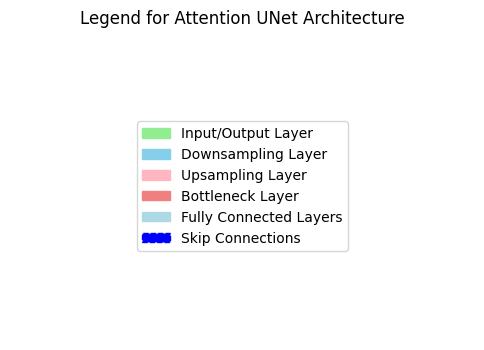

In [ ]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt

def draw_unet_legend():
    # Define colors
    downsample_color = "skyblue"
    upsample_color = "lightpink"
    bottleneck_color = "lightcoral"
    fully_connected_color = "lightblue"
    skip_connection_color = "blue"

    # Create patches for the legend
    legend_patches = [
        mpatches.Patch(color="lightgreen", label="Input/Output Layer"),
        mpatches.Patch(color=downsample_color, label="Downsampling Layer"),
        mpatches.Patch(color=upsample_color, label="Upsampling Layer"),
        mpatches.Patch(color=bottleneck_color, label="Bottleneck Layer"),
        mpatches.Patch(color=fully_connected_color, label="Fully Connected Layers"),
        mpatches.Patch(color=skip_connection_color, label="Skip Connections", linestyle="dashed")
    ]

    # Draw legend
    plt.figure(figsize=(6, 4))
    plt.legend(handles=legend_patches, loc="center", fontsize=10)
    plt.axis("off")
    plt.title("Legend for Attention UNet Architecture", fontsize=12)
    plt.show()

# Run function to display the legend
draw_unet_legend()


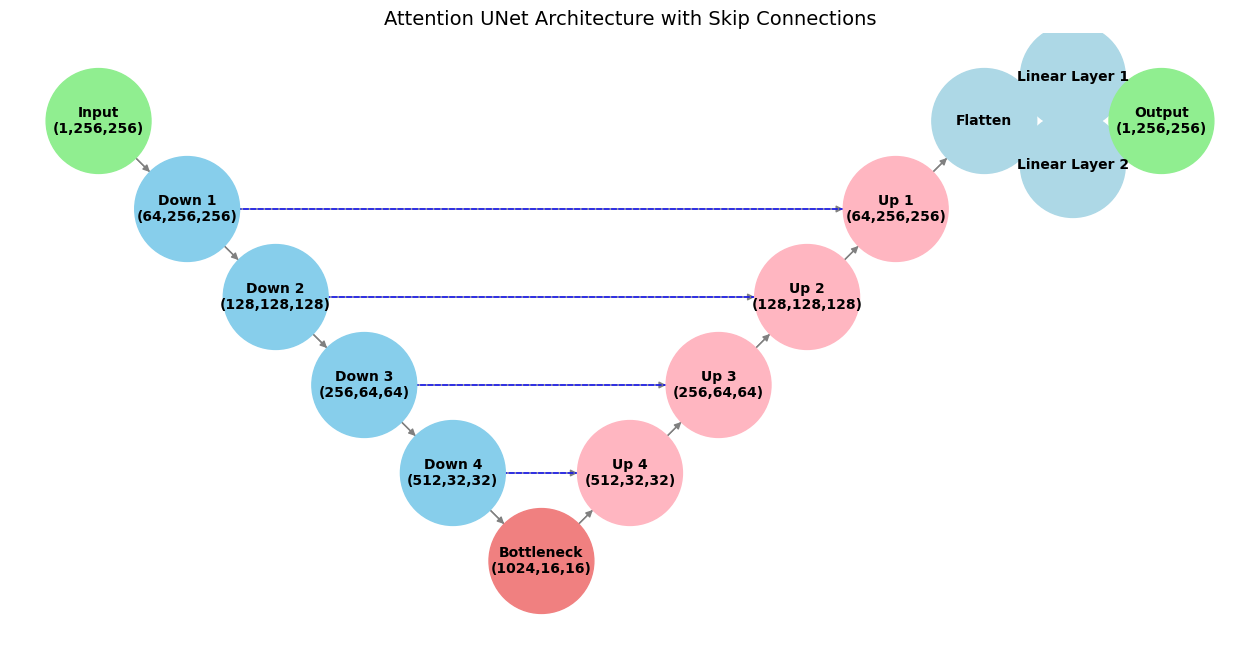

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

def draw_perfect_attention_unet():
    G = nx.DiGraph()

    # Define positions ensuring perfect U-shape & proper spacing
    positions = {
        "Input": (1, 7),
        "Down1": (2, 6),
        "Down2": (3, 5),
        "Down3": (4, 4),
        "Down4": (5, 3),
        "Bottleneck": (6, 2),
        "Up4": (7, 3),
        "Up3": (8, 4),
        "Up2": (9, 5),
        "Up1": (10, 6),
        "Flatten": (11, 7),
        "Linear1": (12, 7.5),
        "Linear2": (12, 6.5),
        "Output": (13, 7)  # Output moved farther right for no overlap
    }

    # Define text labels with proper line breaks for best fit
    node_labels = {
        "Input": "Input\n(1,256,256)",
        "Down1": "Down 1\n(64,256,256)",
        "Down2": "Down 2\n(128,128,128)",
        "Down3": "Down 3\n(256,64,64)",
        "Down4": "Down 4\n(512,32,32)",
        "Bottleneck": "Bottleneck\n(1024,16,16)",
        "Up4": "Up 4\n(512,32,32)",
        "Up3": "Up 3\n(256,64,64)",
        "Up2": "Up 2\n(128,128,128)",
        "Up1": "Up 1\n(64,256,256)",
        "Flatten": "Flatten",
        "Linear1": "Linear Layer 1",
        "Linear2": "Linear Layer 2",
        "Output": "Output\n(1,256,256)"
    }

    # Define edges (Layer connections with proper spacing)
    edges = [
        ("Input", "Down1"),
        ("Down1", "Down2"),
        ("Down2", "Down3"),
        ("Down3", "Down4"),
        ("Down4", "Bottleneck"),
        ("Bottleneck", "Up4"),
        ("Up4", "Up3"),
        ("Up3", "Up2"),
        ("Up2", "Up1"),
        ("Up1", "Flatten"),
        ("Flatten", "Linear1"),
        ("Flatten", "Linear2"),
        ("Linear1", "Output"),
        ("Linear2", "Output")
    ]

    # Add skip connections
    skip_connections = [
        ("Down4", "Up4"),
        ("Down3", "Up3"),
        ("Down2", "Up2"),
        ("Down1", "Up1")
    ]

    # Define color groups for visualization
    node_colors = {
        "Input": "lightgreen",  # Input color
        "Output": "lightgreen",  # Output color
        "Bottleneck": "lightcoral",  # Bottleneck layer color
        "Flatten": "lightblue",  # Flatten layer color
        "Linear1": "lightblue",  # Linear layer color
        "Linear2": "lightblue"  # Linear layer color
    }
    downsample_color = "skyblue"
    upsample_color = "lightpink"

    # Create the graph
    for node in node_labels:
        G.add_node(node)

    for edge in edges:
        G.add_edge(*edge)

    for edge in skip_connections:
        G.add_edge(*edge, color='blue', style='dashed')

    # Assign colors to downsampling and upsampling layers
    for node in positions.keys():
        if "Down" in node:
            node_colors[node] = downsample_color
        elif "Up" in node:
            node_colors[node] = upsample_color

    # Increase figure size to prevent cutting off edges
    plt.figure(figsize=(16, 8))
    ax = plt.gca()

    # Draw nodes with colors
    node_color_list = [node_colors.get(node, "gray") for node in G.nodes()]
    nx.draw(
        G, pos=positions, with_labels=True, node_size=5700, node_color=node_color_list,
        edge_color="gray", font_size=10, font_weight="bold", labels=node_labels,
        verticalalignment="center", node_shape="o", arrows=True
    )

    # Draw skip connections separately (dashed blue)
    edge_colors = ["blue" if edge in skip_connections else "gray" for edge in G.edges()]
    edge_styles = ["dashed" if edge in skip_connections else "solid" for edge in G.edges()]

    for edge, color, style in zip(G.edges(), edge_colors, edge_styles):
        nx.draw_networkx_edges(G, positions, edgelist=[edge], edge_color=color, style=style)

    # Increase border padding to prevent cutoffs
    plt.xlim(0, 14)
    plt.ylim(1, 8)

    plt.title("Attention UNet Architecture with Skip Connections", fontsize=14)
    plt.show()

# Run function to display the final optimized diagram
draw_perfect_attention_unet()


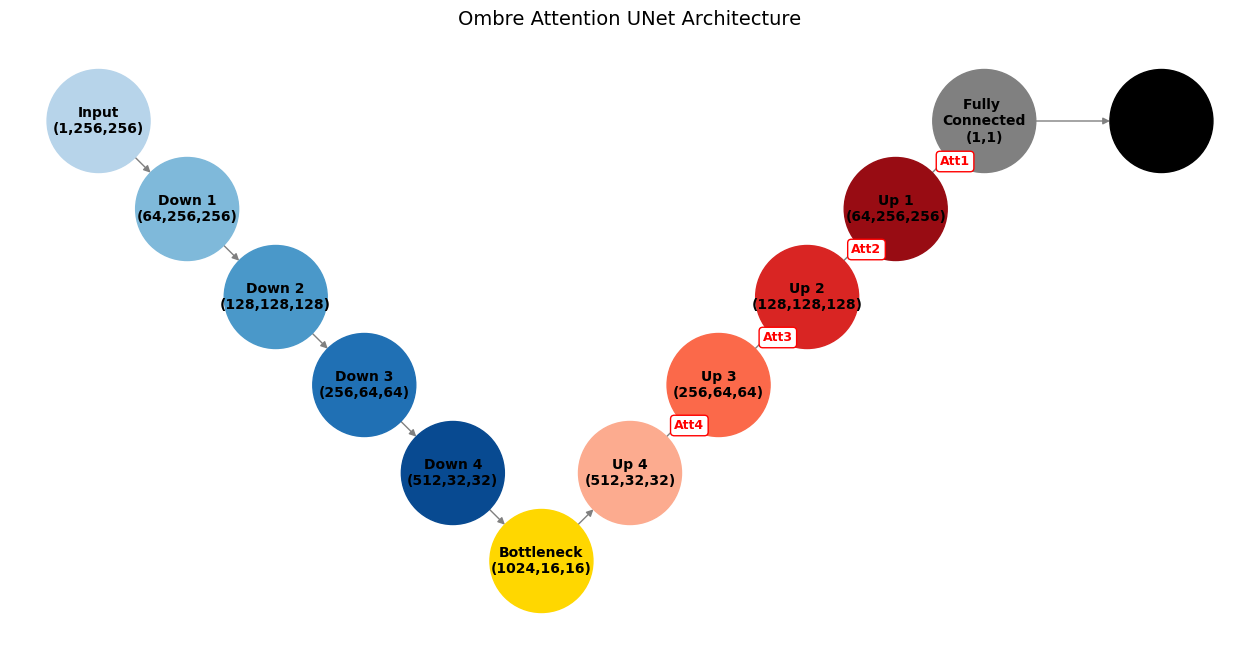

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def draw_ombre_attention_unet():
    G = nx.DiGraph()

    # Define positions ensuring perfect U-shape & proper spacing
    positions = {
        "Input": (1, 7),
        "Down1": (2, 6),
        "Down2": (3, 5),
        "Down3": (4, 4),
        "Down4": (5, 3),
        "Bottleneck": (6, 2),
        "Up4": (7, 3),
        "Up3": (8, 4),
        "Up2": (9, 5),
        "Up1": (10, 6),
        "FullyConnected": (11, 7),
        "Output": (13, 7)  # Output moved farther right for no overlap
    }

    # Define text labels with proper line breaks for best fit
    node_labels = {
        "Input": "Input\n(1,256,256)",
        "Down1": "Down 1\n(64,256,256)",
        "Down2": "Down 2\n(128,128,128)",
        "Down3": "Down 3\n(256,64,64)",
        "Down4": "Down 4\n(512,32,32)",
        "Bottleneck": "Bottleneck\n(1024,16,16)",
        "Up4": "Up 4\n(512,32,32)",
        "Up3": "Up 3\n(256,64,64)",
        "Up2": "Up 2\n(128,128,128)",
        "Up1": "Up 1\n(64,256,256)",
        "FullyConnected": "Fully \nConnected\n(1,1)",
        "Output": "Output\n(1,256,256)"
    }

    # Define edges (Layer connections with proper spacing)
    edges = [
        ("Input", "Down1"),
        ("Down1", "Down2"),
        ("Down2", "Down3"),
        ("Down3", "Down4"),
        ("Down4", "Bottleneck"),
        ("Bottleneck", "Up4"),
        ("Up4", "Up3"),
        ("Up3", "Up2"),
        ("Up2", "Up1"),
        ("Up1", "FullyConnected"),
        ("FullyConnected", "Output")  # Directed to the right
    ]

    # Create the graph
    for node in node_labels:
        G.add_node(node)

    for edge in edges:
        G.add_edge(*edge)

    # Define arrow styles for Attention Layers
    attention_edges = {
        ("Up4", "Up3"): "Att4",
        ("Up3", "Up2"): "Att3",
        ("Up2", "Up1"): "Att2",
        ("Up1", "FullyConnected"): "Att1"
    }

    # Assign colors based on ombre effect
    encoder_nodes = ["Input", "Down1", "Down2", "Down3", "Down4"]
    decoder_nodes = ["Up4", "Up3", "Up2", "Up1"]
    bottleneck_node = "Bottleneck"
    fc_node = "FullyConnected"
    output_node = "Output"

    # Generate gradient colors
    encoder_colors = [plt.cm.Blues(i) for i in np.linspace(0.3, 0.9, len(encoder_nodes))]
    decoder_colors = [plt.cm.Reds(i) for i in np.linspace(0.3, 0.9, len(decoder_nodes))]
    bottleneck_color = "gold"  # Neutral transition
    fc_color = "gray"
    output_color = "black"

    # Map node names to colors
    node_colors = {}
    for i, node in enumerate(encoder_nodes):
        node_colors[node] = encoder_colors[i]
    for i, node in enumerate(decoder_nodes):
        node_colors[node] = decoder_colors[i]
    node_colors[bottleneck_node] = bottleneck_color
    node_colors[fc_node] = fc_color
    node_colors[output_node] = output_color

    # Increase figure size to prevent cutoffs
    plt.figure(figsize=(16, 8))  # Wider figure for better spacing
    ax = plt.gca()

    # Draw nodes with ombre effect
    nx.draw(
        G, pos=positions, with_labels=True, node_size=5500,
        edge_color="gray", font_size=10, font_weight="bold", labels=node_labels,
        verticalalignment="center", node_shape="o", arrows=True,
        node_color=[node_colors[node] for node in G.nodes()]  # Apply gradient colors
    )

    # Draw attention indicators on specific edges
    for (edge, att_name) in attention_edges.items():
        start, end = edge
        x1, y1 = positions[start]
        x2, y2 = positions[end]
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2

        plt.text(mid_x, mid_y, att_name, fontsize=9, color="red", fontweight="bold",
                 bbox=dict(facecolor="white", edgecolor="red", boxstyle="round,pad=0.3"))

    # Increase border padding to prevent cutoffs
    plt.xlim(0, 14)
    plt.ylim(1, 8)

    plt.title("Ombre Attention UNet Architecture", fontsize=14)
    plt.show()

# Run function to display the ombre gradient diagram
draw_ombre_attention_unet()


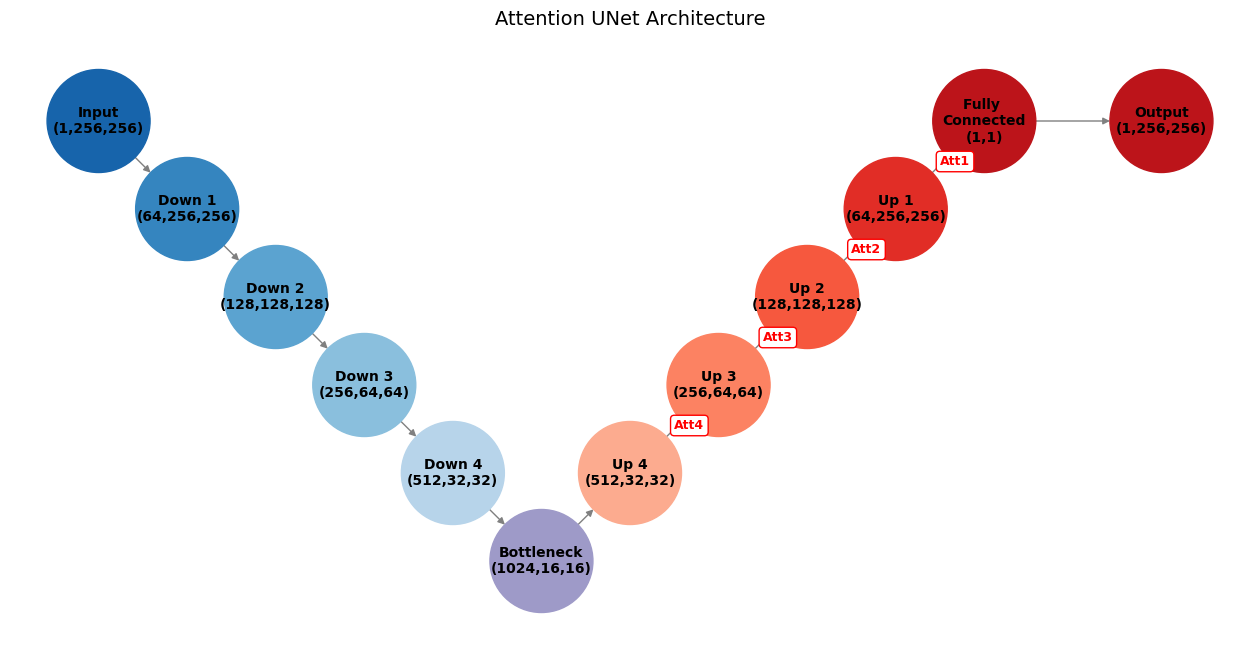

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def draw_two_color_ombre_unet():
    G = nx.DiGraph()

    # Define positions ensuring perfect U-shape & proper spacing
    positions = {
        "Input": (1, 7),
        "Down1": (2, 6),
        "Down2": (3, 5),
        "Down3": (4, 4),
        "Down4": (5, 3),
        "Bottleneck": (6, 2),
        "Up4": (7, 3),
        "Up3": (8, 4),
        "Up2": (9, 5),
        "Up1": (10, 6),
        "FullyConnected": (11, 7),
        "Output": (13, 7)  # Output moved farther right for no overlap
    }

    # Define text labels with proper line breaks for best fit
    node_labels = {
        "Input": "Input\n(1,256,256)",
        "Down1": "Down 1\n(64,256,256)",
        "Down2": "Down 2\n(128,128,128)",
        "Down3": "Down 3\n(256,64,64)",
        "Down4": "Down 4\n(512,32,32)",
        "Bottleneck": "Bottleneck\n(1024,16,16)",
        "Up4": "Up 4\n(512,32,32)",
        "Up3": "Up 3\n(256,64,64)",
        "Up2": "Up 2\n(128,128,128)",
        "Up1": "Up 1\n(64,256,256)",
        "FullyConnected": "Fully \nConnected\n(1,1)",
        "Output": "Output\n(1,256,256)"
    }

    # Define edges (Layer connections with proper spacing)
    edges = [
        ("Input", "Down1"),
        ("Down1", "Down2"),
        ("Down2", "Down3"),
        ("Down3", "Down4"),
        ("Down4", "Bottleneck"),
        ("Bottleneck", "Up4"),
        ("Up4", "Up3"),
        ("Up3", "Up2"),
        ("Up2", "Up1"),
        ("Up1", "FullyConnected"),
        ("FullyConnected", "Output")  # Directed to the right
    ]

    # Create the graph
    for node in node_labels:
        G.add_node(node)

    for edge in edges:
        G.add_edge(*edge)

    # Define arrow styles for Attention Layers
    attention_edges = {
        ("Up4", "Up3"): "Att4",
        ("Up3", "Up2"): "Att3",
        ("Up2", "Up1"): "Att2",
        ("Up1", "FullyConnected"): "Att1"
    }

    # Assign two colors for ombre effect
    encoder_color = plt.cm.Blues  # Color for encoder path
    decoder_color = plt.cm.Reds  # Color for decoder path

    # Assign gradient colors
    total_layers = 10  # 5 encoder, 5 decoder
    encoder_nodes = ["Input", "Down1", "Down2", "Down3", "Down4"]
    decoder_nodes = ["Up4", "Up3", "Up2", "Up1", "FullyConnected"]
    bottleneck_node = "Bottleneck"
    output_node = "Output"

    encoder_colors = [encoder_color(i) for i in np.linspace(0.8, 0.3, len(encoder_nodes))]
    decoder_colors = [decoder_color(i) for i in np.linspace(0.3, 0.8, len(decoder_nodes))]
    bottleneck_color = plt.cm.Purples(0.5)  # Neutral blend
    output_color = decoder_colors[-1]  # Same as extreme decoder color

    # Map node names to colors
    node_colors = {node: color for node, color in zip(encoder_nodes, encoder_colors)}
    node_colors.update({node: color for node, color in zip(decoder_nodes, decoder_colors)})
    node_colors[bottleneck_node] = bottleneck_color
    node_colors[output_node] = output_color

    # Increase figure size to prevent cutoffs
    plt.figure(figsize=(16, 8))  # Wider figure for better spacing
    ax = plt.gca()

    # Draw nodes with ombre effect
    nx.draw(
        G, pos=positions, with_labels=True, node_size=5500,
        edge_color="gray", font_size=10, font_weight="bold", labels=node_labels,
        verticalalignment="center", node_shape="o", arrows=True,
        node_color=[node_colors[node] for node in G.nodes()]  # Apply gradient colors
    )

    # Draw attention indicators on specific edges
    for (edge, att_name) in attention_edges.items():
        start, end = edge
        x1, y1 = positions[start]
        x2, y2 = positions[end]
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2

        plt.text(mid_x, mid_y, att_name, fontsize=9, color="red", fontweight="bold",
                 bbox=dict(facecolor="white", edgecolor="red", boxstyle="round,pad=0.3"))

    # Increase border padding to prevent cutoffs
    plt.xlim(0, 14)
    plt.ylim(1, 8)

    plt.title("Attention UNet Architecture", fontsize=14)
    plt.show()

# Run function to display the two-color ombre gradient diagram
draw_two_color_ombre_unet()


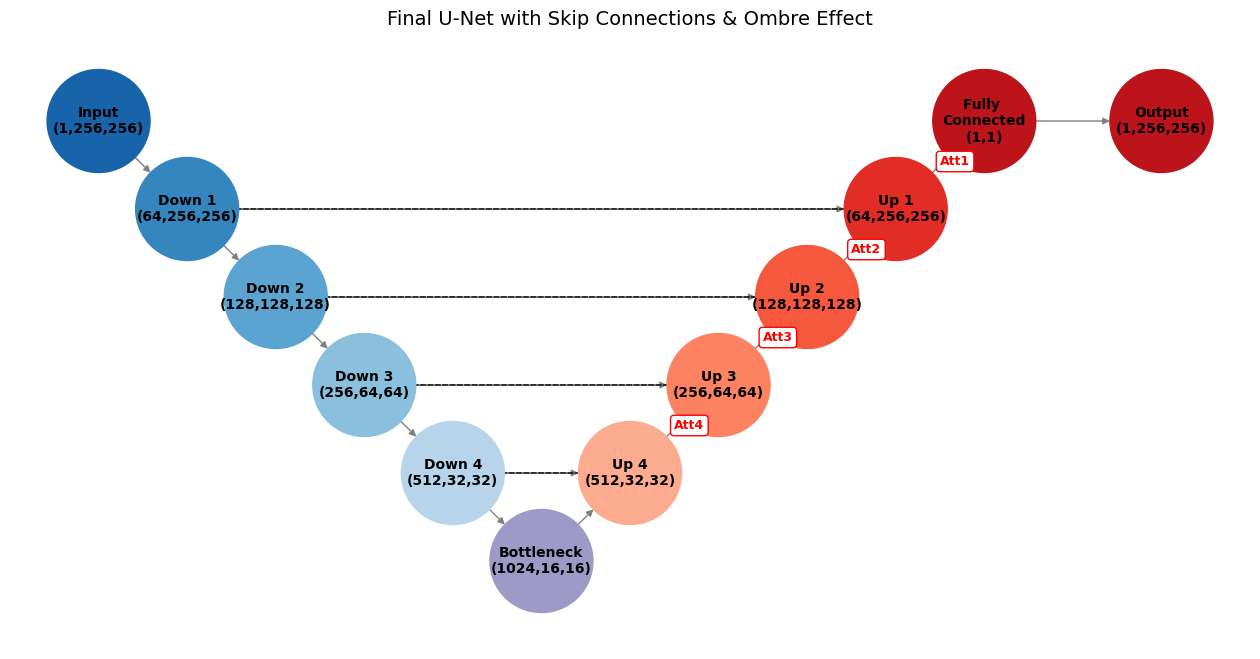

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def draw_unet_with_skip_connections():
    G = nx.DiGraph()

    # Define positions ensuring perfect U-shape & proper spacing
    positions = {
        "Input": (1, 7),
        "Down1": (2, 6),
        "Down2": (3, 5),
        "Down3": (4, 4),
        "Down4": (5, 3),
        "Bottleneck": (6, 2),
        "Up4": (7, 3),
        "Up3": (8, 4),
        "Up2": (9, 5),
        "Up1": (10, 6),
        "FullyConnected": (11, 7),
        "Output": (13, 7)  # Output moved farther right for no overlap
    }

    # Define text labels with proper line breaks for best fit
    node_labels = {
        "Input": "Input\n(1,256,256)",
        "Down1": "Down 1\n(64,256,256)",
        "Down2": "Down 2\n(128,128,128)",
        "Down3": "Down 3\n(256,64,64)",
        "Down4": "Down 4\n(512,32,32)",
        "Bottleneck": "Bottleneck\n(1024,16,16)",
        "Up4": "Up 4\n(512,32,32)",
        "Up3": "Up 3\n(256,64,64)",
        "Up2": "Up 2\n(128,128,128)",
        "Up1": "Up 1\n(64,256,256)",
        "FullyConnected": "Fully \nConnected\n(1,1)",
        "Output": "Output\n(1,256,256)"
    }

    # Define main connections (Layer-to-layer U shape)
    edges = [
        ("Input", "Down1"),
        ("Down1", "Down2"),
        ("Down2", "Down3"),
        ("Down3", "Down4"),
        ("Down4", "Bottleneck"),
        ("Bottleneck", "Up4"),
        ("Up4", "Up3"),
        ("Up3", "Up2"),
        ("Up2", "Up1"),
        ("Up1", "FullyConnected"),
        ("FullyConnected", "Output")  # Directed to the right
    ]

    # Define skip connections (Connecting encoder to decoder)
    skip_connections = [
        ("Down4", "Up4"),
        ("Down3", "Up3"),
        ("Down2", "Up2"),
        ("Down1", "Up1"),
    ]

    # Create the graph
    for node in node_labels:
        G.add_node(node)

    for edge in edges:
        G.add_edge(*edge)

    for skip in skip_connections:
        G.add_edge(*skip, style="dashed")  # Dashed edges for skip connections

    # Define arrow styles for Attention Layers
    attention_edges = {
        ("Up4", "Up3"): "Att4",
        ("Up3", "Up2"): "Att3",
        ("Up2", "Up1"): "Att2",
        ("Up1", "FullyConnected"): "Att1"
    }

    # Assign two colors for ombre effect
    encoder_color = plt.cm.Blues  # Color for encoder path
    decoder_color = plt.cm.Reds  # Color for decoder path

    # Assign gradient colors
    encoder_nodes = ["Input", "Down1", "Down2", "Down3", "Down4"]
    decoder_nodes = ["Up4", "Up3", "Up2", "Up1", "FullyConnected"]
    bottleneck_node = "Bottleneck"
    output_node = "Output"

    encoder_colors = [encoder_color(i) for i in np.linspace(0.8, 0.3, len(encoder_nodes))]
    decoder_colors = [decoder_color(i) for i in np.linspace(0.3, 0.8, len(decoder_nodes))]
    bottleneck_color = plt.cm.Purples(0.5)  # Neutral blend
    output_color = decoder_colors[-1]  # Same as extreme decoder color

    # Map node names to colors
    node_colors = {node: color for node, color in zip(encoder_nodes, encoder_colors)}
    node_colors.update({node: color for node, color in zip(decoder_nodes, decoder_colors)})
    node_colors[bottleneck_node] = bottleneck_color
    node_colors[output_node] = output_color

    # Increase figure size to prevent cutoffs
    plt.figure(figsize=(16, 8))  # Wider figure for better spacing
    ax = plt.gca()

    # Draw nodes with ombre effect
    nx.draw(
        G, pos=positions, with_labels=True, node_size=5500,
        edge_color="gray", font_size=10, font_weight="bold", labels=node_labels,
        verticalalignment="center", node_shape="o", arrows=True,
        node_color=[node_colors[node] for node in G.nodes()]  # Apply gradient colors
    )

    # Draw skip connections as dashed lines
    nx.draw_networkx_edges(
        G, pos=positions, edgelist=skip_connections,
        edge_color="black", style="dashed", arrows=True
    )

    # Draw attention indicators on specific edges
    for (edge, att_name) in attention_edges.items():
        start, end = edge
        x1, y1 = positions[start]
        x2, y2 = positions[end]
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2

        plt.text(mid_x, mid_y, att_name, fontsize=9, color="red", fontweight="bold",
                 bbox=dict(facecolor="white", edgecolor="red", boxstyle="round,pad=0.3"))

    # Increase border padding to prevent cutoffs
    plt.xlim(0, 14)
    plt.ylim(1, 8)

    plt.title("Final U-Net with Skip Connections & Ombre Effect", fontsize=14)
    plt.show()

# Run function to display the final U-Net diagram
draw_unet_with_skip_connections()


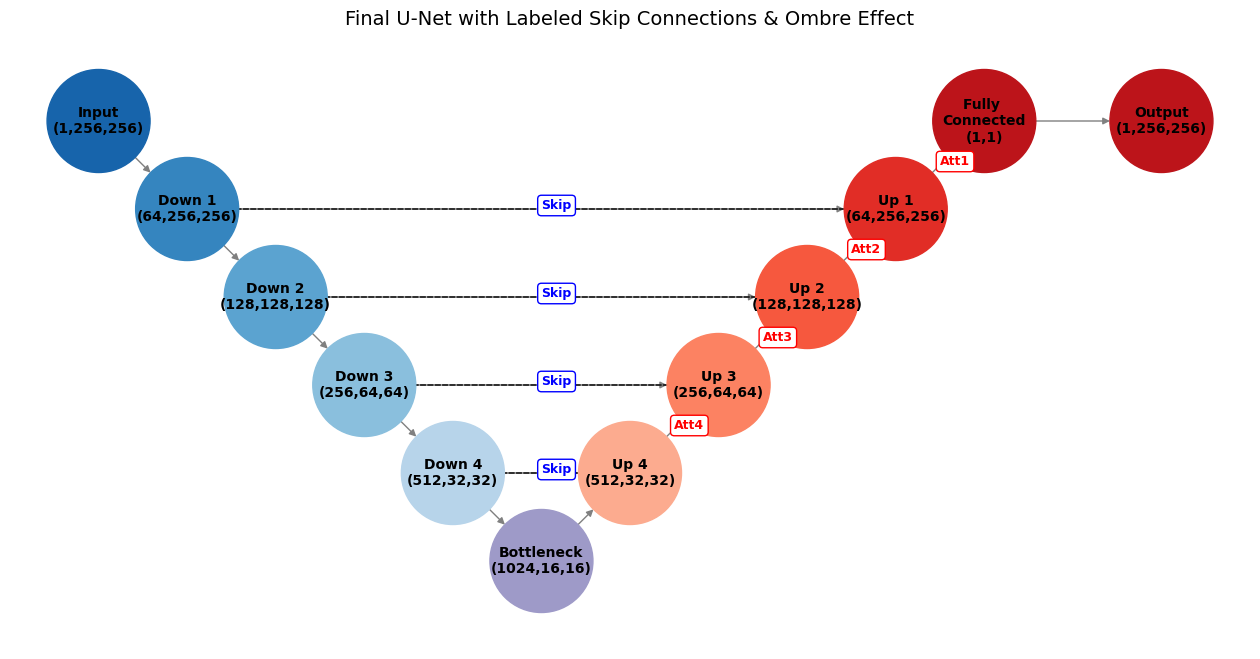

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

def draw_unet_with_labeled_skip_connections():
    G = nx.DiGraph()

    # Define positions ensuring perfect U-shape & proper spacing
    positions = {
        "Input": (1, 7),
        "Down1": (2, 6),
        "Down2": (3, 5),
        "Down3": (4, 4),
        "Down4": (5, 3),
        "Bottleneck": (6, 2),
        "Up4": (7, 3),
        "Up3": (8, 4),
        "Up2": (9, 5),
        "Up1": (10, 6),
        "FullyConnected": (11, 7),
        "Output": (13, 7)  # Output moved farther right for no overlap
    }

    # Define text labels with proper line breaks for best fit
    node_labels = {
        "Input": "Input\n(1,256,256)",
        "Down1": "Down 1\n(64,256,256)",
        "Down2": "Down 2\n(128,128,128)",
        "Down3": "Down 3\n(256,64,64)",
        "Down4": "Down 4\n(512,32,32)",
        "Bottleneck": "Bottleneck\n(1024,16,16)",
        "Up4": "Up 4\n(512,32,32)",
        "Up3": "Up 3\n(256,64,64)",
        "Up2": "Up 2\n(128,128,128)",
        "Up1": "Up 1\n(64,256,256)",
        "FullyConnected": "Fully \nConnected\n(1,1)",
        "Output": "Output\n(1,256,256)"
    }

    # Define main connections (Layer-to-layer U shape)
    edges = [
        ("Input", "Down1"),
        ("Down1", "Down2"),
        ("Down2", "Down3"),
        ("Down3", "Down4"),
        ("Down4", "Bottleneck"),
        ("Bottleneck", "Up4"),
        ("Up4", "Up3"),
        ("Up3", "Up2"),
        ("Up2", "Up1"),
        ("Up1", "FullyConnected"),
        ("FullyConnected", "Output")  # Directed to the right
    ]

    # Define skip connections (Connecting encoder to decoder)
    skip_connections = [
        ("Down4", "Up4"),
        ("Down3", "Up3"),
        ("Down2", "Up2"),
        ("Down1", "Up1"),
    ]

    # Create the graph
    for node in node_labels:
        G.add_node(node)

    for edge in edges:
        G.add_edge(*edge)

    for skip in skip_connections:
        G.add_edge(*skip, style="dashed")  # Dashed edges for skip connections

    # Define arrow styles for Attention Layers
    attention_edges = {
        ("Up4", "Up3"): "Att4",
        ("Up3", "Up2"): "Att3",
        ("Up2", "Up1"): "Att2",
        ("Up1", "FullyConnected"): "Att1"
    }

    # Assign two colors for ombre effect
    encoder_color = plt.cm.Blues  # Color for encoder path
    decoder_color = plt.cm.Reds  # Color for decoder path

    # Assign gradient colors
    encoder_nodes = ["Input", "Down1", "Down2", "Down3", "Down4"]
    decoder_nodes = ["Up4", "Up3", "Up2", "Up1", "FullyConnected"]
    bottleneck_node = "Bottleneck"
    output_node = "Output"

    encoder_colors = [encoder_color(i) for i in np.linspace(0.8, 0.3, len(encoder_nodes))]
    decoder_colors = [decoder_color(i) for i in np.linspace(0.3, 0.8, len(decoder_nodes))]
    bottleneck_color = plt.cm.Purples(0.5)  # Neutral blend
    output_color = decoder_colors[-1]  # Same as extreme decoder color

    # Map node names to colors
    node_colors = {node: color for node, color in zip(encoder_nodes, encoder_colors)}
    node_colors.update({node: color for node, color in zip(decoder_nodes, decoder_colors)})
    node_colors[bottleneck_node] = bottleneck_color
    node_colors[output_node] = output_color

    # Increase figure size to prevent cutoffs
    plt.figure(figsize=(16, 8))  # Wider figure for better spacing
    ax = plt.gca()

    # Draw nodes with ombre effect
    nx.draw(
        G, pos=positions, with_labels=True, node_size=5500,
        edge_color="gray", font_size=10, font_weight="bold", labels=node_labels,
        verticalalignment="center", node_shape="o", arrows=True,
        node_color=[node_colors[node] for node in G.nodes()]  # Apply gradient colors
    )

    # Draw skip connections as dashed lines
    nx.draw_networkx_edges(
        G, pos=positions, edgelist=skip_connections,
        edge_color="black", style="dashed", arrows=True
    )

    # Label Skip Connections
    for start, end in skip_connections:
        x1, y1 = positions[start]
        x2, y2 = positions[end]
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2

        plt.text(mid_x, mid_y, "Skip", fontsize=9, color="blue", fontweight="bold",
                 bbox=dict(facecolor="white", edgecolor="blue", boxstyle="round,pad=0.3"))

    # Draw attention indicators on specific edges
    for (edge, att_name) in attention_edges.items():
        start, end = edge
        x1, y1 = positions[start]
        x2, y2 = positions[end]
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2

        plt.text(mid_x, mid_y, att_name, fontsize=9, color="red", fontweight="bold",
                 bbox=dict(facecolor="white", edgecolor="red", boxstyle="round,pad=0.3"))

    # Increase border padding to prevent cutoffs
    plt.xlim(0, 14)
    plt.ylim(1, 8)

    plt.title("Final U-Net with Labeled Skip Connections & Ombre Effect", fontsize=14)
    plt.show()

# Run function to display the final U-Net diagram
draw_unet_with_labeled_skip_connections()


# Grad-CAM 4D Compatibility for Patient/Testing Classes

Override PatientDataset

In [ ]:
# override PatientDataset
class PatientDataset(Dataset):
    def __init__(self, transform=None, augmented_dataset=False, augment=0, threshold=False, speckle=False,
                 despeckle=False, region="B", number_of_image=1, crop=[1, 1, 1], output="FM"):
        self.root_dir = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images_bluethingremoved'
        self.patients = os.listdir(self.root_dir)
        for data in test_data:
            self.patients.remove(str(data))
        self.transform = transform
        self.augment = augment
        self.threshold = threshold
        self.speckle = speckle
        self.augmented_dataset = augmented_dataset
        self.despeckle = despeckle
        self.region = region  # Single region (e.g., "B")
        self.number_of_image = number_of_image
        self.crop = crop
        self.output = output

    def __len__(self):
        return len(self.patients)

    def __getitem__(self, idx):
        patient_id = self.patients[idx]
        patient_path = os.path.join(self.root_dir, patient_id)
        try:
            image = self.load_patient_data(patient_path)
            label = self.get_label(int(patient_id))
            weight = labels_dict[int(patient_id)][2]
            length = labels_dict[int(patient_id)][3]
            return image, label, weight, length
        except Exception as e:
            print(f"Error loading data for patient {patient_id}: {e}")
            return None

    def get_label(self, patient_id):
        if self.output == "FM":
            return labels_dict[patient_id][0]
        elif self.output == "FFM":
            return labels_dict[patient_id][1]
        elif self.output == "PerFM":
            return labels_dict[patient_id][0]
        elif self.output == "PerFFM":
            return labels_dict[patient_id][1]
        else:
            raise ValueError(f"Invalid output type: {self.output}")
    def preprocess(self, img_path, crop):
        image = Image.open(img_path).convert("RGB")  # Ensure image is in RGB format
        width, height = image.size
        crop_rectangle = (0, 0, width, round(height * crop))
        image = image.crop(crop_rectangle)
        if self.speckle:
            image = image.filter(ImageFilter.MedianFilter(size=5))
        if self.threshold:
            image_np = np.array(image)
            image_np = np.where(image_np < 100, 0, image_np)
            image = Image.fromarray(image_np)
        if self.despeckle:
            image_np = np.array(image)
            despeckled_image = cv2.fastNlMeansDenoisingColored(image_np, None, h=10, templateWindowSize=7, searchWindowSize=21)
            image = Image.fromarray(despeckled_image)
        if self.transform:
            image = self.transform(image)
        return image

    def load_patient_data(self, patient_path):
        print(f"Checking patient path: {patient_path}")
        print(f"Available files: {os.listdir(patient_path)}")
        for img_file in os.listdir(patient_path):
            print(f"Checking file: {img_file} for region {self.region}")
            if f"_{self.region}" in img_file:
                img_path = os.path.join(patient_path, img_file)
                image = self.preprocess(img_path, self.crop[0])
                return image
        raise ValueError(f"No image found for region {self.region} in patient {patient_path}")

Override TestPatientDataset

In [ ]:
# Override test patient dataset
class TestPatientDataset(Dataset):
    def __init__(self, transform=None, augmented_dataset=False, augment=0, threshold=False, speckle=False,
                 despeckle=False, region_combination='A', number_of_image=1, crop=[1, 1, 1], output="FM"):
        self.root_dir = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images_bluethingremoved'
        self.patients = PATIENTS
        self.transform = transform
        self.augment = augment
        self.threshold = threshold
        self.speckle = speckle
        self.augmented_dataset = augmented_dataset
        self.despeckle = despeckle
        self.region_combination = region_combination
        self.number_of_image = number_of_image
        # Crop in the order of Abdomen, Biceps, and Quadriceps
        self.crop = crop
        self.output = output

    def __len__(self):
        return len(self.patients)

    def __getitem__(self, idx):
        patient_id = self.patients[idx]
        patient_path = os.path.join(self.root_dir, patient_id)
        images = self.load_patient_data(patient_path)
        if self.output == "FM":
            return images, test_labels_dict[int(patient_id)][0], test_labels_dict[int(patient_id)][2], test_labels_dict[int(patient_id)][3]
        elif self.output == "FFM":
            return images, test_labels_dict[int(patient_id)][1], test_labels_dict[int(patient_id)][2], test_labels_dict[int(patient_id)][3]
        elif self.output == "PerFM":
            return images, test_labels_dict[int(patient_id)][0], test_labels_dict[int(patient_id)][2], test_labels_dict[int(patient_id)][3]
        elif self.output == "PerFFM":
            return images, test_labels_dict[int(patient_id)][1], test_labels_dict[int(patient_id)][2], test_labels_dict[int(patient_id)][3]
        else:
            raise ValueError(f"Invalid output type: {self.output}")

    def preprocess(self, img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, crop):
        image = Image.open(img_path)
        width, height = image.size
        crop_rectangle = (0, 0, width, round(height * crop))
        image = image.crop(crop_rectangle)
        if self.speckle:
            image = image.filter(ImageFilter.MedianFilter(size=MF_size))
        if self.threshold:
            image = torch.where(image < threshold / 255, torch.tensor(0.0), image)
        if self.despeckle:
            image_np = np.array(image)
            despeckled_image = cv2.fastNlMeansDenoisingColored(image_np, None, h=h, templateWindowSize=templateWindowSize, searchWindowSize=searchWindowSize)
            image = Image.fromarray(despeckled_image)
        if not self.augmented_dataset:
            image = self.transform(image)
        images.append(image)

        # Augmentation
        if self.augment >= 5:
            imx = image
            imx = TF.hflip(imx)
            images.append(imx)
            imx = TF.vflip(imx)
            images.append(imx)
            angle = random.choice([-30, -90, -60, -45, -15, 0, 15, 30, 45, 60, 90])
            imx = TF.rotate(imx, angle)
            images.append(imx)
            angle = random.choice([-30, -90, -60, -45, -15, 0, 15, 30, 45, 60, 90])
            imx = TF.rotate(imx, angle)
            images.append(imx)
        if self.augment >= 8:
            imx = TF.vflip(imx)
            images.append(imx)
            angle = random.choice([15])
            imx = TF.rotate(imx, angle)
            images.append(imx)
            angle = random.choice([45])
            imx = TF.rotate(imx, angle)
            images.append(imx)
        if self.augment >= 15:
            imx = image
            angle = random.choice([-30, -90, -60, -45, -15, 0, 15, 30, 45, 60, 90])
            imx = TF.rotate(imx, angle)
            images.append(imx)
            imx = image
            angle = random.choice([-90])
            imx = TF.rotate(imx, angle)
            images.append(imx)
            imx = image
            angle = random.choice([-60])
            imx = TF.rotate(imx, angle)
            images.append(imx)
            angle = random.choice([-45])
            imx = TF.rotate(imx, angle)
            images.append(imx)
            angle = random.choice([-15])
            imx = TF.rotate(imx, angle)
            images.append(imx)
            angle = random.choice([30])
            imx = TF.rotate(imx, angle)
            images.append(imx)
            angle = random.choice([60])
            imx = TF.rotate(imx, angle)
            images.append(imx)
        return images

    def load_patient_data(self, patient_path):
        images = []
        threshold = 100
        AB = 0
        BICEP = 0
        QUAD = 0
        MF_size = 5
        h = 10
        templateWindowSize = 7
        searchWindowSize = 21
        for img_file in os.listdir(patient_path):
            # Process Abdomen images
            if 'A' in self.region_combination and '_A' in img_file and AB < self.number_of_image:
                img_path = os.path.join(patient_path, img_file)
                images = self.preprocess(img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, self.crop[0])
                AB += 1
            # Process Bicep images
            elif 'B' in self.region_combination and '_B' in img_file and BICEP < self.number_of_image:
                img_path = os.path.join(patient_path, img_file)
                images = self.preprocess(img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, self.crop[1])
                BICEP += 1
            # Process Quad images
            elif 'Q' in self.region_combination and '_Q' in img_file and QUAD < self.number_of_image:
                img_path = os.path.join(patient_path, img_file)
                images = self.preprocess(img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, self.crop[2])
                QUAD += 1
        return images

# AttUNet Grad-CAM compatible

Override Training

In [ ]:
# THIS one works
def training(epochs, criterion, lr, model, MODEL, adaptive=True, weight_length=False):
    if criterion == "MSE":
        criterion = nn.MSELoss()
    elif criterion == "MAE":
        criterion = nn.L1Loss()
    elif criterion == "MAPE":
        criterion = MAPELoss()

    # Move the model to GPU
    model = model.to('cuda')

    ### Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    if adaptive:
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    train_running_loss_history = []
    validation_running_loss_history = []

    for e in range(epochs):
        train_running_loss = 0.0
        validation_running_loss = 0.0
        model.train()
        for ith_batch, batch in enumerate(train_loader):
            # Ensure X_train is properly shaped
            if isinstance(batch[0], torch.Tensor):
                X_train = batch[0].to('cuda').float()
            else:
                X_train = torch.stack([img for img in batch[0]]).to('cuda').float()

            # Remove extra dimensions if present
            if X_train.dim() == 5:  # If it's a 5D tensor, squeeze out unnecessary dimension
                X_train = X_train.squeeze(1)

            if weight_length:
                if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
                    additional_data_train = torch.tensor([[batch[2].item(), batch[3].item()]]).to('cuda').float()
                elif MODEL == "UNet":
                    weight = batch[2].to('cuda').float()[0]
                    length = batch[3].to('cuda').float()[0]
                y_train = batch[1].to('cuda').float()[0]
                y_pred = model(X_train, weight, length)[0]
            else:
                y_train = batch[1].to('cuda').float()[0]
                y_pred = model(X_train)[0]

            # Compute loss
            loss = criterion(y_pred, y_train)

            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if ith_batch % 5 == 0:
                print('Epoch: ', e + 1, 'Batch: ', ith_batch, 'Current Loss: ', loss.item())

            train_running_loss += loss.item()

        with torch.no_grad():
            model.eval()
            for ith_batch, batch in enumerate(test_loader):
                # Ensure X_val is properly shaped
                if isinstance(batch[0], torch.Tensor):
                    X_val = batch[0].to('cuda').float()
                else:
                    X_val = torch.stack([img for img in batch[0]]).to('cuda').float()

                # Remove extra dimensions if present
                if X_val.dim() == 5:  # If it's a 5D tensor, squeeze out unnecessary dimension
                    X_val = X_val.squeeze(1)

                if weight_length:
                    if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
                        additional_data_val = torch.tensor([[batch[2].item(), batch[3].item()]]).to('cuda').float()
                    elif MODEL == "UNet":
                        weight = batch[2].to('cuda').float()[0]
                        length = batch[3].to('cuda').float()[0]
                    y_val = batch[1].to('cuda').float()[0]
                    y_out = model(X_val, weight, length)[0]
                else:
                    y_val = batch[1].to('cuda').float()[0]
                    y_out = model(X_val)[0]

                val_loss = criterion(y_out, y_val)
                validation_running_loss += val_loss.item()

            print("================================================================================")
            print("Epoch {} completed".format(e + 1))
            train_epoch_loss = train_running_loss / len(train_loader)
            validation_epoch_loss = validation_running_loss / len(test_loader)
            print("Average train loss is {}: ".format(train_epoch_loss))
            print("Average validation loss is {}".format(validation_epoch_loss))
            print("================================================================================")
            train_running_loss_history.append(train_epoch_loss)
            validation_running_loss_history.append(validation_epoch_loss)

        torch.cuda.empty_cache()

        if adaptive:
            scheduler.step()

    return train_running_loss_history, validation_running_loss_history

In [ ]:
class conv_block(nn.Module):
    def __init__(self,ch_in,ch_out):
        super(conv_block,self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(ch_in, ch_out, kernel_size=3,stride=1,padding=1,bias=True),
            nn.BatchNorm2d(ch_out),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch_out, ch_out, kernel_size=3,stride=1,padding=1,bias=True),
            nn.BatchNorm2d(ch_out),
            nn.ReLU(inplace=True)
        )
    def forward(self,x):
        x = self.conv(x)
        return x

class up_conv(nn.Module):
    def __init__(self,ch_in,ch_out):
        super(up_conv,self).__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(ch_in,ch_out,kernel_size=3,stride=1,padding=1,bias=True),
		    nn.BatchNorm2d(ch_out),
			nn.ReLU(inplace=True)
        )

    def forward(self,x):
        x = self.up(x)
        return x

class Attention_block(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(Attention_block, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        try:
            psi = self.relu(g1+x1)
        except:
            psi = self.relu(F.pad(g1,(1,0,1,0)) + x1)
        psi = self.psi(psi)
        return x * psi


class AttUNet(nn.Module):
    def __init__(self, img_ch=1, output_ch=1):
        super(AttUNet, self).__init__()
        self.Maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.Conv1 = conv_block(ch_in=img_ch, ch_out=64)
        self.Conv2 = conv_block(ch_in=64, ch_out=128)
        self.Conv3 = conv_block(ch_in=128, ch_out=256)
        self.Conv4 = conv_block(ch_in=256, ch_out=512)
        self.Conv5 = conv_block(ch_in=512, ch_out=1024)
        self.Up5 = up_conv(ch_in=1024, ch_out=512)
        self.Att5 = Attention_block(F_g=512, F_l=512, F_int=256)
        self.Up_conv5 = conv_block(ch_in=1024, ch_out=512)
        self.Up4 = up_conv(ch_in=512, ch_out=256)
        self.Att4 = Attention_block(F_g=256, F_l=256, F_int=128)
        self.Up_conv4 = conv_block(ch_in=512, ch_out=256)
        self.Up3 = up_conv(ch_in=256, ch_out=128)
        self.Att3 = Attention_block(F_g=128, F_l=128, F_int=64)
        self.Up_conv3 = conv_block(ch_in=256, ch_out=128)
        self.Up2 = up_conv(ch_in=128, ch_out=64)
        self.Att2 = Attention_block(F_g=64, F_l=64, F_int=32)
        self.Up_conv2 = conv_block(ch_in=128, ch_out=64)
        self.Conv_1x1 = nn.Conv2d(64, output_ch, kernel_size=1, stride=1, padding=0)
        self.sigmoid = nn.Sigmoid()
        self.linear1 = nn.Linear(256*256, 1)
        self.linear2 = nn.Linear(1, 1)
        self.flatten = nn.Flatten()
    def forward(self, x):
      x1 = self.Conv1(x)
      x2 = self.Maxpool(x1)
      x2 = self.Conv2(x2)
      x3 = self.Maxpool(x2)
      x3 = self.Conv3(x3)
      x4 = self.Maxpool(x3)
      x4 = self.Conv4(x4)
      x5 = self.Maxpool(x4)
      x5 = self.Conv5(x5)

      # Decoding path
      d5 = self.Up5(x5)
      x4 = self.Att5(g=d5, x=x4)
      d5 = torch.cat((x4, d5), dim=1)
      d5 = self.Up_conv5(d5)

      d4 = self.Up4(d5)
      x3 = self.Att4(g=d4, x=x3)
      d4 = torch.cat((x3, d4), dim=1)
      d4 = self.Up_conv4(d4)

      d3 = self.Up3(d4)
      x2 = self.Att3(g=d3, x=x2)
      d3 = torch.cat((x2, d3), dim=1)
      d3 = self.Up_conv3(d3)

      d2 = self.Up2(d3)
      x1 = self.Att2(g=d2, x=x1)
      d2 = torch.cat((x1, d2), dim=1)
      d2 = self.Up_conv2(d2)

      d1 = self.Conv_1x1(d2)  # Shape: (batch_size, 1, 256, 256)
      d1 = self.sigmoid(d1)

      # **For Grad-CAM, return 4D output**
      if self.training:
          return d1

      # **For Evaluation, Convert to Scalar Predictions**
      d1_scalar = F.adaptive_avg_pool2d(d1, (1, 1))  # Shape: (batch_size, 1, 1)
      d1_scalar = d1_scalar.view(d1_scalar.shape[0], -1)  # Flatten to (batch_size, 1)
      return d1_scalar


In [ ]:
MODEL = "AttUNet"
model = AttUNet(3, 1).cuda()

# UNet++

In [ ]:
from torch.nn import init

def weights_init_normal(m):
    classname = m.__class__.__name__
    #print(classname)
    if classname.find('Conv') != -1:
        init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('Linear') != -1:
        init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        init.normal_(m.weight.data, 1.0, 0.02)
        init.constant_(m.bias.data, 0.0)


def weights_init_xavier(m):
    classname = m.__class__.__name__
    #print(classname)
    if classname.find('Conv') != -1:
        init.xavier_normal_(m.weight.data, gain=1)
    elif classname.find('Linear') != -1:
        init.xavier_normal_(m.weight.data, gain=1)
    elif classname.find('BatchNorm') != -1:
        init.normal_(m.weight.data, 1.0, 0.02)
        init.constant_(m.bias.data, 0.0)


def weights_init_kaiming(m):
    classname = m.__class__.__name__
    #print(classname)
    if classname.find('Conv') != -1:
        init.kaiming_normal_(m.weight.data, a=0, mode='fan_in')
    elif classname.find('Linear') != -1:
        init.kaiming_normal_(m.weight.data, a=0, mode='fan_in')
    elif classname.find('BatchNorm') != -1:
        init.normal_(m.weight.data, 1.0, 0.02)
        init.constant_(m.bias.data, 0.0)


def weights_init_orthogonal(m):
    classname = m.__class__.__name__
    #print(classname)
    if classname.find('Conv') != -1:
        init.orthogonal_(m.weight.data, gain=1)
    elif classname.find('Linear') != -1:
        init.orthogonal_(m.weight.data, gain=1)
    elif classname.find('BatchNorm') != -1:
        init.normal_(m.weight.data, 1.0, 0.02)
        init.constant_(m.bias.data, 0.0)


def init_weights(net, init_type='normal'):
    #print('initialization method [%s]' % init_type)
    if init_type == 'normal':
        net.apply(weights_init_normal)
    elif init_type == 'xavier':
        net.apply(weights_init_xavier)
    elif init_type == 'kaiming':
        net.apply(weights_init_kaiming)
    elif init_type == 'orthogonal':
        net.apply(weights_init_orthogonal)
    else:
        raise NotImplementedError('initialization method [%s] is not implemented' % init_type)

In [ ]:
class unetConv2(nn.Module):
    def __init__(self, in_size, out_size, is_batchnorm, n=2, ks=3, stride=1, padding=1):
        super(unetConv2, self).__init__()
        self.n = n
        self.ks = ks
        self.stride = stride
        self.padding = padding
        s = stride
        p = padding

        if is_batchnorm:
            for i in range(1, n + 1):
                conv = nn.Sequential(nn.Conv2d(in_size, out_size, ks, s, p),
                                     nn.BatchNorm2d(out_size),
                                     nn.ReLU(inplace=True), )
                setattr(self, 'conv%d' % i, conv)
                in_size = out_size

        else:
            for i in range(1, n + 1):
                conv = nn.Sequential(nn.Conv2d(in_size, out_size, ks, s, p),
                                     nn.ReLU(inplace=True), )
                setattr(self, 'conv%d' % i, conv)
                in_size = out_size

        # initialise the blocks
        for m in self.children():
            init_weights(m, init_type='kaiming')

    def forward(self, inputs):
        x = inputs
        for i in range(1, self.n + 1):
            conv = getattr(self, 'conv%d' % i)
            x = conv(x)

        return x

class unetUp(nn.Module):
    def __init__(self, in_size, out_size, is_deconv, n_concat=2):
        super(unetUp, self).__init__()
        # self.conv = unetConv2(in_size + (n_concat - 2) * out_size, out_size, False)
        self.conv = unetConv2(out_size*2, out_size, False)
        if is_deconv:
            self.up = nn.ConvTranspose2d(in_size, out_size, kernel_size=4, stride=2, padding=1)
        else:
            self.up = nn.UpsamplingBilinear2d(scale_factor=2)

        # initialise the blocks
        for m in self.children():
            if m.__class__.__name__.find('unetConv2') != -1: continue
            init_weights(m, init_type='kaiming')

    def forward(self, inputs0, *input):
        # print(self.n_concat)
        # print(input)
        outputs0 = self.up(inputs0)
        for i in range(len(input)):
            outputs0 = torch.cat([outputs0, input[i]], 1)
        return self.conv(outputs0)

class unetUp_origin(nn.Module):
    def __init__(self, in_size, out_size, is_deconv, n_concat=2):
        super(unetUp_origin, self).__init__()
        # self.conv = unetConv2(out_size*2, out_size, False)
        if is_deconv:
            self.conv = unetConv2(in_size + (n_concat - 2) * out_size, out_size, False)
            self.up = nn.ConvTranspose2d(in_size, out_size, kernel_size=2, stride=2)
        else:
            self.conv = unetConv2(in_size + (n_concat - 2) * out_size, out_size, False)
            self.up = nn.UpsamplingBilinear2d(scale_factor=2)

        # initialise the blocks
        for m in self.children():
            if m.__class__.__name__.find('unetConv2') != -1: continue
            init_weights(m, init_type='kaiming')

    def forward(self, inputs0, *input):
        x1 = self.up(inputs0)
        # input is CHW
        for i in range(len(input)):
            try:
                x1 = torch.cat((x1,input[i]),1)
            except:
                x1 = torch.cat((F.pad(x1,(1,0,1,0)),input[i]),1)
        return self.conv(x1)

In [ ]:
class UNet_2Plus(nn.Module):
    def __init__(self, in_channels=3, n_classes=1, feature_scale=4, is_deconv=True, is_batchnorm=True, is_ds=True):
        super(UNet_2Plus, self).__init__()
        self.is_deconv = is_deconv
        self.in_channels = in_channels
        self.is_batchnorm = is_batchnorm
        self.is_ds = is_ds
        self.feature_scale = feature_scale

        filters = [64, 128, 256, 512, 1024]

        # downsampling
        self.conv00 = unetConv2(self.in_channels, filters[0], self.is_batchnorm)
        self.maxpool0 = nn.MaxPool2d(kernel_size=2)
        self.conv10 = unetConv2(filters[0], filters[1], self.is_batchnorm)
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)
        self.conv20 = unetConv2(filters[1], filters[2], self.is_batchnorm)
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)
        self.conv30 = unetConv2(filters[2], filters[3], self.is_batchnorm)
        self.maxpool3 = nn.MaxPool2d(kernel_size=2)
        self.conv40 = unetConv2(filters[3], filters[4], self.is_batchnorm)


        # upsampling
        self.up_concat01 = unetUp_origin(filters[1], filters[0], self.is_deconv)
        self.up_concat11 = unetUp_origin(filters[2], filters[1], self.is_deconv)
        self.up_concat21 = unetUp_origin(filters[3], filters[2], self.is_deconv)
        self.up_concat31 = unetUp_origin(filters[4], filters[3], self.is_deconv)

        self.up_concat02 = unetUp_origin(filters[1], filters[0], self.is_deconv, 3)
        self.up_concat12 = unetUp_origin(filters[2], filters[1], self.is_deconv, 3)
        self.up_concat22 = unetUp_origin(filters[3], filters[2], self.is_deconv, 3)

        self.up_concat03 = unetUp_origin(filters[1], filters[0], self.is_deconv, 4)
        self.up_concat13 = unetUp_origin(filters[2], filters[1], self.is_deconv, 4)

        self.up_concat04 = unetUp_origin(filters[1], filters[0], self.is_deconv, 5)

        # final conv (without any concat)
        self.final_1 = nn.Conv2d(filters[0], n_classes, 1)
        self.final_2 = nn.Conv2d(filters[0], n_classes, 1)
        self.final_3 = nn.Conv2d(filters[0], n_classes, 1)
        self.final_4 = nn.Conv2d(filters[0], n_classes, 1)

        # initialise weights
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                init_weights(m, init_type='kaiming')
            elif isinstance(m, nn.BatchNorm2d):
                init_weights(m, init_type='kaiming')
        self.linear1 = nn.Linear(256*256, 1)
        self.linear2 = nn.Linear(6, 1)
        self.flatten = nn.Flatten()

    def forward(self, inputs):
        outputs = []
        for image in inputs:
          # column : 0
          X_00 = self.conv00(image)
          maxpool0 = self.maxpool0(X_00)
          X_10 = self.conv10(maxpool0)
          maxpool1 = self.maxpool1(X_10)
          X_20 = self.conv20(maxpool1)
          maxpool2 = self.maxpool2(X_20)
          X_30 = self.conv30(maxpool2)
          maxpool3 = self.maxpool3(X_30)
          X_40 = self.conv40(maxpool3)

          # column : 1
          X_01 = self.up_concat01(X_10, X_00)
          X_11 = self.up_concat11(X_20, X_10)
          X_21 = self.up_concat21(X_30, X_20)
          X_31 = self.up_concat31(X_40, X_30)
          # column : 2
          X_02 = self.up_concat02(X_11, X_00, X_01)
          X_12 = self.up_concat12(X_21, X_10, X_11)
          X_22 = self.up_concat22(X_31, X_20, X_21)
          # column : 3
          X_03 = self.up_concat03(X_12, X_00, X_01, X_02)
          X_13 = self.up_concat13(X_22, X_10, X_11, X_12)
          # column : 4
          X_04 = self.up_concat04(X_13, X_00, X_01, X_02, X_03)

          # final layer
          final_1 = self.final_1(X_01)
          final_2 = self.final_2(X_02)
          final_3 = self.final_3(X_03)
          final_4 = self.final_4(X_04)

          final = (final_1 + final_2 + final_3 + final_4) / 4

          if self.is_ds:
              final = F.sigmoid(final)
          else:
              final = F.sigmoid(final_4)
          final = self.flatten(final)
          final = self.linear1(final)
          outputs.append(final)
        outputs = torch.tensor(outputs).to('cuda')
        outputs = self.linear2(outputs)
        return outputs

In [ ]:
MODEL= "UNet++"
model = UNet_2Plus()
model.to('cuda')
print("Model Loaded to GPU")

Model Loaded to GPU


# RNN

In [ ]:
class RNN(nn.Module):
    def __init__(self):
        super(RNN, self).__init__()
        self.rnn = nn.LSTM(input_size=256*3,  # Each row of the image tensor is treated as a sequence step, *3 for RGB channels
                           hidden_size=128,  # Hidden state dimension
                           num_layers=1,     # Number of RNN layers
                           batch_first=True) # Input/output tensors are provided as (batch, seq, feature)
        self.fc = nn.Linear(128, 1)  # Output layer to reduce to 1 number
        self.linear = nn.Linear(6, 1)

    def forward(self, images):
        outputs = []
        for x in images:
            x = x.permute(0, 2, 1, 3)    # Change to (batch, height, channels, width)
            x = x.reshape(x.size(0), x.size(1), -1)
            x, _ = self.rnn(x)  # Output shape (batch, seq_len, hidden_size) where seq_len=256, hidden_size=128
            x = x[:, -1, :]  # Get the output of the last sequence step (batch, 128)
            x = self.fc(x)
            outputs.append(x)
        outputs = torch.tensor(outputs).to('cuda')
        outputs = self.linear(outputs)
        return outputs

In [ ]:
MODEL = "RNN"
model = RNN().cuda()

# UNeXt-S

In [ ]:
class KANLinear(torch.nn.Module):
    def __init__(
        self,
        in_features,
        out_features,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        enable_standalone_scale_spline=True,
        base_activation=torch.nn.SiLU,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        super(KANLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.grid_size = grid_size
        self.spline_order = spline_order

        h = (grid_range[1] - grid_range[0]) / grid_size
        grid = (
            (
                torch.arange(-spline_order, grid_size + spline_order + 1) * h
                + grid_range[0]
            )
            .expand(in_features, -1)
            .contiguous()
        )
        self.register_buffer("grid", grid)

        self.base_weight = torch.nn.Parameter(torch.Tensor(out_features, in_features))
        self.spline_weight = torch.nn.Parameter(
            torch.Tensor(out_features, in_features, grid_size + spline_order)
        )
        if enable_standalone_scale_spline:
            self.spline_scaler = torch.nn.Parameter(
                torch.Tensor(out_features, in_features)
            )

        self.scale_noise = scale_noise
        self.scale_base = scale_base
        self.scale_spline = scale_spline
        self.enable_standalone_scale_spline = enable_standalone_scale_spline
        self.base_activation = base_activation()
        self.grid_eps = grid_eps

        self.reset_parameters()

    def reset_parameters(self):
        torch.nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5) * self.scale_base)
        with torch.no_grad():
            noise = (
                (
                    torch.rand(self.grid_size + 1, self.in_features, self.out_features)
                    - 1 / 2
                )
                * self.scale_noise
                / self.grid_size
            )
            self.spline_weight.data.copy_(
                (self.scale_spline if not self.enable_standalone_scale_spline else 1.0)
                * self.curve2coeff(
                    self.grid.T[self.spline_order : -self.spline_order],
                    noise,
                )
            )
            if self.enable_standalone_scale_spline:
                # torch.nn.init.constant_(self.spline_scaler, self.scale_spline)
                torch.nn.init.kaiming_uniform_(self.spline_scaler, a=math.sqrt(5) * self.scale_spline)

    def b_splines(self, x: torch.Tensor):
        """
        Compute the B-spline bases for the given input tensor.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, in_features).

        Returns:
            torch.Tensor: B-spline bases tensor of shape (batch_size, in_features, grid_size + spline_order).
        """
        assert x.dim() == 2 and x.size(1) == self.in_features

        grid: torch.Tensor = (
            self.grid
        )  # (in_features, grid_size + 2 * spline_order + 1)
        x = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).to(x.dtype)
        for k in range(1, self.spline_order + 1):
            bases = (
                (x - grid[:, : -(k + 1)])
                / (grid[:, k:-1] - grid[:, : -(k + 1)])
                * bases[:, :, :-1]
            ) + (
                (grid[:, k + 1 :] - x)
                / (grid[:, k + 1 :] - grid[:, 1:(-k)])
                * bases[:, :, 1:]
            )

        assert bases.size() == (
            x.size(0),
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return bases.contiguous()

    def curve2coeff(self, x: torch.Tensor, y: torch.Tensor):
        """
        Compute the coefficients of the curve that interpolates the given points.

        Args:
            x (torch.Tensor): Input tensor of shape (batch_size, in_features).
            y (torch.Tensor): Output tensor of shape (batch_size, in_features, out_features).

        Returns:
            torch.Tensor: Coefficients tensor of shape (out_features, in_features, grid_size + spline_order).
        """
        assert x.dim() == 2 and x.size(1) == self.in_features
        assert y.size() == (x.size(0), self.in_features, self.out_features)

        A = self.b_splines(x).transpose(
            0, 1
        )  # (in_features, batch_size, grid_size + spline_order)
        B = y.transpose(0, 1)  # (in_features, batch_size, out_features)
        solution = torch.linalg.lstsq(
            A, B
        ).solution  # (in_features, grid_size + spline_order, out_features)
        result = solution.permute(
            2, 0, 1
        )  # (out_features, in_features, grid_size + spline_order)

        assert result.size() == (
            self.out_features,
            self.in_features,
            self.grid_size + self.spline_order,
        )
        return result.contiguous()

    @property
    def scaled_spline_weight(self):
        return self.spline_weight * (
            self.spline_scaler.unsqueeze(-1)
            if self.enable_standalone_scale_spline
            else 1.0
        )

    def forward(self, x: torch.Tensor):
        assert x.size(-1) == self.in_features
        original_shape = x.shape
        x = x.view(-1, self.in_features)

        base_output = F.linear(self.base_activation(x), self.base_weight)
        spline_output = F.linear(
            self.b_splines(x).view(x.size(0), -1),
            self.scaled_spline_weight.view(self.out_features, -1),
        )
        output = base_output + spline_output

        output = output.view(*original_shape[:-1], self.out_features)
        return output

    @torch.no_grad()
    def update_grid(self, x: torch.Tensor, margin=0.01):
        assert x.dim() == 2 and x.size(1) == self.in_features
        batch = x.size(0)

        splines = self.b_splines(x)  # (batch, in, coeff)
        splines = splines.permute(1, 0, 2)  # (in, batch, coeff)
        orig_coeff = self.scaled_spline_weight  # (out, in, coeff)
        orig_coeff = orig_coeff.permute(1, 2, 0)  # (in, coeff, out)
        unreduced_spline_output = torch.bmm(splines, orig_coeff)  # (in, batch, out)
        unreduced_spline_output = unreduced_spline_output.permute(
            1, 0, 2
        )  # (batch, in, out)

        # sort each channel individually to collect data distribution
        x_sorted = torch.sort(x, dim=0)[0]
        grid_adaptive = x_sorted[
            torch.linspace(
                0, batch - 1, self.grid_size + 1, dtype=torch.int64, device=x.device
            )
        ]

        uniform_step = (x_sorted[-1] - x_sorted[0] + 2 * margin) / self.grid_size
        grid_uniform = (
            torch.arange(
                self.grid_size + 1, dtype=torch.float32, device=x.device
            ).unsqueeze(1)
            * uniform_step
            + x_sorted[0]
            - margin
        )

        grid = self.grid_eps * grid_uniform + (1 - self.grid_eps) * grid_adaptive
        grid = torch.concatenate(
            [
                grid[:1]
                - uniform_step
                * torch.arange(self.spline_order, 0, -1, device=x.device).unsqueeze(1),
                grid,
                grid[-1:]
                + uniform_step
                * torch.arange(1, self.spline_order + 1, device=x.device).unsqueeze(1),
            ],
            dim=0,
        )

        self.grid.copy_(grid.T)
        self.spline_weight.data.copy_(self.curve2coeff(x, unreduced_spline_output))

    def regularization_loss(self, regularize_activation=1.0, regularize_entropy=1.0):
        """
        Compute the regularization loss.

        This is a dumb simulation of the original L1 regularization as stated in the
        paper, since the original one requires computing absolutes and entropy from the
        expanded (batch, in_features, out_features) intermediate tensor, which is hidden
        behind the F.linear function if we want an memory efficient implementation.

        The L1 regularization is now computed as mean absolute value of the spline
        weights. The authors implementation also includes this term in addition to the
        sample-based regularization.
        """
        l1_fake = self.spline_weight.abs().mean(-1)
        regularization_loss_activation = l1_fake.sum()
        p = l1_fake / regularization_loss_activation
        regularization_loss_entropy = -torch.sum(p * p.log())
        return (
            regularize_activation * regularization_loss_activation
            + regularize_entropy * regularization_loss_entropy
        )


class KAN(torch.nn.Module):
    def __init__(
        self,
        layers_hidden,
        grid_size=5,
        spline_order=3,
        scale_noise=0.1,
        scale_base=1.0,
        scale_spline=1.0,
        base_activation=torch.nn.SiLU,
        grid_eps=0.02,
        grid_range=[-1, 1],
    ):
        super(KAN, self).__init__()
        self.grid_size = grid_size
        self.spline_order = spline_order

        self.layers = torch.nn.ModuleList()
        for in_features, out_features in zip(layers_hidden, layers_hidden[1:]):
            self.layers.append(
                KANLinear(
                    in_features,
                    out_features,
                    grid_size=grid_size,
                    spline_order=spline_order,
                    scale_noise=scale_noise,
                    scale_base=scale_base,
                    scale_spline=scale_spline,
                    base_activation=base_activation,
                    grid_eps=grid_eps,
                    grid_range=grid_range,
                )
            )

    def forward(self, x: torch.Tensor, update_grid=False):
        for layer in self.layers:
            if update_grid:
                layer.update_grid(x)
            x = layer(x)
        return x

    def regularization_loss(self, regularize_activation=1.0, regularize_entropy=1.0):
        return sum(
            layer.regularization_loss(regularize_activation, regularize_entropy)
            for layer in self.layers
        )

In [ ]:
def conv1x1(in_planes: int, out_planes: int, stride: int = 1) -> nn.Conv2d:
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=1, bias=False)

class shiftmlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0., shift_size=5):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.dim = in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.dwconv = DWConv(hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

        self.shift_size = shift_size
        self.pad = shift_size // 2


        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):
        B, N, C = x.shape

        xn = x.transpose(1, 2).view(B, C, H, W).contiguous()
        xn = F.pad(xn, (self.pad, self.pad, self.pad, self.pad) , "constant", 0)
        xs = torch.chunk(xn, self.shift_size, 1)
        x_shift = [torch.roll(x_c, shift, 2) for x_c, shift in zip(xs, range(-self.pad, self.pad+1))]
        x_cat = torch.cat(x_shift, 1)
        x_cat = torch.narrow(x_cat, 2, self.pad, H)
        x_s = torch.narrow(x_cat, 3, self.pad, W)


        x_s = x_s.reshape(B,C,H*W).contiguous()
        x_shift_r = x_s.transpose(1,2)


        x = self.fc1(x_shift_r)

        x = self.dwconv(x, H, W)
        x = self.act(x)
        x = self.drop(x)

        xn = x.transpose(1, 2).view(B, C, H, W).contiguous()
        xn = F.pad(xn, (self.pad, self.pad, self.pad, self.pad) , "constant", 0)
        xs = torch.chunk(xn, self.shift_size, 1)
        x_shift = [torch.roll(x_c, shift, 3) for x_c, shift in zip(xs, range(-self.pad, self.pad+1))]
        x_cat = torch.cat(x_shift, 1)
        x_cat = torch.narrow(x_cat, 2, self.pad, H)
        x_s = torch.narrow(x_cat, 3, self.pad, W)
        x_s = x_s.reshape(B,C,H*W).contiguous()
        x_shift_c = x_s.transpose(1,2)

        x = self.fc2(x_shift_c)
        x = self.drop(x)
        return x



class shiftedBlock(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, qk_scale=None, drop=0., attn_drop=0.,
                 drop_path=0., act_layer=nn.GELU, norm_layer=nn.LayerNorm, sr_ratio=1):
        super().__init__()


        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = shiftmlp(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):

        x = x + self.drop_path(self.mlp(self.norm2(x), H, W))
        return x


class DWConv(nn.Module):
    def __init__(self, dim=768):
        super(DWConv, self).__init__()
        self.dwconv = nn.Conv2d(dim, dim, 3, 1, 1, bias=True, groups=dim)

    def forward(self, x, H, W):
        B, N, C = x.shape
        x = x.transpose(1, 2).view(B, C, H, W)
        x = self.dwconv(x)
        x = x.flatten(2).transpose(1, 2)

        return x

class OverlapPatchEmbed(nn.Module):
    """ Image to Patch Embedding
    """

    def __init__(self, img_size=224, patch_size=7, stride=4, in_chans=3, embed_dim=768):
        super().__init__()
        img_size = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)

        self.img_size = img_size
        self.patch_size = patch_size
        self.H, self.W = img_size[0] // patch_size[0], img_size[1] // patch_size[1]
        self.num_patches = self.H * self.W
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=stride,
                              padding=(patch_size[0] // 2, patch_size[1] // 2))
        self.norm = nn.LayerNorm(embed_dim)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
            fan_out //= m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x):
        x = self.proj(x)
        _, _, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)

        return x, H, W

class UNext_S(nn.Module):

    ## Conv 3 + MLP 2 + shifted MLP w less parameters

    def __init__(self, input_channels=3, deep_supervision=False,img_size=224, patch_size=16, in_chans=3,  embed_dims=[32, 64, 128, 512],
                 num_heads=[1, 2, 4, 8], mlp_ratios=[4, 4, 4, 4], qkv_bias=False, qk_scale=None, drop_rate=0.,
                 attn_drop_rate=0., drop_path_rate=0., norm_layer=nn.LayerNorm,
                 depths=[1, 1, 1], sr_ratios=[8, 4, 2, 1], **kwargs):
        super().__init__()

        self.encoder1 = nn.Conv2d(3, 8, 3, stride=1, padding=1)
        self.encoder2 = nn.Conv2d(8, 16, 3, stride=1, padding=1)
        self.encoder3 = nn.Conv2d(16, 32, 3, stride=1, padding=1)

        self.ebn1 = nn.BatchNorm2d(8)
        self.ebn2 = nn.BatchNorm2d(16)
        self.ebn3 = nn.BatchNorm2d(32)

        self.norm3 = norm_layer(embed_dims[1])
        self.norm4 = norm_layer(embed_dims[2])

        self.dnorm3 = norm_layer(64)
        self.dnorm4 = norm_layer(32)

        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]

        self.block1 = nn.ModuleList([shiftedBlock(
            dim=embed_dims[1], num_heads=num_heads[0], mlp_ratio=1, qkv_bias=qkv_bias, qk_scale=qk_scale,
            drop=drop_rate, attn_drop=attn_drop_rate, drop_path=dpr[0], norm_layer=norm_layer,
            sr_ratio=sr_ratios[0])])

        self.block2 = nn.ModuleList([shiftedBlock(
            dim=embed_dims[2], num_heads=num_heads[0], mlp_ratio=1, qkv_bias=qkv_bias, qk_scale=qk_scale,
            drop=drop_rate, attn_drop=attn_drop_rate, drop_path=dpr[1], norm_layer=norm_layer,
            sr_ratio=sr_ratios[0])])

        self.dblock1 = nn.ModuleList([shiftedBlock(
            dim=embed_dims[1], num_heads=num_heads[0], mlp_ratio=1, qkv_bias=qkv_bias, qk_scale=qk_scale,
            drop=drop_rate, attn_drop=attn_drop_rate, drop_path=dpr[0], norm_layer=norm_layer,
            sr_ratio=sr_ratios[0])])

        self.dblock2 = nn.ModuleList([shiftedBlock(
            dim=embed_dims[0], num_heads=num_heads[0], mlp_ratio=1, qkv_bias=qkv_bias, qk_scale=qk_scale,
            drop=drop_rate, attn_drop=attn_drop_rate, drop_path=dpr[1], norm_layer=norm_layer,
            sr_ratio=sr_ratios[0])])

        self.patch_embed3 = OverlapPatchEmbed(img_size=img_size // 4, patch_size=3, stride=2, in_chans=embed_dims[0],
                                              embed_dim=embed_dims[1])
        self.patch_embed4 = OverlapPatchEmbed(img_size=img_size // 8, patch_size=3, stride=2, in_chans=embed_dims[1],
                                              embed_dim=embed_dims[2])

        self.decoder1 = nn.Conv2d(128, 64, 3, stride=1,padding=1)
        self.decoder2 =   nn.Conv2d(64, 32, 3, stride=1, padding=1)
        self.decoder3 =   nn.Conv2d(32, 16, 3, stride=1, padding=1)
        self.decoder4 =   nn.Conv2d(16, 8, 3, stride=1, padding=1)
        self.decoder5 =   nn.Conv2d(8, 8, 3, stride=1, padding=1)

        self.dbn1 = nn.BatchNorm2d(64)
        self.dbn2 = nn.BatchNorm2d(32)
        self.dbn3 = nn.BatchNorm2d(16)
        self.dbn4 = nn.BatchNorm2d(8)

        self.final = nn.Conv2d(8, 1, kernel_size=1)

        self.soft = nn.Softmax(dim =1)
        self.linear1 = nn.Linear(256*256, 1)
        self.linear2 = nn.Linear(6, 1)
        self.flatten = nn.Flatten()

    def forward(self, images):
        outputs = []
        for x in images:
          B = x.shape[0]
          ### Encoder
          ### Conv Stage

          ### Stage 1
          out = F.relu(F.max_pool2d(self.ebn1(self.encoder1(x)),2,2))
          t1 = out
          ### Stage 2
          out = F.relu(F.max_pool2d(self.ebn2(self.encoder2(out)),2,2))
          t2 = out
          ### Stage 3
          out = F.relu(F.max_pool2d(self.ebn3(self.encoder3(out)),2,2))
          t3 = out

          ### Tokenized MLP Stage
          ### Stage 4

          out,H,W = self.patch_embed3(out)
          for i, blk in enumerate(self.block1):
              out = blk(out, H, W)
          out = self.norm3(out)
          out = out.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
          t4 = out

          ### Bottleneck

          out ,H,W= self.patch_embed4(out)
          for i, blk in enumerate(self.block2):
              out = blk(out, H, W)
          out = self.norm4(out)
          out = out.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()

          ### Stage 4

          out = F.relu(F.interpolate(self.dbn1(self.decoder1(out)),scale_factor=(2,2),mode ='bilinear'))

          out = torch.add(out,t4)
          _,_,H,W = out.shape
          out = out.flatten(2).transpose(1,2)
          for i, blk in enumerate(self.dblock1):
              out = blk(out, H, W)

          ### Stage 3

          out = self.dnorm3(out)
          out = out.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
          out = F.relu(F.interpolate(self.dbn2(self.decoder2(out)),scale_factor=(2,2),mode ='bilinear'))
          out = torch.add(out,t3)
          _,_,H,W = out.shape
          out = out.flatten(2).transpose(1,2)

          for i, blk in enumerate(self.dblock2):
              out = blk(out, H, W)

          out = self.dnorm4(out)
          out = out.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()

          out = F.relu(F.interpolate(self.dbn3(self.decoder3(out)),scale_factor=(2,2),mode ='bilinear'))
          out = torch.add(out,t2)
          out = F.relu(F.interpolate(self.dbn4(self.decoder4(out)),scale_factor=(2,2),mode ='bilinear'))
          out = torch.add(out,t1)
          out = F.relu(F.interpolate(self.decoder5(out),scale_factor=(2,2),mode ='bilinear'))
          out = self.final(out)
          x = self.flatten(out)
          x = self.linear1(x)
          outputs.append(x)
        outputs = torch.tensor(outputs).to('cuda')
        outputs = self.linear2(outputs)
        return outputs

In [ ]:
MODEL = "UNeXt-S"
model = UNext_S().cuda()

# Load saved model

In [ ]:
# STEP 1: Register your model class (do this after defining it)
torch.serialization.add_safe_globals({'EfficientNetB1Model': EfficientNetB1Model})

# STEP 2: Load with weights_only=False
path = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/saved_models/MICCAI_models/Effnet_FT_MAE_0307_MICCAI_FM_40epochs_B.pt'
model = torch.load(path, map_location='cpu', weights_only=False)

# STEP 3: Set to eval mode for inference
model.eval()


EfficientNetB1Model(
  (efficientnet): EfficientNet(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_project_conv): Conv2dStat

# Grad-CAM Dataloader

In [ ]:
normalization_factors = 0.5

In [ ]:
# Define normalization factors
normalization_factors = (0.5, 0.5, 0.5)

# Define transformation
tx_X = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(normalization_factors, normalization_factors)
])

# Create the dataset with the required parameters
dataset = PatientDataset(
    transform=tx_X,
    augmented_dataset=False,
    augment=0,
    threshold=False,
    speckle=False,
    despeckle=False,
    region="A",  # Choose one region "B", "A", or "Q"
    number_of_image=1,       # Only one image per region
    crop=[1, 1, 1],          # Crop percentages for each region
    output="FM"              # Output label type "FM" or "FFM"
)

dataset = [item for item in dataset if item is not None]

# Split the dataset into training and testing sets
train_size = int(0.9 * len(dataset))  # 90% for training
test_size = len(dataset) - train_size  # Remaining 10% for testing
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Create DataLoaders
batch_size = 1
train_loader = DataLoader(train_dataset, batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size, shuffle=True)

# Print the number of batches in each DataLoader
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

# Fetch a single batch from the train loader to verify
first_batch = next(iter(train_loader))

# Unpack the batch
first_batch_images, label_FM, weight, length = first_batch

# Convert the list to a tensor if necessary
if isinstance(first_batch_images, list):
    first_batch_images = torch.stack(first_batch_images)

# Print the shapes to verify
print(f"Shape of first batch images: {first_batch_images.shape}")  # Expected: (1, 3, 256, 256)
print(f"Label FM: {label_FM}")
print(f"Weight: {weight}")
print(f"Length: {length}")

# Pass the batch through the model
#model = AttUNet(n_channels=3, n_classes=1).to('cuda')  # Adjust n_classes as needed and move model to GPU
#first_batch_images = first_batch_images.to('cuda')  # Move batch to GPU
#output = model(first_batch_images)
#print(f"Model output: {output}")

Checking patient path: /content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images_bluethingremoved/01111517
Available files: ['01111517_BICEP2_R.jpg', '111517_QUAD2_R_CSA.2.jpg', '01111517_BICEP1_R.jpg', '01111517_QUAD1_R.jpg', '01111517_QUAD2_R.jpg', '01111517_AB2_R.jpg', '0111517_QUAD1_R_CSA.1.jpg', '01111517_AB3_R.jpg', '01111517_BICEP3_R.jpg', '01111517_QUAD3_R.jpg', '01111517_AB1_R.jpg']
Checking file: 01111517_BICEP2_R.jpg for region A
Checking file: 111517_QUAD2_R_CSA.2.jpg for region A
Checking file: 01111517_BICEP1_R.jpg for region A
Checking file: 01111517_QUAD1_R.jpg for region A
Checking file: 01111517_QUAD2_R.jpg for region A
Checking file: 01111517_AB2_R.jpg for region A
Checking patient path: /content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images_bluethingremoved/63053119
Available files: ['63053019_BICEP1_R.jpg', '63053019_QUAD2_R.jpg', '63053019_BICEP3_R.jpg', '63053019_BICEP2_R.jpg', '63053019_AB2_R.jpg

# Set up dataloader

In [ ]:
normalization_factors = 0.5

52
6


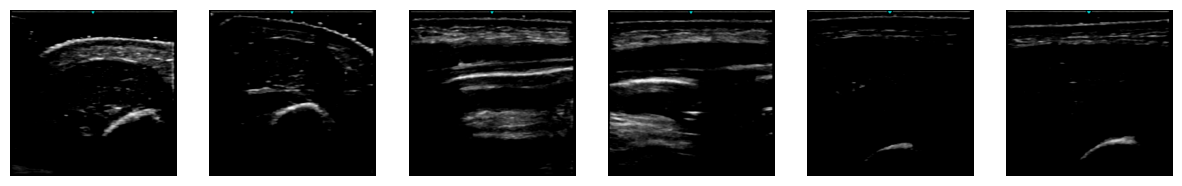

tensor([0.0808], dtype=torch.float64)
tensor([1.7546], dtype=torch.float64)
tensor([41.1000], dtype=torch.float64)


In [ ]:
tx_X = transforms.Compose([transforms.Resize((256, 256)),
                           transforms.ToTensor(),
                           transforms.Normalize(normalization_factors, normalization_factors)])
REGION = "ABQ" #B, A, Q, BA,BQ, AQ, BAQ
OUTPUT = "FM" #FFM
AUGMENT = 0 #0, 5, 8, 15
SPECKLE = False #Medianfilter
dataset = PatientDataset(transform = tx_X,
                 augmented_dataset = False,
                 augment = AUGMENT,
                 threshold = False,
                 speckle = SPECKLE,
                 despeckle = False,
                 region_combination = REGION,
                 number_of_image = 2, #1, 2, 3
                 crop = [1, 1, 1], #
                 output = OUTPUT)

## Only if we are augmenting the entire dataset rather than individual image
# augmented_dataset = AugmentedPatientDataset(dataset, transform = tx_X)
# train_size = int(0.8 * len(augmented_dataset))
# test_size = len(augmented_dataset) - train_size
# train_dataset, test_dataset = random_split(augmented_dataset, [train_size, test_size])

train_size = int(0.9 * len(dataset))  # 80% for training
test_size = len(dataset) - train_size  # Remaining 20% for testing
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)
print(len(train_loader))
print(len(test_loader))# Show if we load the image successfully
for i in range(1):
  first_batch = next(iter(train_loader))
  first_batch_images = first_batch[0]
  first_batch_label = first_batch[1]
  first_batch_W = first_batch[2]
  first_batch_L = first_batch[3]
  fig, axs = plt.subplots(1, len(first_batch_images), figsize=(15, 5))
  for i in range(len(first_batch_images)):
      img = im_converterX(first_batch_images[i][0])
      axs[i].imshow(img)
      axs[i].axis('off')
  plt.show()
  print(first_batch_label)
  print(first_batch_W)
  print(first_batch_L)

# Training

In [ ]:
CRITERION = "MSE" # other options include MAE, MAPE, MSE, Custom
WL = False # Weight+Length
EPOCHS = 90
LR = 0.001 #0.001 for unet, 0.0005 for attUNet
ADAPTIVE = True
train_history, validation_history = training(EPOCHS, CRITERION, LR, model, MODEL, ADAPTIVE, WL)

Epoch:  1 Batch:  0 Current Loss:  0.35143858194351196
Epoch:  1 Batch:  5 Current Loss:  0.5017290115356445
Epoch:  1 Batch:  10 Current Loss:  0.41518232226371765
Epoch:  1 Batch:  15 Current Loss:  0.3059079647064209
Epoch:  1 Batch:  20 Current Loss:  0.2872633635997772
Epoch:  1 Batch:  25 Current Loss:  0.21673107147216797
Epoch:  1 Batch:  30 Current Loss:  0.35326263308525085
Epoch:  1 Batch:  35 Current Loss:  0.3304314613342285
Epoch:  1 Batch:  40 Current Loss:  0.26619458198547363
Epoch:  1 Batch:  45 Current Loss:  0.16062408685684204
Epoch:  1 Batch:  50 Current Loss:  0.20232334733009338
Epoch 1 completed
Average train loss is 0.3442140407860279: 
Average validation loss is 0.2683577388525009
Epoch:  2 Batch:  0 Current Loss:  0.13051871955394745
Epoch:  2 Batch:  5 Current Loss:  0.32358652353286743
Epoch:  2 Batch:  10 Current Loss:  0.19084729254245758
Epoch:  2 Batch:  15 Current Loss:  0.13124948740005493
Epoch:  2 Batch:  20 Current Loss:  0.21998822689056396
Epoch

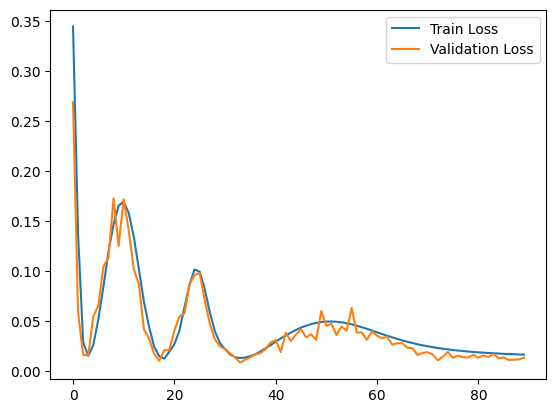

In [ ]:
plt.plot(train_history, label = 'Train Loss')
plt.plot(validation_history, label = 'Validation Loss')
plt.legend()

# Save a model

In [ ]:
model_folder = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/saved_models/'
number_of_images = '3'
name = os.path.join(model_folder, MODEL+"_"+CRITERION+"_"+str(LR)+"_Adaptive-"+str(ADAPTIVE)+"_"+str(AUGMENT)+"x_"+REGION+"_"+number_of_images+"_"+OUTPUT+"_"+str(90)+"epochs_WL-"+str(WL)+"_"+str(date.today())+".pt")
print(name)
torch.save(model, name)

/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/saved_models/UNet_MSE_0.001_Adaptive-True_0x_BQA_3_FM_90epochs_WL-False_2024-07-03.pt


# Load a model

In [ ]:
LOAD_MODEL = "UNet" # "EffNet_FT", "EffNet_LP"，"ResNet18_FT", "ResNet18_LP"，"UNet"， "AttUNet" "UNet++"
LOAD_CRITERION = "MSE" # "MAE", "MAPE"
LOAD_LR = 0.001
LOAD_ADAPTIVE = True
LOAD_REGION = "BAQ" # "BAQ", "BA", "BQ", "AQ", "B“, "A", "Q"
LOAD_AUGMENT = 0
LOAD_OUTPUT = "FM" # "FM", "FFM"
LOAD_EPOCHS = 90
LOAD_WL = False
LOAD_date = '2024-07-03'

model_folder = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/saved_models/'
model_name = os.path.join(model_folder, LOAD_MODEL+"_"+LOAD_CRITERION+"_"+str(LOAD_LR)+"_Adaptive-"+str(LOAD_ADAPTIVE)+"_"+str(LOAD_AUGMENT)+"x_"+LOAD_REGION+"_"+LOAD_OUTPUT+"_"+str(LOAD_EPOCHS)+"epochs_WL-"+str(LOAD_WL)+"_"+LOAD_date+".pt")
print(model_name)
model = torch.load(model_name)
model.to('cuda')
model.eval()

/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/saved_models/UNet_MSE_0.001_Adaptive-True_0x_BAQ_FM_90epochs_WL-False_2024-07-03.pt


<ipython-input-47-348b0a162e08>:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_name)


UNet(
  (inc): inconv(
    (conv): double_conv(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.1, inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): LeakyReLU(negative_slope=0.1, inplace=True)
      )
    )
  )
  (down1): down(
    (mpconv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): double_conv(
        (conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): LeakyReLU(negative_slope=0.1, inplace=True)
          (3): Conv2d(128, 128, k

# Grad-CAM: See Test Performance

In [ ]:
# Grad-CAM testing
normalization_factors = 0.5
tx_X = transforms.Compose([transforms.Resize((256, 256)),
                           transforms.ToTensor(),
                           transforms.Normalize(normalization_factors, normalization_factors)])
REGION = "A"
OUTPUT = "FM"
test_dataset = TestPatientDataset(transform = tx_X,
                 augmented_dataset = False,
                 augment = 0,
                 threshold = False,
                 speckle = True,
                 despeckle = False,
                 region_combination = REGION,
                 number_of_image = 2,
                 crop = [1, 1, 1],
                 output = OUTPUT)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
print(len(test_loader))

true_labels = []
predictions = []
WL = False

model.eval()  # Set the model to evaluation mode

with torch.no_grad():
    for ith_batch, batch in enumerate(test_loader):
        # Convert the list of images to a single tensor and move to GPU
        # Check if batch[0] is a list of tensors and stack them correctly
        if isinstance(batch[0], list):
            X_train = torch.stack(batch[0]).to('cuda')
        else:
            X_train = batch[0].to('cuda')

        y_train = batch[1].to('cuda').float()  # Move the batch of labels to GPU and convert to float

        # Ensure X_train has the correct shape: [batch_size, channels, height, width]
        if X_train.dim() == 5:
            # If the tensor has an extra dimension, remove it
            X_train = X_train.view(-1, *X_train.shape[2:])

        if WL:
            if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
                additional_data_train = torch.tensor([[batch[2].item(), batch[3].item()]]).to('cuda').float()
                y_pred = model(X_train, additional_data_train)
            elif MODEL == "UNet":
                weight = batch[2].to('cuda').float()
                length = batch[3].to('cuda').float()
                y_pred = model(X_train, weight, length)
        else:
            y_pred = model(X_train)

        # Append true labels and predictions
        true_labels.append(y_train)
        predictions.append(y_pred)

# Convert lists to tensors
true_labels = torch.cat(true_labels)
predictions = torch.cat(predictions)

# If necessary, move predictions and labels back to CPU
true_labels = true_labels.cpu().numpy()
predictions = predictions.cpu().numpy()

mae = np.mean(np.abs(predictions - true_labels))
mse = np.mean((predictions - true_labels) ** 2)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((true_labels - predictions) / true_labels)) * 100

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")

print("\nFirst five true labels and predictions:")
for i in range(min(5, len(true_labels))):
    print(f"True label: {true_labels[i]}, Prediction: {predictions[i]}")

7


RuntimeError: zero-dimensional tensor (at position 0) cannot be concatenated

Do THIS for EffNet compatibility

In [ ]:
# Grad-CAM testing
normalization_factors = 0.5
tx_X = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(normalization_factors, normalization_factors)
])

REGION = "A"
OUTPUT = "FM"

test_dataset = TestPatientDataset(
    transform=tx_X,
    augmented_dataset=False,
    augment=0,
    threshold=False,
    speckle=True,
    despeckle=False,
    region_combination=REGION,
    number_of_image=2,
    crop=[1, 1, 1],
    output=OUTPUT
)

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
print(len(test_loader))

true_labels = []
predictions = []
WL = False

model.eval()  # Set the model to evaluation mode

with torch.no_grad():
    for ith_batch, batch in enumerate(test_loader):
        # Prepare input images
        if isinstance(batch[0], list):
            X_train = torch.stack(batch[0]).to('cuda')
        else:
            X_train = batch[0].to('cuda')

        # Reshape to [N, C, H, W]
        if X_train.dim() == 5:
            X_train = X_train.view(-1, *X_train.shape[2:])  # remove batch nesting

        # Prepare label
        y_train = batch[1].to('cuda').float()
        if y_train.dim() == 0:
            y_train = y_train.view(1)

        # Model prediction
        if WL:
            if MODEL in ["EffNet_LP", "EffNet_FT"]:
                weight = batch[2].to('cuda').float().view(1)
                length = batch[3].to('cuda').float().view(1)
                y_pred = model(X_train, weight, length)
            elif MODEL == "UNet":
                weight = batch[2].to('cuda').float()
                length = batch[3].to('cuda').float()
                y_pred = model(X_train, weight, length)
        else:
            y_pred = model(X_train)

        if y_pred.dim() == 0:
            y_pred = y_pred.view(1)

        # Append predictions and true labels with consistent shapes
        true_labels.append(y_train.view(1))
        predictions.append(y_pred.view(1))

# Convert to tensors
true_labels = torch.cat(true_labels)
predictions = torch.cat(predictions)

# Move to CPU and evaluate
true_labels = true_labels.cpu().numpy()
predictions = predictions.cpu().numpy()

mae = np.mean(np.abs(predictions - true_labels))
mse = np.mean((predictions - true_labels) ** 2)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((true_labels - predictions) / true_labels)) * 100

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAPE: {mape}")

print("\nFirst five true labels and predictions:")
for i in range(min(5, len(true_labels))):
    print(f"True label: {true_labels[i]}, Prediction: {predictions[i]}")


7
MAE: 1.3604127168655396
MSE: 1.8980042934417725
RMSE: 1.377680778503418
MAPE: 820.5110473632812

First five true labels and predictions:
True label: 0.18799999356269836, Prediction: -1.1635665893554688
True label: 0.11249999701976776, Prediction: -1.0066243410110474
True label: 0.15880000591278076, Prediction: -0.9200335741043091
True label: 0.1216999962925911, Prediction: -1.3397326469421387
True label: 0.22089999914169312, Prediction: -1.0214195251464844


In [ ]:
true_labels = []
prediction = []
WL = False
for ith_batch, batch in enumerate(test_loader):
  X_train = [image.to('cuda') for image in batch[0]]
  y_train = batch[1].to('cuda').float()[0]
  if WL:
    if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
      additional_data_train = torch.tensor([[batch[2].item(), batch[3].item()]]).to('cuda').float()
      y_pred = model(X_train, additional_data_train)
    if MODEL == "UNet":
      weight = batch[2].to('cuda').float()[0]
      length = batch[3].to('cuda').float()[0]
      y_pred = model(X_train, weight, length)
  else:
    y_pred = model(X_train)[0]
  true_labels.append(y_train)
  prediction.append(y_pred)

TypeError: conv2d() received an invalid combination of arguments - got (list, Parameter, Parameter, tuple, tuple, tuple, int), but expected one of:
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, tuple of ints padding = 0, tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!list of [Tensor, Tensor]!, !Parameter!, !Parameter!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, !int!)
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, str padding = "valid", tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!list of [Tensor, Tensor]!, !Parameter!, !Parameter!, !tuple of (int, int)!, !tuple of (int, int)!, !tuple of (int, int)!, !int!)


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(GT_FM, label=f'Line A - Ground Truth', marker='o')
plt.plot(Pred_FM, label=f'Line B - Prediction', marker='o')
plt.xlabel('Patient ID')
plt.ylabel('FM value')
plt.legend()
plt.title('FM - Ground Truth vs Prediction')
plt.grid(True)
plt.show()

In [ ]:
y_true = torch.tensor(GT_FM)
y_pred = torch.tensor(Pred_FM)

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print("MAE:", mae.item())
print("MSE:", mse.item())
print("RMSE:", rmse)
print("MAPE:", mape.item())

# See Test Performance


In [ ]:
normalization_factors = 0.5
tx_X = transforms.Compose([transforms.Resize((256, 256)),
                           transforms.ToTensor(),
                           transforms.Normalize(normalization_factors, normalization_factors)])
REGION = "BAQ"
OUTPUT = "FM"
test_dataset = TestPatientDataset(transform = tx_X,
                 augmented_dataset = False,
                 augment = 0,
                 threshold = False,
                 speckle = True,
                 despeckle = False,
                 region_combination = REGION,
                 number_of_image = 2,
                 crop = [1, 1, 1],
                 output = OUTPUT)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
print(len(test_loader))

7


In [ ]:
model = model.to('cuda')
model.eval()

EfficientNetB1Model(
  (efficientnet): EfficientNet(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_project_conv): Conv2dStat

In [ ]:
true_labels = []
prediction = []
WL = False
for ith_batch, batch in enumerate(test_loader):
  X_train = [image.to('cuda') for image in batch[0]]
  y_train = batch[1].to('cuda').float()[0]
  if WL:
    if MODEL == "EffNet_LP" or MODEL == "EffNet_FT":
      additional_data_train = torch.tensor([[batch[2].item(), batch[3].item()]]).to('cuda').float()
      y_pred = model(X_train, additional_data_train)
    if MODEL == "UNet":
      weight = batch[2].to('cuda').float()[0]
      length = batch[3].to('cuda').float()[0]
      y_pred = model(X_train, weight, length)
  else:
    y_pred = model(X_train) #get rid of [0] for EffNet
  true_labels.append(y_train)
  prediction.append(y_pred)

In [ ]:
GT_FM = []
Pred_FM = []
for i in range(len(true_labels)):
  gt = torch.Tensor.tolist(true_labels[i])
  GT_FM.append(gt)
  pred = torch.Tensor.tolist(prediction[i])
  Pred_FM.append(pred)
print(GT_FM)
print(Pred_FM)

[0.18799999356269836, 0.11249999701976776, 0.15880000591278076, 0.1216999962925911, 0.22089999914169312, 0.2667999863624573, 0.1712999939918518]
[[0.22213232517242432], [0.25823235511779785], [0.2694837749004364], [0.30109062790870667], [0.2134687304496765], [0.20916619896888733], [0.2552543580532074]]


print for paper

In [ ]:
# print for paper
import torch

# Patients identifiers
patients = test_data

# Flatten Pred_FM
flattened_pred_fm = [pred[0][0] if isinstance(pred, list) and isinstance(pred[0], list) else pred[0] for pred in Pred_FM]

# Compute residuals
residuals = [abs(gt - pred) for gt, pred in zip(GT_FM, flattened_pred_fm)]

# Combine patients with their residuals and sort
sorted_residuals = sorted(zip(patients, residuals), key=lambda x: x[1])

# Print sorted residuals
for patient, residual in sorted_residuals:
    print(f"Patient {patient}: Residual = {residual}")


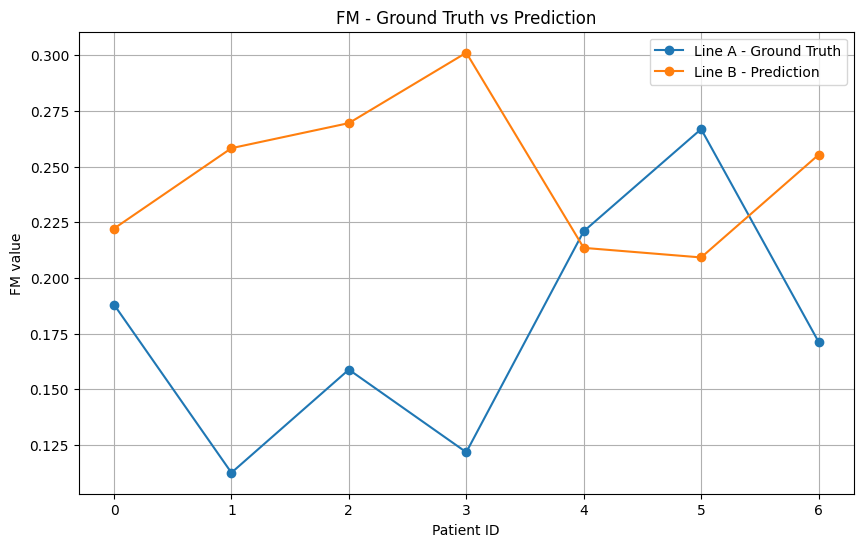

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(GT_FM, label=f'Line A - Ground Truth', marker='o')
plt.plot(Pred_FM, label=f'Line B - Prediction', marker='o')
plt.xlabel('Patient ID')
plt.ylabel('FM value')
plt.legend()
plt.title('FM - Ground Truth vs Prediction')
plt.grid(True)
plt.show()

In [ ]:
y_true = torch.tensor(GT_FM)
y_pred = torch.tensor(Pred_FM)

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print("MAE:", mae.item())
print("MSE:", mse.item())
print("RMSE:", rmse)
print("MAPE:", mape.item())

MAE: 0.07778818160295486
MSE: 0.00837572943419218
RMSE: 0.09151901132656635
MAPE: 54.174007415771484


# Modified Ground Truth vs. Predictions Plot

[0.18799999356269836, 0.11249999701976776, 0.15880000591278076, 0.1216999962925911, 0.22089999914169312, 0.2667999863624573, 0.1712999939918518]
[0.11048782616853714, 0.10940609127283096, 0.14138397574424744, 0.12432828545570374, 0.23083579540252686, 0.17324534058570862, 0.21304816007614136]


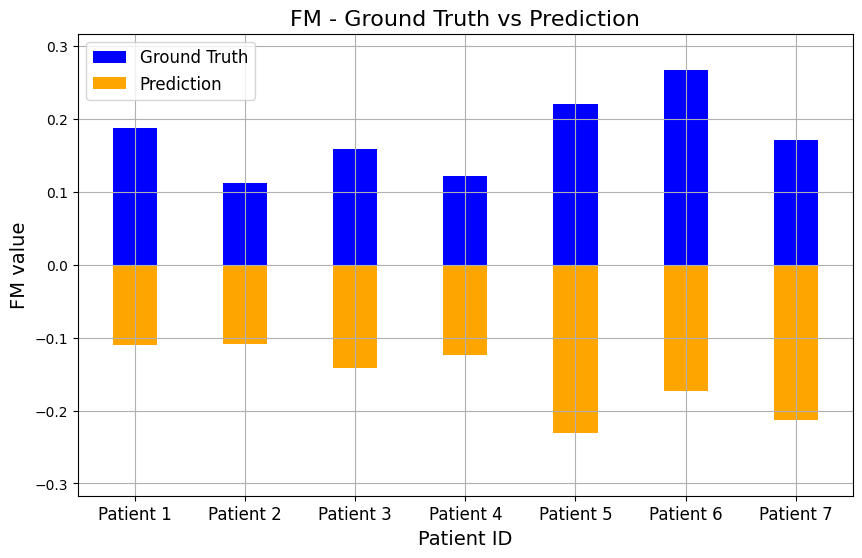

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Example data
true_labels = [torch.tensor([0.18799999356269836]), torch.tensor([0.11249999701976776]), torch.tensor([0.15880000591278076]), torch.tensor([0.1216999962925911]), torch.tensor([0.22089999914169312]), torch.tensor([0.2667999863624573]), torch.tensor([0.1712999939918518])]
prediction = [torch.tensor([0.11048782616853714]), torch.tensor([0.10940609127283096]), torch.tensor([0.14138397574424744]), torch.tensor([0.12432828545570374]), torch.tensor([0.23083579540252686]), torch.tensor([0.17324534058570862]), torch.tensor([0.21304816007614136])]

# Lists to hold Ground Truth and Predictions
GT_FM = []
Pred_FM = []

# Converting tensor data to lists and appending to respective lists
for i in range(len(true_labels)):
    gt = torch.Tensor.tolist(true_labels[i])
    pred = torch.Tensor.tolist(prediction[i])
    GT_FM.append(gt[0])
    Pred_FM.append(pred[0])

# Displaying the Ground Truth and Prediction values
print(GT_FM)
print(Pred_FM)

# Creating the bar chart
plt.figure(figsize=(10, 6))

# Define the position for the bars
x = np.arange(len(GT_FM))

# Plotting the Ground Truth as bars above the line
plt.bar(x, GT_FM, width=0.4, label='Ground Truth', color='blue', align='center')

# Plotting the Predicted values as bars below the line (negative values)
plt.bar(x, [-val for val in Pred_FM], width=0.4, label='Prediction', color='orange', align='center')

# Adjusting axis labels and title font size
plt.xlabel('Patient ID', fontsize=14)
plt.ylabel('FM value', fontsize=14)
plt.title('FM - Ground Truth vs Prediction', fontsize=16)

# Customizing x-axis tick labels
plt.xticks(x, [f'Patient {i+1}' for i in range(len(GT_FM))], fontsize=12)

# Adding a legend
plt.legend(fontsize=12)

# Enlarging the y-axis scale to bring the bars closer together visually
plt.ylim(-max(GT_FM) - 0.05, max(GT_FM) + 0.05)

plt.grid(True)
plt.show()


# More analysis

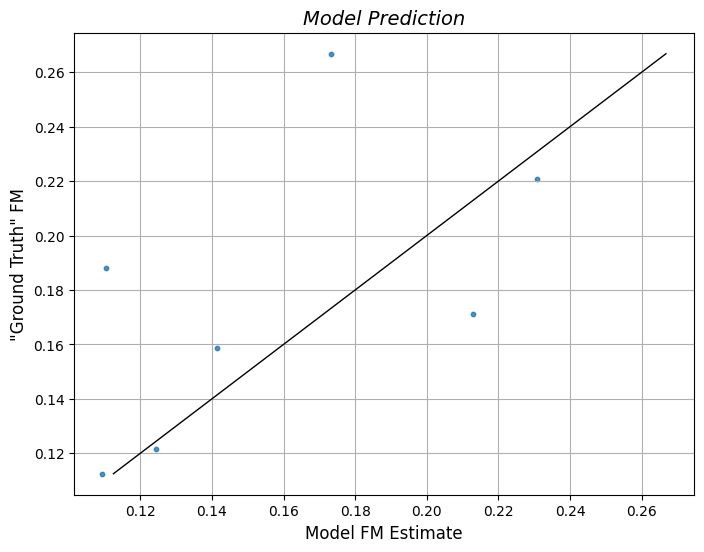

In [ ]:
# Example data
ground_truth = GT_FM
prediction = Pred_FM

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(prediction, ground_truth, s=10, alpha=0.8)
plt.plot([min(ground_truth), max(ground_truth)], [min(ground_truth), max(ground_truth)], color='black', linewidth=1)

# Add labels and title
plt.xlabel('Model FM Estimate')
plt.ylabel('"Ground Truth" FM')
plt.title('Model Prediction')
plt.grid(True)

# Adjust font and formatting
plt.title('Model Prediction', fontsize=14, style='italic')
plt.xlabel('Model FM Estimate', fontsize=12)
plt.ylabel('"Ground Truth" FM', fontsize=12)

# Show plot
plt.show()

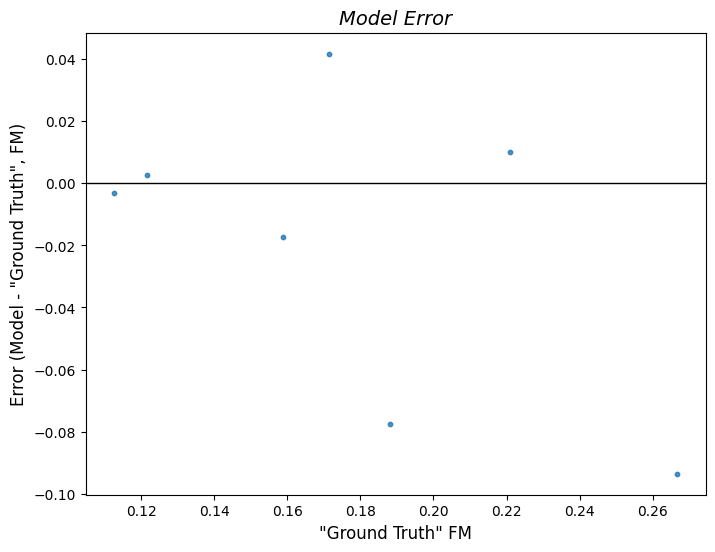

In [ ]:
ground_truth = GT_FM
prediction = Pred_FM

# Calculate error
error = difference = [a - b for a, b in zip(prediction, ground_truth)]

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(ground_truth, error, s=10, alpha=0.8)
plt.axhline(y=0, color='black', linewidth=1)

# Add labels and title
plt.xlabel('"Ground Truth" FM')
plt.ylabel('Error (Model - "Ground Truth", FM)')
plt.title('Model Error')

# Adjust font and formatting
plt.title('Model Error', fontsize=14, style='italic')
plt.xlabel('"Ground Truth" FM', fontsize=12)
plt.ylabel('Error (Model - "Ground Truth", FM)', fontsize=12)

# Show plot
plt.show()

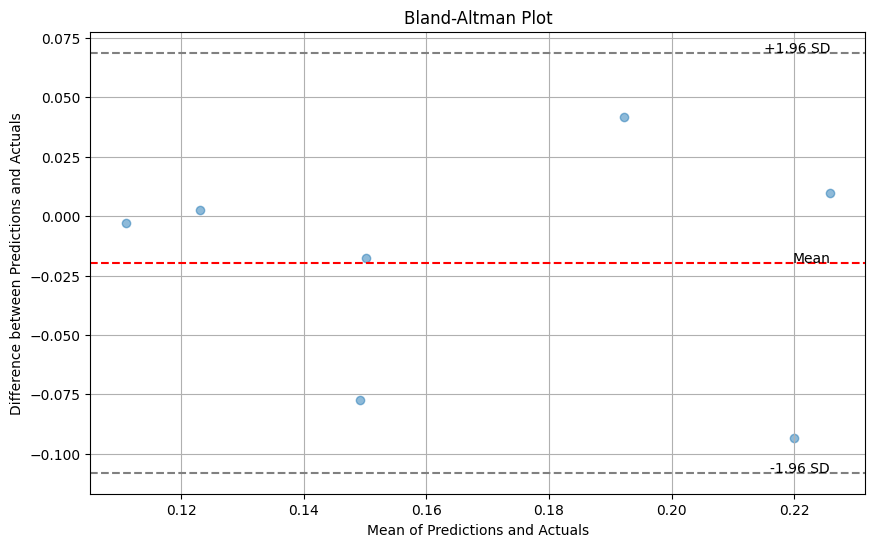

In [ ]:
def bland_altman_plot(actuals, predictions):
    differences = predictions - actuals  # Calculate the differences
    means = (predictions + actuals) / 2  # Calculate the means

    mean_difference = np.mean(differences)
    sd_difference = np.std(differences)

    plt.figure(figsize=(10, 6))
    plt.scatter(means, differences, alpha=0.5)
    plt.axhline(mean_difference, color='red', linestyle='--')
    plt.axhline(mean_difference + 1.96 * sd_difference, color='gray', linestyle='--')
    plt.axhline(mean_difference - 1.96 * sd_difference, color='gray', linestyle='--')

    plt.text(np.max(means), mean_difference, 'Mean', horizontalalignment='right')
    plt.text(np.max(means), mean_difference + 1.96 * sd_difference, '+1.96 SD', horizontalalignment='right')
    plt.text(np.max(means), mean_difference - 1.96 * sd_difference, '-1.96 SD', horizontalalignment='right')

    plt.title('Bland-Altman Plot')
    plt.xlabel('Mean of Predictions and Actuals')
    plt.ylabel('Difference between Predictions and Actuals')
    plt.grid(True)
    plt.show()

actuals = np.array(GT_FM)
predictions = np.array(Pred_FM)
bland_altman_plot(actuals, predictions)

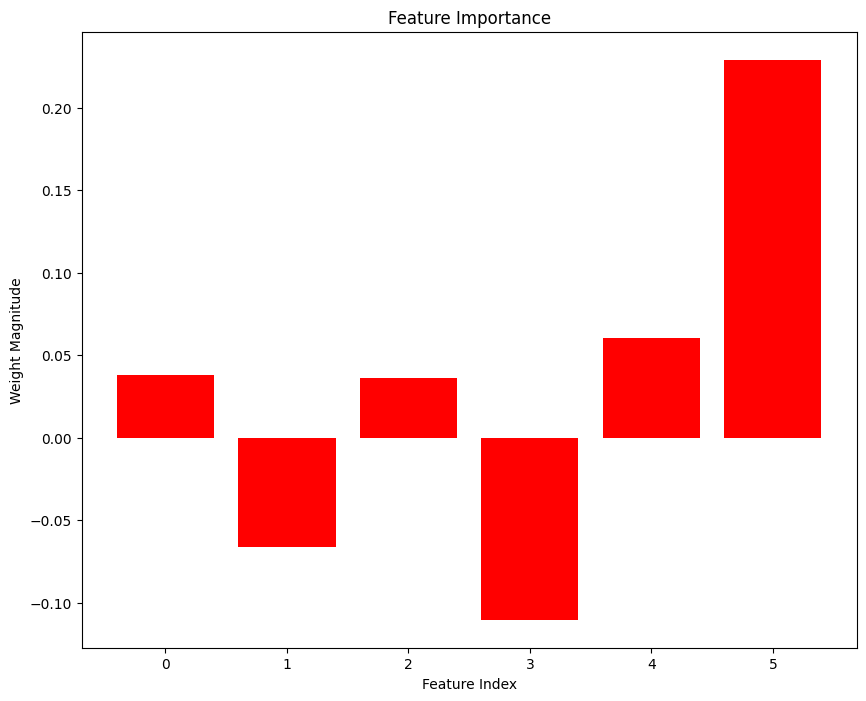

In [ ]:
def visualize_linear_layer_weights(linear_layer):
    weights = linear_layer.weight.data.cpu().numpy().squeeze()

    plt.figure(figsize=(10, 8))
    indices = np.arange(len(weights))
    plt.bar(indices, weights, color='red')
    plt.xlabel('Feature Index')
    plt.ylabel('Weight Magnitude')
    plt.title('Feature Importance')
    plt.show()

# Example usage after your model is trained:
visualize_linear_layer_weights(model.linear2)


In [ ]:
def visualize_image_weights(linear_layer):
    weights = linear_layer.weight.data.cpu().numpy().squeeze()
    weights_image = weights.reshape(8, 8)  # Reshape to 256x256 for visualization

    plt.figure(figsize=(6, 6))
    plt.imshow(weights_image, cmap='Reds')
    plt.colorbar()
    plt.title('Pixel Importance')
    plt.axis('off')  # Hide axis for better visualization
    plt.show()

# Example usage after your model is trained:
print(UNet_A)
visualize_image_weights(UNet_A.outc.conv)


NameError: name 'UNet_A' is not defined

# GradCam

In [ ]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.forward_output = None
        target_layer.register_backward_hook(self.save_gradients)
        target_layer.register_forward_hook(self.save_forward_output)

    def save_gradients(self, module, input_grad, output_grad):
        self.gradients = output_grad[0]

    def save_forward_output(self, module, input, output):
        self.forward_output = output

    def __call__(self, x):
        print(self.model(x))
        print("Original input dimensions:", x.shape)
        if x.dim() == 3:
            x = x[None, ...]
            print("Processed by GradCAM:", x.shape)  # Verify dimensions after unsqueeze
        output = self.model(x)
        print("Output from model in GradCAM:", output.shape)
        self.model.zero_grad()
        output.backward(retain_graph=True)

        gradients = self.gradients.cpu().data.numpy()
        forward_output = self.forward_output.cpu().data.numpy()
        print("Gradients shape:", gradients.shape)
        print("Forward output shape:", forward_output.shape)

        weights = np.mean(gradients, axis=(2, 3))  # Average over the spatial dimensions
        print("Weights shape:", weights.shape)

        grad_cam = np.zeros(forward_output.shape[2:], dtype=np.float32)
        for i, w in enumerate(weights):
            grad_cam += w * forward_output[0, i, :, :]  # Ensure correct indexing

        grad_cam = np.maximum(grad_cam, 0)
        grad_cam = cv2.resize(grad_cam, (x.shape[3], x.shape[2]))  # Ensure dimensions match the input
        grad_cam = (grad_cam - np.min(grad_cam)) / (np.max(grad_cam) - np.min(grad_cam))
        return grad_cam

def load_image(img_path):
    img = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Example normalization factors
    ])
    img = transform(img).unsqueeze(0).to('cuda')
    return img

def apply_grad_cam(img_path, model, target_layer):
    img = load_image(img_path)
    print("Tensor dimensions before GradCAM:", img.shape)  # Confirm dimensions here

    grad_cam = GradCAM(model, target_layer)
    heatmap = grad_cam(img)  # Pass the tensor here

    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    img = cv2.imread(img_path)
    img = np.float32(cv2.resize(img, (256, 256)))
    overlaid_img = heatmap * 0.8 + img
    overlaid_img = overlaid_img / np.max(overlaid_img)
    plt.figure(figsize=(6, 6))
    plt.imshow(overlaid_img)
    plt.axis('off')
    plt.show()


In [ ]:
model.eval()

# patients = df['Study_ID'].tolist()
chosen_patients = [58041919, 5120817, 19052118, 25061918, 26061918, 54020819]
body_part = '_BICEP1_R' # _AB1_R, _BICEP1_R, _QUAD1_R
for patient in chosen_patients:

  patient_id = str(patient)
  print(f'Patient ID: {patient_id}')

  grad_cam_img_path = f'/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images/{patient_id}/{patient_id}{body_part}.jpg'
  target_layer = model.Up_conv2
  #target_layer = model.up4.conv.conv[-3]
  apply_grad_cam(grad_cam_img_path, model, target_layer)

  # Load and display the image
  image = cv2.imread(grad_cam_img_path)
  image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

  # Plot the image
  plt.figure(figsize=(8, 8))
  plt.imshow(image)
  plt.title(f'Image for Patient ID: {patient_id}')
  plt.axis('off')
  plt.show()

Patient ID: 58041919
Tensor dimensions before GradCAM: torch.Size([1, 3, 256, 256])


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


tensor([[2.1875]], device='cuda:0', grad_fn=<AddmmBackward0>)
Original input dimensions: torch.Size([1, 3, 256, 256])
Output from model in GradCAM: torch.Size([1, 1])
Gradients shape: (1, 64, 256, 256)
Forward output shape: (1, 64, 256, 256)
Weights shape: (1, 64)


ValueError: operands could not be broadcast together with shapes (64,) (256,256) 

For AttUNet:

In [ ]:
import os
import numpy as np
import torch
import cv2
from PIL import Image
from torchvision import transforms

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.forward_output = None

        # Register hooks
        target_layer.register_forward_hook(self.save_forward_output)
        target_layer.register_full_backward_hook(self.save_gradients)

    def save_forward_output(self, module, input, output):
        self.forward_output = output
        print("Forward output captured:", output.shape)

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]
        print("Gradients captured:", self.gradients.shape)

    def __call__(self, x):
        print("Input tensor dimensions:", x.shape)
        if x.dim() == 3:  # Add batch dimension if missing
            x = x.unsqueeze(0)

        # Forward pass
        output = self.model(x)
        print("Model output shape:", output.shape)

        # Backward pass
        self.model.zero_grad()
        if output.numel() == 1:  # Single scalar output
            output.backward(torch.ones_like(output))
        else:  # Assume classification
            target_class = torch.argmax(output, dim=1).item()
            print("Target class:", target_class)
            output[0, target_class].backward(retain_graph=True)

        # Ensure gradients and activations are captured
        assert self.gradients is not None, "Gradients not captured."
        assert self.forward_output is not None, "Forward output not captured."

        gradients = self.gradients.detach().cpu().numpy()
        forward_output = self.forward_output.detach().cpu().numpy()

        # Debugging: Print stats
        print("Gradients min/max/mean:", gradients.min(), gradients.max(), gradients.mean())
        print("Forward output min/max/mean:", forward_output.min(), forward_output.max(), forward_output.mean())

        # Compute weights and Grad-CAM
        weights = np.mean(gradients, axis=(2, 3), keepdims=True)
        print("Computed weights shape:", weights.shape)

        grad_cam = np.sum(weights * forward_output, axis=1).squeeze(0)
        grad_cam = np.maximum(grad_cam, 0)  # ReLU
        grad_cam = cv2.resize(grad_cam, (x.shape[3], x.shape[2]))
        grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-8)
        print("Grad-CAM heatmap min/max:", grad_cam.min(), grad_cam.max())

        return grad_cam


# Main code
model.eval()
chosen_patients = [58041919, 5120817, 19052118, 25061918, 26061918, 54020819]
body_part = '_BICEP1_R'
base_dir = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration'
save_dir = os.path.join(base_dir, "FFM_Att5")  # FFM_Att5 folder

for patient in chosen_patients:
    patient_id = str(patient)
    print(f'Processing Patient ID: {patient_id}')

    # Path to the input image
    img_path = os.path.join(base_dir, "cropped_images", patient_id, f"{patient_id}{body_part}.jpg")
    target_layer = model.Att5  # Specify the target layer

    # Apply Grad-CAM and save images
    apply_grad_cam_and_save(img_path, model, target_layer, save_dir, patient_id)


Processing Patient ID: 58041919


NameError: name 'apply_grad_cam_and_save' is not defined

Patient ID: 58041919
Tensor dimensions before GradCAM: torch.Size([1, 3, 256, 256])
Input tensor dimensions: torch.Size([1, 3, 256, 256])
Forward output captured: torch.Size([1, 1, 256, 256])
Model output: tensor([[2.1875]], device='cuda:0', grad_fn=<AddmmBackward0>)
Target class: tensor([0], device='cuda:0')
Gradients captured: torch.Size([1, 1, 256, 256])


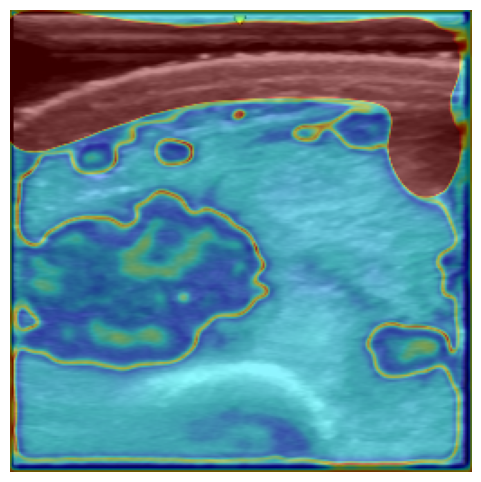

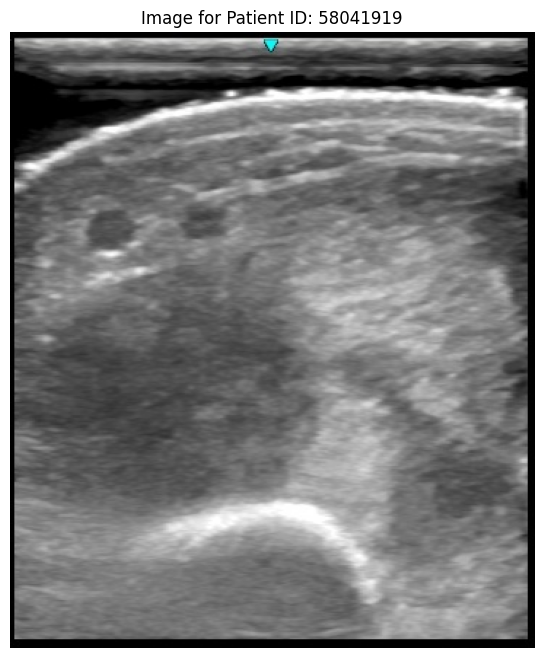

Patient ID: 5120817
Tensor dimensions before GradCAM: torch.Size([1, 3, 256, 256])
Input tensor dimensions: torch.Size([1, 3, 256, 256])
Forward output captured: torch.Size([1, 1, 256, 256])
Model output: tensor([[-0.2140]], device='cuda:0', grad_fn=<AddmmBackward0>)
Target class: tensor([0], device='cuda:0')
Gradients captured: torch.Size([1, 1, 256, 256])


AssertionError: Gradients not captured.

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import cv2
from PIL import Image
from torchvision import transforms, models
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.forward_output = None

        # Ensure hooks are registered only once
        if not hasattr(target_layer, "_hooks_registered"):
            target_layer.register_forward_hook(self.save_forward_output)
            setattr(target_layer, "_hooks_registered", True)

    def save_forward_output(self, module, input, output):
        self.forward_output = output
        print("Forward output captured:", output.shape)
        output.register_hook(self.save_gradients)

    def save_gradients(self, grad):
        self.gradients = grad
        print("Gradients captured:", grad.shape)

    def __call__(self, x):
        print("Input tensor dimensions:", x.shape)
        if x.dim() == 3:
            x = x.unsqueeze(0)

        # Forward pass
        output = self.model(x)
        print("Model output:", output)

        # Backward pass
        self.model.zero_grad()
        target_class = torch.argmax(output, dim=1) if output.dim() > 1 else 0
        print("Target class:", target_class)
        output.backward(torch.ones_like(output))  # Adjust for regression

        # Ensure gradients and activations are captured
        assert self.gradients is not None, "Gradients not captured."
        assert self.forward_output is not None, "Forward output not captured."

        # Compute Grad-CAM
        gradients = self.gradients.detach().cpu().numpy()
        forward_output = self.forward_output.detach().cpu().numpy()
        weights = np.mean(gradients, axis=(2, 3), keepdims=True)
        grad_cam = np.sum(weights * forward_output, axis=1).squeeze(0)
        grad_cam = np.maximum(grad_cam, 0)
        grad_cam = cv2.resize(grad_cam, (x.shape[3], x.shape[2]))
        grad_cam = (grad_cam - np.min(grad_cam)) / (np.max(grad_cam) - np.min(grad_cam) + 1e-8)
        return grad_cam



# Load an image and preprocess it
def load_image(img_path):
    img = Image.open(img_path).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Adjust normalization as needed
    ])
    img = transform(img).unsqueeze(0).to('cuda')
    return img

# Apply Grad-CAM and overlay the heatmap
def apply_grad_cam(img_path, model, target_layer):
    img = load_image(img_path)
    print("Tensor dimensions before GradCAM:", img.shape)

    grad_cam = GradCAM(model, target_layer)
    heatmap = grad_cam(img)

    # Apply heatmap
    heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    img = cv2.imread(img_path)
    img = np.float32(cv2.resize(img, (256, 256)))
    overlaid_img = heatmap * 0.8 + img
    overlaid_img = overlaid_img / np.max(overlaid_img)

    plt.figure(figsize=(6, 6))
    plt.imshow(overlaid_img)
    plt.axis('off')
    plt.show()

# Evaluate model and apply Grad-CAM
model.eval()
chosen_patients = [58041919, 5120817, 19052118, 25061918, 26061918, 54020819]
body_part = '_BICEP1_R'

for patient in chosen_patients:
    patient_id = str(patient)
    print(f'Patient ID: {patient_id}')

    grad_cam_img_path = f'/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images/{patient_id}/{patient_id}{body_part}.jpg'
    target_layer = model.Conv_1x1 # model.Up_conv2  # Specify the target layer
    apply_grad_cam(grad_cam_img_path, model, target_layer)

    # Load and display the original image
    image = cv2.imread(grad_cam_img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.title(f'Image for Patient ID: {patient_id}')
    plt.axis('off')
    plt.show()

In [ ]:
grad_cam_img_path = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images/58041919/58041919_AB1_R.jpg'
target_layer = UNet.outc.conv
UNet_drop = UNet
apply_grad_cam(grad_cam_img_path, UNet, target_layer)


AttributeError: type object 'UNet' has no attribute 'outc'

In [ ]:
grad_cam_img_path = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images/58041919/58041919_BICEP1_R.jpg'
target_layer = model.resnet.layer4[2].conv3
apply_grad_cam(grad_cam_img_path, model, target_layer)

IndexError: index 2 is out of range

In [ ]:
grad_cam_img_path = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images/58041919/58041919_QUAD1_R.jpg'
target_layer = model.resnet.layer4[2].conv3
apply_grad_cam(grad_cam_img_path, model, target_layer)

In [ ]:
print(model.regression)

In [ ]:
model_folder = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/saved_models/MICCAI_models/'
model = torch.load(os.path.join(model_folder, 'Resnet18_LP_MSE_0307_MICCAI_FM_40epochs_BAQ.pt'))
model.to('cuda')
model.eval()

# Grad-CAM 1/29 modification

In [ ]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Hook to get the gradients
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0]  # Save gradients

        # Hook to get the activations (feature maps)
        def forward_hook(module, input, output):
            self.activations = output  # Save feature maps

        # Register hooks
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate_cam(self, input_tensor, target_class=None):
        # Forward pass
        output = self.model(input_tensor)

        # If no target class is given, use the max logit index
        if target_class is None:
            target_class = output.argmax().item()

        # Compute gradients for the target class
        self.model.zero_grad()
        output[:, target_class].backward(retain_graph=True)

        # Compute Grad-CAM
        gradients = self.gradients  # Shape: (batch_size, channels, H, W)
        activations = self.activations  # Shape: (batch_size, channels, H, W)
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)  # Global average pooling
        cam = torch.sum(weights * activations, dim=1)  # Weighted sum of activations
        cam = F.relu(cam)  # Apply ReLU

        # Normalize the heatmap
        cam -= cam.min()
        cam /= cam.max()
        return cam.squeeze().cpu().detach().numpy()  # Convert to numpy for visualization


def apply_grad_cam(image_path, model, target_layer):
    """Apply Grad-CAM to an image given a model and target layer."""

    # Load and preprocess the image
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((256, 256)),  # Ensure input size matches the model
        transforms.ToTensor(),
    ])
    input_tensor = transform(image).unsqueeze(0).to(next(model.parameters()).device)

    # Initialize Grad-CAM
    grad_cam = GradCAM(model, target_layer)

    # Generate Grad-CAM heatmap
    cam = grad_cam.generate_cam(input_tensor)

    # Convert original image to numpy for overlay
    image_np = np.array(image)
    image_np = cv2.resize(image_np, (256, 256))

    # Resize Grad-CAM heatmap to match image
    heatmap = cv2.resize(cam, (image_np.shape[1], image_np.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    # Apply colormap
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay heatmap on the image
    overlay = cv2.addWeighted(image_np, 0.5, heatmap, 0.5, 0)

    # Save the Grad-CAM output
    output_path = image_path.replace(".jpg", "_gradcam.jpg")
    cv2.imwrite(output_path, overlay)

    # Display the result
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f'Grad-CAM for {image_path.split("/")[-1]}')
    plt.axis('off')
    plt.show()

THIS one works:

In [ ]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Hook to get the gradients
        def backward_hook(module, grad_input, grad_output):
            print("\n[DEBUG] Backward Hook Called:")
            print(f" - grad_output shape: {grad_output[0].shape}")
            print(f" - grad_output min/max: {grad_output[0].min().item()} / {grad_output[0].max().item()}")
            self.gradients = grad_output[0]  # Save gradients

        # Hook to get the activations (feature maps)
        def forward_hook(module, input, output):
            print("\n[DEBUG] Forward Hook Called:")
            print(f" - Activations shape: {output.shape}")
            print(f" - Activations min/max: {output.min().item()} / {output.max().item()}")
            self.activations = output  # Save feature maps

        # Register hooks
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate_cam(self, input_tensor, target_class=None):
        print("\n[DEBUG] Running forward pass...")
        output = self.model(input_tensor)

        if target_class is None:
            target_class = output.argmax().item()
        print(f"[DEBUG] Target class for Grad-CAM: {target_class}")

        self.model.zero_grad()
        output[:, target_class].backward(retain_graph=True)

        # Compute Grad-CAM
        gradients = self.gradients  # Shape: (batch_size, channels, H, W)
        activations = self.activations  # Shape: (batch_size, channels, H, W)

        print("\n[DEBUG] Checking gradients and activations:")
        print(f" - Gradients shape: {gradients.shape}")
        print(f" - Gradients min/max: {gradients.min().item()} / {gradients.max().item()}")
        print(f" - Activations shape: {activations.shape}")
        print(f" - Activations min/max: {activations.min().item()} / {activations.max().item()}")

        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)  # Global average pooling
        print(f" - Weights shape: {weights.shape}")

        cam = torch.sum(weights * activations, dim=1)  # Weighted sum of activations
        cam = F.relu(cam)  # Apply ReLU

        # Normalize the heatmap
        cam -= cam.min()
        cam /= cam.max()
        return cam.squeeze().cpu().detach().numpy()  # Convert to numpy for visualization


def apply_grad_cam(image_path, model, layer_name, target_layer):
    """Apply Grad-CAM to an image given a model and target layer."""

    # Load and preprocess the image
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((256, 256)),  # Ensure input size matches the model
        transforms.ToTensor(),
    ])
    input_tensor = transform(image).unsqueeze(0).to(next(model.parameters()).device)

    # Initialize Grad-CAM
    grad_cam = GradCAM(model, target_layer)

    # Generate Grad-CAM heatmap
    cam = grad_cam.generate_cam(input_tensor)

    # Convert original image to numpy for overlay
    image_np = np.array(image)
    image_np = cv2.resize(image_np, (256, 256))

    # Resize Grad-CAM heatmap to match image
    heatmap = cv2.resize(cam, (image_np.shape[1], image_np.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    # Apply colormap
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Overlay heatmap on the image
    overlay = cv2.addWeighted(image_np, 0.5, heatmap, 0.5, 0)

    # layer_name = target_layer.__class__.__name__  # Get class name of the layer
    # Save the Grad-CAM output
    output_dir = f'/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/Grad-CAM/EffNet_Finetune/{layer_name}/ABD'

    os.makedirs(output_dir, exist_ok=True)

    # Define the output filename
    image_filename = os.path.basename(image_path)  # Extract filename from path
    output_path = os.path.join(output_dir, f'Grad-CAM_{image_filename}')  # Append filename

    # Save the Grad-CAM output
    cv2.imwrite(output_path, overlay)

    # Display the result
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f'Grad-CAM for {image_path.split("/")[-1]}')
    plt.axis('off')
    plt.show()


In [ ]:
import gc  # Garbage collector
model.eval()  # Set model to evaluation mode

chosen_patients = [58041919, 5120817, 19052118, 25061918, 26061918, 54020819]
body_part = '_AB1_R'  # Options: _AB1_R, _BICEP1_R, _QUAD1_R

for patient in chosen_patients:
    patient_id = str(patient)
    print(f'Patient ID: {patient_id}')

    # Image path
    grad_cam_img_path = f'/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images_bluethingremoved/{patient_id}/{patient_id}{body_part}.jpg'

    layers = {
    'Att2': model.Att2, 'Att3': model.Att3, 'Att4': model.Att4, 'Att5': model.Att5,
    'Conv1': model.Conv1, 'Conv2': model.Conv2, #'Conv3': model.Conv3, 'Conv4': model.Conv4, 'Conv5': model.Conv5
}

    for layer_name, target_layer in layers.items():
        if target_layer is not None:  # Ensure the layer exists in the model
            print(f'Applying Grad-CAM on layer: {layer_name}')
            apply_grad_cam(grad_cam_img_path, model, layer_name, target_layer)
        else:
            print(f"Warning: Layer {layer_name} not found in the model. Skipping...")
    model.cpu()
    torch.cuda.empty_cache()  # Free up CUDA memory
    gc.collect()  # Garbage collection
    model.to('cuda')
    #target_layer = model.Att2 # Up_conv2  # Can also try model.Up4.conv.conv[-3] for different visualization

    # Apply Grad-CAM
    #apply_grad_cam(grad_cam_img_path, model, target_layer)

Patient ID: 58041919
Applying Grad-CAM on layer: model.efficientnet._blocks[-1]._depthwise_conv

[DEBUG] Running forward pass...

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 1920, 8, 8])
 - Activations min/max: -1.5957651138305664 / 4.078164100646973
[DEBUG] Target class for Grad-CAM: 0


IndexError: too many indices for tensor of dimension 0

EffNet

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image


class GradCAMHook:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.hook_handles.append(self.target_layer.register_forward_hook(forward_hook))
        self.hook_handles.append(self.target_layer.register_backward_hook(backward_hook))

    def remove_hooks(self):
        for handle in self.hook_handles:
            handle.remove()

    def generate_cam(self, input_tensor):
        # Make sure model and input are ready
        self.model.eval()
        input_tensor[0].requires_grad_()  # input_tensor is a list in your model

        # Forward pass
        output = self.model(input_tensor)

        # Make sure it's a scalar for regression
        if output.dim() > 0:
            output = output.view(1)

        # Backward pass (don't use torch.no_grad() here!)
        self.model.zero_grad()
        output.backward(retain_graph=True)

        if self.gradients is None:
            raise RuntimeError("Backward hook not called. Make sure input requires grad and no torch.no_grad() is active.")

        # Grad-CAM calculation
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)  # Global average pooling
        cam = torch.sum(weights * self.activations, dim=1)       # Weighted sum over channels

        cam = torch.relu(cam)
        cam = cam.squeeze().cpu().numpy()
        cam -= cam.min()
        cam /= cam.max() + 1e-8
        cam = cv2.resize(cam, (input_tensor[0].shape[-1], input_tensor[0].shape[-2]))
        return cam



def apply_grad_cam(img_path, model, layer_name, target_layer):
    # Load image
    raw_image = Image.open(img_path).convert('RGB')

    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(0.5, 0.5)
    ])
    input_tensor = transform(raw_image).unsqueeze(0).to('cuda')

    # Wrap input in list if needed for model.forward
    input_list = [input_tensor.squeeze(0)]

    grad_cam = GradCAMHook(model, target_layer)
    cam = grad_cam.generate_cam(input_list)
    grad_cam.remove_hooks()

    # Convert original image for overlay
    image_np = np.array(raw_image.resize((256, 256))) / 255.0
    if image_np.ndim == 2:
        image_np = np.repeat(image_np[..., None], 3, axis=2)

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255.0
    overlay = 0.5 * image_np + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)

    # Show overlay
    plt.figure(figsize=(6, 6))
    plt.title(f'Grad-CAM: {layer_name}')
    plt.axis('off')
    plt.imshow(overlay)
    plt.show()


Patient ID: 58041919
Applying Grad-CAM on EfficientNet last depthwise conv layer

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 1920, 8, 8])
 - Activations min/max: -1.8242210149765015 / 3.685795783996582

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 1920, 8, 8])
 - Activations min/max: -1.8242210149765015 / 3.685795783996582

[DEBUG] Backward Hook Called:
 - grad_output shape: torch.Size([1, 1920, 8, 8])
 - grad_output min/max: -0.04952438548207283 / 0.04497918859124184

[DEBUG] Backward Hook Called:
 - grad_output shape: torch.Size([1, 1920, 8, 8])
 - grad_output min/max: -0.04952438548207283 / 0.04497918859124184


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


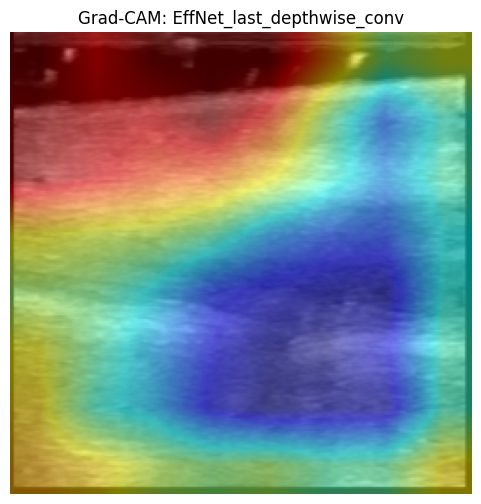

Patient ID: 5120817
Applying Grad-CAM on EfficientNet last depthwise conv layer

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 1920, 8, 8])
 - Activations min/max: -1.6620609760284424 / 2.692866086959839

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 1920, 8, 8])
 - Activations min/max: -1.6620609760284424 / 2.692866086959839

[DEBUG] Backward Hook Called:
 - grad_output shape: torch.Size([1, 1920, 8, 8])
 - grad_output min/max: -0.04177302494645119 / 0.05309140309691429

[DEBUG] Backward Hook Called:
 - grad_output shape: torch.Size([1, 1920, 8, 8])
 - grad_output min/max: -0.04177302494645119 / 0.05309140309691429


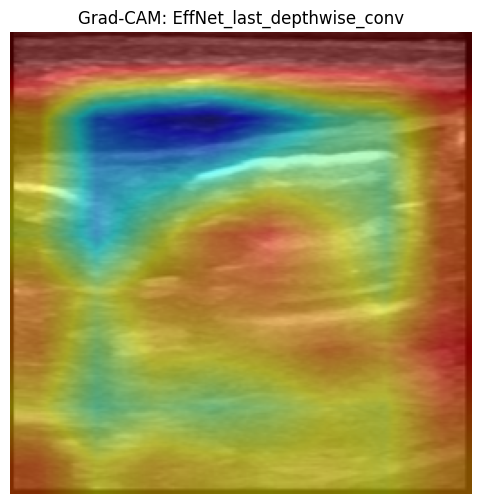

Patient ID: 19052118
Applying Grad-CAM on EfficientNet last depthwise conv layer

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 1920, 8, 8])
 - Activations min/max: -1.3795171976089478 / 3.788980007171631

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 1920, 8, 8])
 - Activations min/max: -1.3795171976089478 / 3.788980007171631

[DEBUG] Backward Hook Called:
 - grad_output shape: torch.Size([1, 1920, 8, 8])
 - grad_output min/max: -0.05294132977724075 / 0.06179020553827286

[DEBUG] Backward Hook Called:
 - grad_output shape: torch.Size([1, 1920, 8, 8])
 - grad_output min/max: -0.05294132977724075 / 0.06179020553827286


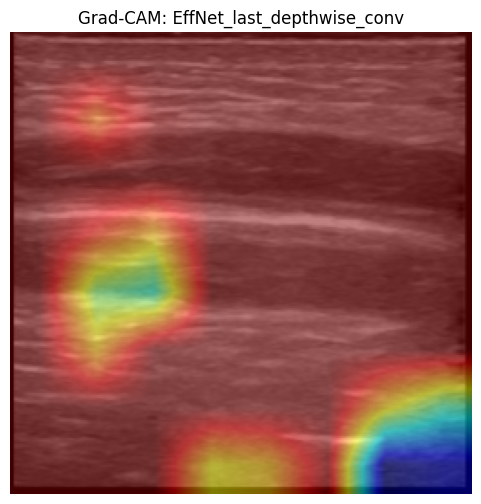

Patient ID: 25061918
Applying Grad-CAM on EfficientNet last depthwise conv layer

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 1920, 8, 8])
 - Activations min/max: -1.360605239868164 / 3.4342143535614014

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 1920, 8, 8])
 - Activations min/max: -1.360605239868164 / 3.4342143535614014

[DEBUG] Backward Hook Called:
 - grad_output shape: torch.Size([1, 1920, 8, 8])
 - grad_output min/max: -0.043232377618551254 / 0.048339322209358215

[DEBUG] Backward Hook Called:
 - grad_output shape: torch.Size([1, 1920, 8, 8])
 - grad_output min/max: -0.043232377618551254 / 0.048339322209358215


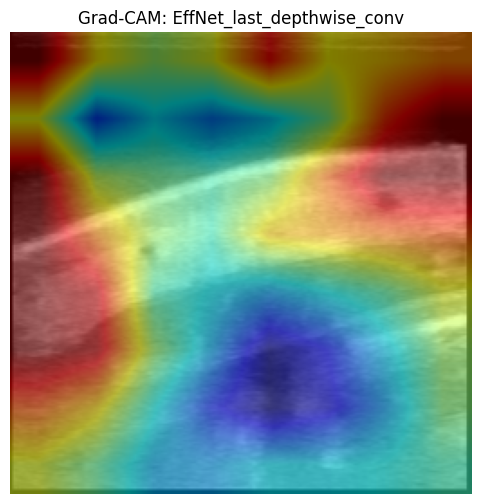

Patient ID: 26061918
Applying Grad-CAM on EfficientNet last depthwise conv layer

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 1920, 8, 8])
 - Activations min/max: -1.5444977283477783 / 4.071822643280029

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 1920, 8, 8])
 - Activations min/max: -1.5444977283477783 / 4.071822643280029

[DEBUG] Backward Hook Called:
 - grad_output shape: torch.Size([1, 1920, 8, 8])
 - grad_output min/max: -0.05271710082888603 / 0.051144689321517944

[DEBUG] Backward Hook Called:
 - grad_output shape: torch.Size([1, 1920, 8, 8])
 - grad_output min/max: -0.05271710082888603 / 0.051144689321517944


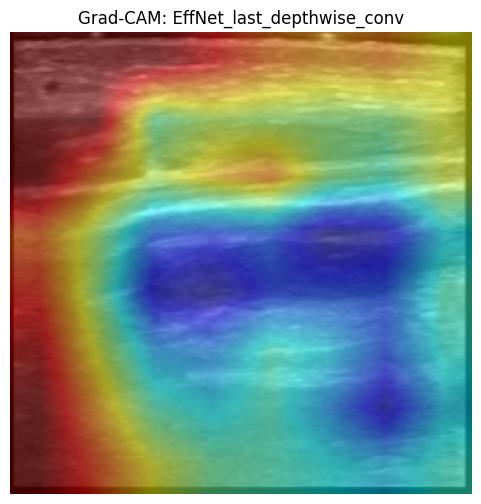

Patient ID: 54020819
Applying Grad-CAM on EfficientNet last depthwise conv layer

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 1920, 8, 8])
 - Activations min/max: -1.3505750894546509 / 3.511923313140869

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 1920, 8, 8])
 - Activations min/max: -1.3505750894546509 / 3.511923313140869

[DEBUG] Backward Hook Called:
 - grad_output shape: torch.Size([1, 1920, 8, 8])
 - grad_output min/max: -0.04210502281785011 / 0.05953506752848625

[DEBUG] Backward Hook Called:
 - grad_output shape: torch.Size([1, 1920, 8, 8])
 - grad_output min/max: -0.04210502281785011 / 0.05953506752848625


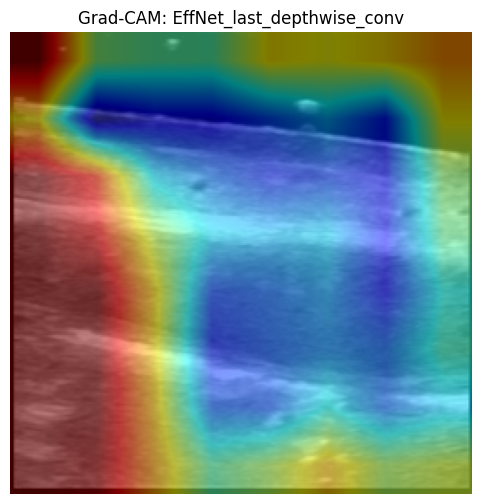

In [ ]:
model.eval()

chosen_patients = [58041919, 5120817, 19052118, 25061918, 26061918, 54020819]
body_part = '_AB1_R'

for patient in chosen_patients:
    patient_id = str(patient)
    print(f'Patient ID: {patient_id}')

    grad_cam_img_path = f'/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images_bluethingremoved/{patient_id}/{patient_id}{body_part}.jpg'

    target_layer = model.efficientnet._blocks[-1]._depthwise_conv
    print('Applying Grad-CAM on EfficientNet last depthwise conv layer')
    apply_grad_cam(grad_cam_img_path, model, 'EffNet_last_depthwise_conv', target_layer)

    torch.cuda.empty_cache()


Patient ID: 58041919

[DEBUG] Running forward pass...

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.657594680786133

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.657594680786133

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.657594680786133

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.657594680786133

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.657594680786133

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.657594680786133

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 128, 128, 128])
 - Activations min/max: 0.0 / 7.244285583496094

[DEBUG] Forward Hook Called:
 - Ac

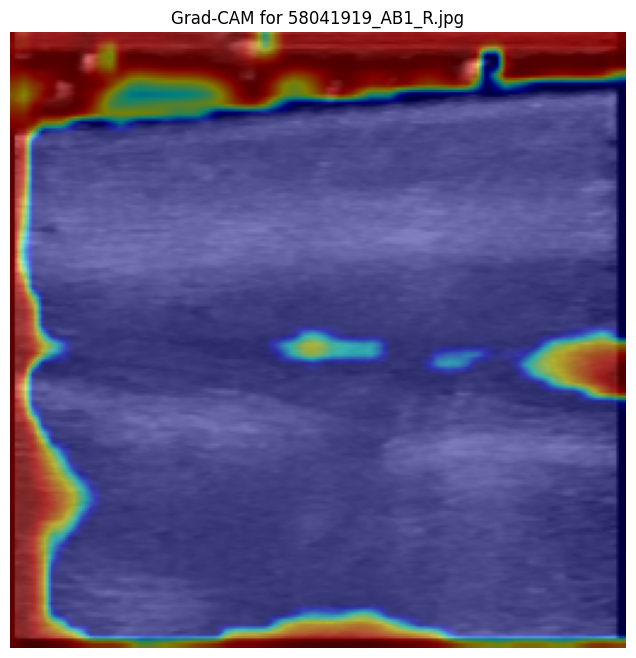

Patient ID: 5120817

[DEBUG] Running forward pass...

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.834702968597412

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.834702968597412

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.834702968597412

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.834702968597412

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.834702968597412

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.834702968597412

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 128, 128, 128])
 - Activations min/max: 0.0 / 7.06358528137207

[DEBUG] Forward Hook Called:
 - Acti

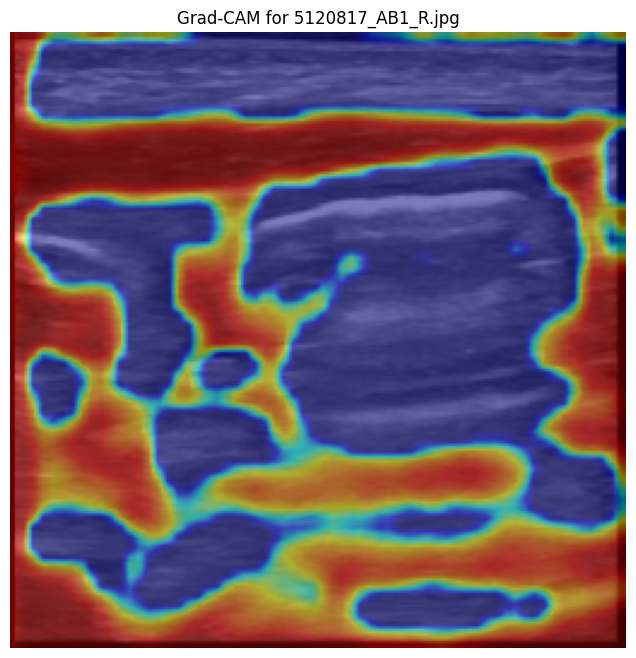

Patient ID: 19052118

[DEBUG] Running forward pass...

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.681114673614502

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.681114673614502

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.681114673614502

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.681114673614502

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.681114673614502

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.681114673614502

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 128, 128, 128])
 - Activations min/max: 0.0 / 6.594821453094482

[DEBUG] Forward Hook Called:
 - Ac

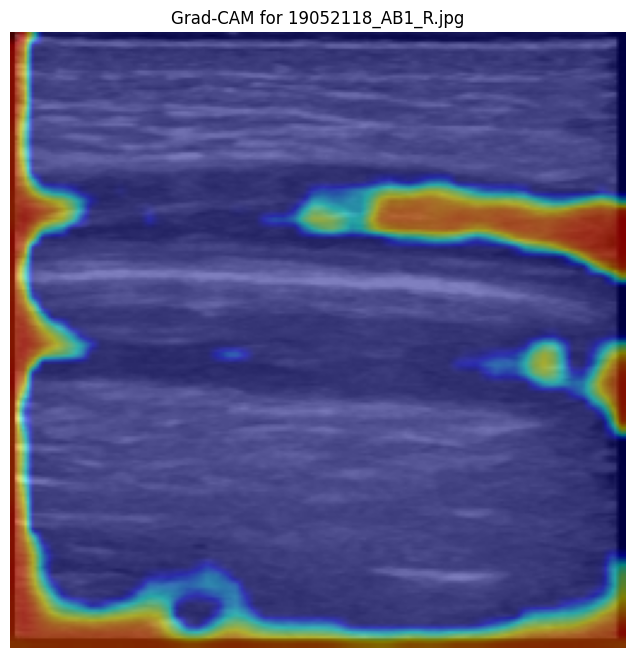

Patient ID: 25061918

[DEBUG] Running forward pass...

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 5.152105331420898

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 5.152105331420898

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 5.152105331420898

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 5.152105331420898

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 5.152105331420898

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 5.152105331420898

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 128, 128, 128])
 - Activations min/max: 0.0 / 8.711532592773438

[DEBUG] Forward Hook Called:
 - Ac

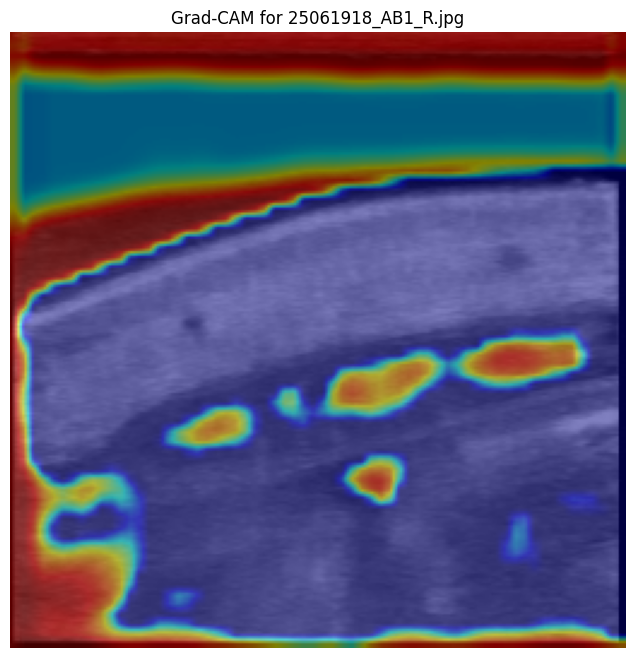

Patient ID: 26061918

[DEBUG] Running forward pass...

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.744503974914551

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.744503974914551

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.744503974914551

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.744503974914551

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.744503974914551

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.744503974914551

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 128, 128, 128])
 - Activations min/max: 0.0 / 6.5570268630981445

[DEBUG] Forward Hook Called:
 - A

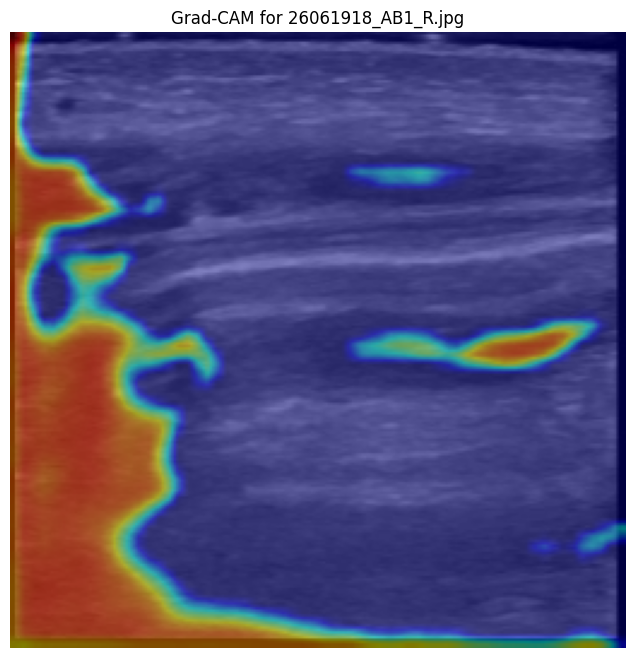

Patient ID: 54020819

[DEBUG] Running forward pass...

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.78444242477417

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.78444242477417

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.78444242477417

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.78444242477417

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.78444242477417

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 4.78444242477417

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 128, 128, 128])
 - Activations min/max: 0.0 / 8.611435890197754

[DEBUG] Forward Hook Called:
 - Activati

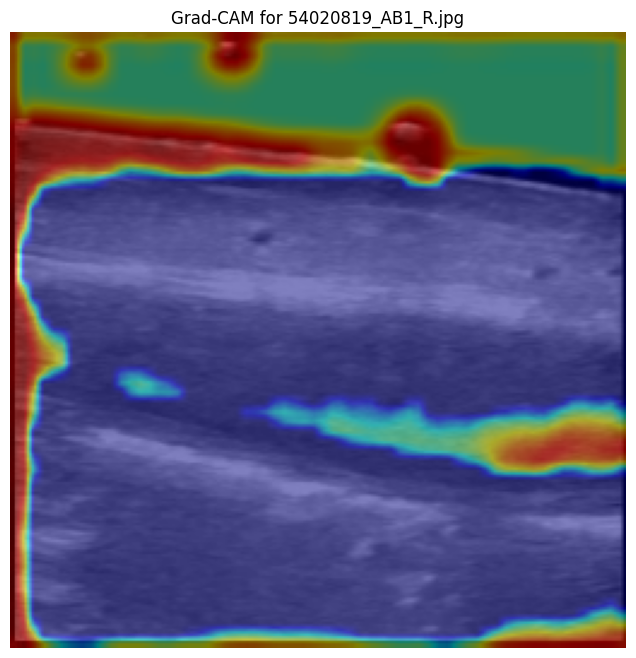

In [ ]:
for patient in chosen_patients:
    patient_id = str(patient)
    print(f'Patient ID: {patient_id}')

    # Image path
    grad_cam_img_path = f'/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images_bluethingremoved/{patient_id}/{patient_id}{body_part}.jpg'

    apply_grad_cam(grad_cam_img_path, model, 'Conv3', model.Conv3)


[DEBUG] Running forward pass...

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 6.930734157562256

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 6.930734157562256

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 6.930734157562256

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 6.930734157562256

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 6.930734157562256

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 64, 256, 256])
 - Activations min/max: 0.0 / 6.930734157562256

[DEBUG] Forward Hook Called:
 - Activations shape: torch.Size([1, 128, 128, 128])
 - Activations min/max: 0.0 / 9.488235473632812

[DEBUG] Forward Hook Called:
 - Activations shape: torc

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


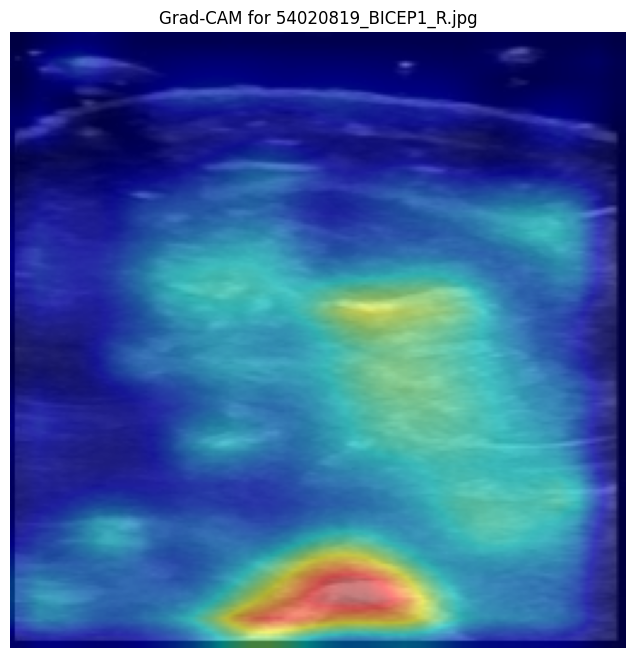

In [ ]:
apply_grad_cam(grad_cam_img_path, model, 'Conv3', model.Conv)

# P-Value

In [ ]:
MAE_list = []
MSE_list = []
RMSE_list = []
MAPE_list = []
for i in range(50):
    true_labels = []
    prediction = []
    for ith_batch, batch in enumerate(test_loader):
        X_train = [image.to('cuda') for image in batch[0]]
        y_train = torch.tensor(batch[1]).to('cuda').float()[0]
        y_pred = model(X_train)
        true_labels.append(y_train)
        prediction.append(y_pred)
    GT_FM = []
    Pred_FM = []
    for i in range(len(true_labels)):
        gt = torch.Tensor.tolist(true_labels[i])
        GT_FM.append(gt)
        pred = torch.Tensor.tolist(prediction[i])
        Pred_FM.append(pred)
    y_true = torch.tensor(GT_FM)
    y_pred = torch.tensor(Pred_FM)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    MAE_list.append(mae.item())
    MSE_list.append(mse.item())
    RMSE_list.append(rmse)
    MAPE_list.append(mape.item())

<ipython-input-84-a3eb96f5add5>:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_train = torch.tensor(batch[1]).to('cuda').float()[0]


In [ ]:
print(MAE_list)
print(MSE_list)
print(RMSE_list)
print(MAPE_list)

[1.6398766040802002, 1.6302286386489868, 1.6188504695892334, 1.658190131187439, 1.6155468225479126, 1.624005675315857, 1.6431121826171875, 1.635953664779663, 1.6155627965927124, 1.641308069229126, 1.6176574230194092, 1.656886339187622, 1.6283485889434814, 1.6031526327133179, 1.6217743158340454, 1.6769039630889893, 1.6045103073120117, 1.607015609741211, 1.6249042749404907, 1.651742935180664, 1.643117904663086, 1.6478866338729858, 1.6146246194839478, 1.628217339515686, 1.611294150352478, 1.618586778640747, 1.6365959644317627, 1.6227798461914062, 1.62075936794281, 1.6349464654922485, 1.596885085105896, 1.5990558862686157, 1.6187946796417236, 1.604508638381958, 1.6175687313079834, 1.62942373752594, 1.6408932209014893, 1.6201965808868408, 1.6676393747329712, 1.601599097251892, 1.640061616897583, 1.6201581954956055, 1.640268325805664, 1.6218782663345337, 1.6017427444458008, 1.6417087316513062, 1.6293411254882812, 1.6573941707611084, 1.5841608047485352, 1.6184848546981812]
[2.809145450592041,

In [ ]:
def Average(lst):
    return sum(lst) / len(lst)
print("MAE: ", Average(MAE_list))
print("MSE: ", Average(MSE_list))
print("RMSE: ", Average(RMSE_list))
print("MAPE: ", Average(MAPE_list))

MAE:  1.6269220876693726
MSE:  2.751225357055664
RMSE:  1.6585747962212354
MAPE:  81.01597671508789


## All

In [ ]:
ResNet18_LP_MAE_MAE = [0.04648197814822197, 0.04519886523485184, 0.048376698046922684, 0.05102362483739853, 0.04200226813554764, 0.041844915598630905, 0.042984385043382645, 0.051008980721235275, 0.03912623971700668, 0.04116343706846237, 0.0450211763381958, 0.04831387847661972, 0.042990267276763916, 0.0516321174800396, 0.046422380954027176, 0.0428861565887928, 0.04016643017530441, 0.045899342745542526, 0.04886137321591377, 0.04210586100816727, 0.0482005774974823, 0.0457969531416893, 0.04226180166006088, 0.046035099774599075, 0.04964829608798027, 0.04785540699958801, 0.03990448638796806, 0.04349493980407715, 0.04840794950723648, 0.04026925563812256, 0.04563742130994797, 0.04365463927388191, 0.04339928179979324, 0.03944479674100876, 0.040992457419633865, 0.041617251932621, 0.03837668150663376, 0.03909792751073837, 0.035172682255506516, 0.0506461039185524, 0.04808040335774422, 0.05727022886276245, 0.040348608046770096, 0.04638855904340744, 0.044032737612724304, 0.04659147188067436, 0.05073476582765579, 0.048987068235874176, 0.04434164613485336, 0.04724014922976494]
ResNet18_LP_MAE_MSE = [0.0027527562342584133, 0.00225449213758111, 0.0033381369430571795, 0.0039956760592758656, 0.002309242030605674, 0.0021087194327265024, 0.0026167756877839565, 0.0030082801822572947, 0.0022921711206436157, 0.002333505777642131, 0.003380507230758667, 0.003120796289294958, 0.0020515157375484705, 0.0033971648663282394, 0.002765908371657133, 0.002648676047101617, 0.00275154085829854, 0.003036517184227705, 0.0031961104832589626, 0.002621558029204607, 0.002995713148266077, 0.0033510352950543165, 0.00205508666113019, 0.002676929347217083, 0.003501828759908676, 0.0034257001243531704, 0.002256044652312994, 0.0022732026409357786, 0.002971238223835826, 0.0022789649665355682, 0.0024914927780628204, 0.0024216126184910536, 0.0025613356847316027, 0.002258892869576812, 0.0024121077731251717, 0.0022598272189497948, 0.0023062608670443296, 0.002626908477395773, 0.001847241073846817, 0.003149143885821104, 0.0028959447517991066, 0.004257111810147762, 0.0026214667595922947, 0.0027381593827158213, 0.0026302477344870567, 0.002755427034571767, 0.0030882791616022587, 0.003100783098489046, 0.002473933156579733, 0.0029121162369847298]
ResNet18_LP_MAE_RMSE = [0.05246671548952167, 0.04748149257954208, 0.05777661242282364, 0.06321136020744898, 0.04805457346190552, 0.04592079521008431, 0.05115442979629385, 0.05484779104264177, 0.04787662394784761, 0.04830637408916271, 0.05814212956848645, 0.05586408765293637, 0.04529366111884168, 0.058285202807644404, 0.05259190405050128, 0.05146528973105676, 0.052455131858556416, 0.05510460220551188, 0.05653415324614814, 0.05120115261597738, 0.05473310833733159, 0.05788812741015481, 0.04533306366362404, 0.05173905050556188, 0.05917625165477006, 0.05852948081397246, 0.0474978383962154, 0.04767811490543412, 0.05450906551974475, 0.04773850611964694, 0.04991485528440226, 0.04920988334157127, 0.05060964023515285, 0.04752781153784394, 0.04911321383421341, 0.047537640022931246, 0.04802354492375932, 0.051253375278080694, 0.04297954250392641, 0.05611723341203755, 0.05381398286504267, 0.06524654634651371, 0.05120026132347661, 0.052327424766711206, 0.051285940904765084, 0.052492161648876365, 0.055572287712512415, 0.055684675616268484, 0.04973864851983549, 0.05396402724949955]
ResNet18_LP_MAE_MAPE = [30.901592254638672, 31.29049301147461, 31.356800079345703, 32.78160858154297, 27.16561508178711, 28.172714233398438, 27.547698974609375, 32.94705581665039, 25.157651901245117, 27.283531188964844, 28.925600051879883, 30.565792083740234, 28.0874080657959, 33.249053955078125, 30.64939308166504, 28.687849044799805, 26.136398315429688, 29.23654556274414, 32.70735168457031, 28.164243698120117, 32.25054168701172, 28.61640167236328, 28.820186614990234, 29.266759872436523, 31.26235008239746, 30.183034896850586, 25.82872772216797, 28.148048400878906, 31.04250144958496, 26.04660987854004, 30.05912971496582, 28.116592407226562, 27.098617553710938, 26.152690887451172, 25.88064956665039, 26.616254806518555, 24.730663299560547, 25.117206573486328, 22.17123031616211, 33.0120735168457, 31.038198471069336, 37.65074157714844, 25.345443725585938, 30.03291130065918, 28.688568115234375, 30.413469314575195, 33.54026794433594, 31.469860076904297, 28.77408218383789, 30.539756774902344]

ResNet18_LP_MSE_MAE = [0.045754194259643555, 0.04438377544283867, 0.04270970821380615, 0.049648113548755646, 0.05210460349917412, 0.048647522926330566, 0.04840411990880966, 0.04598831385374069, 0.04873140901327133, 0.04367019981145859, 0.04461967945098877, 0.04222412779927254, 0.04346819594502449, 0.040206294506788254, 0.046167053282260895, 0.040044497698545456, 0.04612063616514206, 0.04642218351364136, 0.04128466174006462, 0.04480713605880737, 0.04507523030042648, 0.035699617117643356, 0.04861033707857132, 0.050963979214429855, 0.0416458360850811, 0.04147512465715408, 0.04583616182208061, 0.047136884182691574, 0.039461392909288406, 0.047328151762485504, 0.044708479195833206, 0.04323362186551094, 0.050379376858472824, 0.05050204321742058, 0.03828396275639534, 0.03811041638255119, 0.04653846099972725, 0.047341424971818924, 0.04361007735133171, 0.04694709926843643, 0.044338393956422806, 0.040276139974594116, 0.05205517262220383, 0.03920074552297592, 0.040745437145233154, 0.04406485706567764, 0.04568524286150932, 0.04791707545518875, 0.04357587546110153, 0.042990513145923615]
ResNet18_LP_MSE_MSE = [0.0026983332354575396, 0.002723583485931158, 0.002449049148708582, 0.003259220626205206, 0.003017778042703867, 0.0033191211987286806, 0.0029909962322562933, 0.0029727716464549303, 0.0034355991519987583, 0.002280157757923007, 0.002660587662830949, 0.0024130619131028652, 0.0023080450482666492, 0.0021642043720930815, 0.0027824994176626205, 0.002109960187226534, 0.002598294522613287, 0.0028258354868739843, 0.002271361416205764, 0.002487652003765106, 0.0025540951173752546, 0.001824073144234717, 0.0031984068918973207, 0.0032204941380769014, 0.002233887556940317, 0.0021969606168568134, 0.00245892396196723, 0.002834501676261425, 0.002514112275093794, 0.002938333433121443, 0.0025979862548410892, 0.0022797822020947933, 0.002944402862340212, 0.003021546173840761, 0.0020311973057687283, 0.001996321137994528, 0.0026425316464155912, 0.0028481793124228716, 0.0023815776221454144, 0.002548463409766555, 0.0026431428268551826, 0.002375483512878418, 0.003579267067834735, 0.0019002265762537718, 0.002267954172566533, 0.00305644772015512, 0.0027607439551502466, 0.0030656945891678333, 0.0026208660565316677, 0.0022858930751681328]
ResNet18_LP_MSE_RMSE = [0.051945483301799586, 0.052187963036807235, 0.049487868702426274, 0.05708958421818472, 0.054934306609839605, 0.057611814749482425, 0.054690001209145106, 0.054523129463145546, 0.058613984269956926, 0.04775099745474441, 0.051580884665067044, 0.04912292655270923, 0.048042117441539245, 0.04652101000723309, 0.05274940205976387, 0.0459343029469974, 0.050973468810875396, 0.053158588082020994, 0.04765880208529966, 0.049876367186926375, 0.05053805612976477, 0.042709169322696, 0.056554459522634645, 0.05674939768911122, 0.04726401968665295, 0.04687174646689425, 0.049587538373740934, 0.053240038281930496, 0.050140924154763976, 0.054206396607055916, 0.05097044491507887, 0.04774706485319064, 0.05426235216372593, 0.05496859261287996, 0.04506880634949997, 0.04468020969058368, 0.051405560462031645, 0.053368336234352214, 0.0488014100425942, 0.05048230788867081, 0.05141150481025801, 0.04873893220905048, 0.05982697608800511, 0.04359158836580484, 0.047623042453906, 0.055285149182715605, 0.05254278214132029, 0.055368714895397686, 0.05119439477649548, 0.047811014161677566]
ResNet18_LP_MSE_MAPE = [31.967662811279297, 29.025190353393555, 29.61684799194336, 31.860580444335938, 34.25739288330078, 32.64765930175781, 31.207551956176758, 30.681842803955078, 31.11998176574707, 27.631027221679688, 29.091325759887695, 27.216690063476562, 29.260135650634766, 26.15511131286621, 30.684310913085938, 25.148540496826172, 30.066057205200195, 29.52933692932129, 27.456602096557617, 29.988616943359375, 29.78766632080078, 22.502334594726562, 32.1391487121582, 32.46160888671875, 25.811296463012695, 27.651905059814453, 30.485572814941406, 30.829065322875977, 25.83226776123047, 30.184968948364258, 28.625869750976562, 28.20488739013672, 32.33317184448242, 33.15891647338867, 24.726926803588867, 25.531387329101562, 30.975597381591797, 30.332448959350586, 28.303054809570312, 30.86174774169922, 27.86162757873535, 25.42133903503418, 33.78288269042969, 25.779876708984375, 25.594791412353516, 28.073123931884766, 28.52013397216797, 30.401519775390625, 29.598861694335938, 28.11008071899414]

ResNet18_FT_MAE_MAE = [0.08593330532312393, 0.08392561972141266, 0.0760926753282547, 0.08168193697929382, 0.08261716365814209, 0.08572867512702942, 0.0790942907333374, 0.08333903551101685, 0.08173917979001999, 0.08225780725479126, 0.07807378470897675, 0.0871124416589737, 0.07778319716453552, 0.08865369111299515, 0.0851801186800003, 0.08442750573158264, 0.08468426018953323, 0.0864105299115181, 0.08417101204395294, 0.0883314311504364, 0.08839626610279083, 0.08576586097478867, 0.08427415788173676, 0.08118605613708496, 0.0800752267241478, 0.09003642946481705, 0.08456417173147202, 0.08204226195812225, 0.08331380784511566, 0.08565777540206909, 0.08567269891500473, 0.0893278568983078, 0.0825849175453186, 0.08682405948638916, 0.08642742782831192, 0.0827392190694809, 0.08847019076347351, 0.08170825242996216, 0.08536411821842194, 0.08424083888530731, 0.0822925716638565, 0.07704505324363708, 0.08751071244478226, 0.08867792785167694, 0.08781353384256363, 0.08306840807199478, 0.08412422239780426, 0.07966570556163788, 0.08299887180328369, 0.08525972068309784]
ResNet18_FT_MAE_MSE = [0.009196576662361622, 0.00873634684830904, 0.0070622810162603855, 0.008171508088707924, 0.008667508140206337, 0.008890840224921703, 0.007665800862014294, 0.00869958009570837, 0.008236375637352467, 0.00832404289394617, 0.008216492831707, 0.009014857932925224, 0.00727714691311121, 0.009034210816025734, 0.008654830045998096, 0.008418457582592964, 0.009310970082879066, 0.008661285042762756, 0.008411329239606857, 0.009008543565869331, 0.009351695887744427, 0.00920577347278595, 0.008323850110173225, 0.008343870751559734, 0.007457956671714783, 0.00959744118154049, 0.008581370115280151, 0.008364406414330006, 0.008461935445666313, 0.008630985394120216, 0.008702398277819157, 0.009207610972225666, 0.008418634533882141, 0.010067329742014408, 0.00880882702767849, 0.009160620160400867, 0.009649842977523804, 0.008517058566212654, 0.008355310186743736, 0.008512896485626698, 0.008239598013460636, 0.007038552314043045, 0.009238088503479958, 0.009526177309453487, 0.00944837648421526, 0.008804055862128735, 0.008351432159543037, 0.0077148242853581905, 0.008343282155692577, 0.008948583155870438]
ResNet18_FT_MAE_RMSE = [0.09589878342482569, 0.09346842701313123, 0.08403737868508504, 0.09039639422403929, 0.09309945295331405, 0.09429125211238688, 0.08755455934452697, 0.09327153958045493, 0.0907544799850259, 0.09123619289484941, 0.09064487206514774, 0.0949466056945967, 0.08530619504532605, 0.09504846561636718, 0.09303133905302072, 0.09175215301339236, 0.0964933680771848, 0.0930660251797763, 0.09171329914252817, 0.09491334766969992, 0.09670416685823019, 0.09594672205336642, 0.09123513637943019, 0.09134479050038778, 0.0863594619698084, 0.09796653092531392, 0.09263568489129959, 0.09145712883274877, 0.09198877891170375, 0.09290309679510267, 0.09328664576357731, 0.09595629719943172, 0.0917531172978997, 0.10033608394797162, 0.09385535161981169, 0.09571112871762023, 0.09823361429533072, 0.09228791126801307, 0.09140738584350686, 0.0922653590771027, 0.09077223151085709, 0.08389608044505444, 0.09611497543816966, 0.09760213783239324, 0.09720275965328999, 0.09382993052394707, 0.09138617050485832, 0.08783407246255971, 0.09134156860757635, 0.0945969510918319]
ResNet18_FT_MAE_MAPE = [64.15689849853516, 62.15416717529297, 56.428985595703125, 60.552757263183594, 61.23305130004883, 63.24955368041992, 58.53608703613281, 61.71034622192383, 60.470069885253906, 60.95521926879883, 59.098060607910156, 63.97789001464844, 57.199623107910156, 64.54521179199219, 62.587486267089844, 61.58914566040039, 63.82096862792969, 62.80856704711914, 61.98681640625, 64.4841537475586, 65.18704223632812, 64.0478286743164, 61.841190338134766, 60.71367263793945, 58.583194732666016, 66.1622314453125, 62.36311721801758, 60.75299835205078, 61.697303771972656, 62.62591552734375, 62.989437103271484, 65.08596801757812, 61.3231315612793, 65.94181060791016, 63.535987854003906, 62.80710220336914, 65.61209869384766, 61.285865783691406, 62.181556701660156, 62.03935623168945, 60.79988479614258, 56.62576675415039, 64.78043365478516, 65.67194366455078, 64.97550201416016, 61.72353744506836, 61.87525939941406, 58.68708038330078, 61.427032470703125, 63.283287048339844]

ResNet18_FT_MAPE_MAE = [0.12493553012609482, 0.12066833674907684, 0.11491549015045166, 0.11117801815271378, 0.11650792509317398, 0.12161514908075333, 0.12078776210546494, 0.11513607203960419, 0.1148051768541336, 0.12158913910388947, 0.11314775794744492, 0.12094428390264511, 0.11758378893136978, 0.11843860149383545, 0.12244564294815063, 0.11683241277933121, 0.1197398453950882, 0.12300135940313339, 0.122744120657444, 0.11461640894412994, 0.12379208952188492, 0.12167912721633911, 0.11367283761501312, 0.12011472880840302, 0.11327774822711945, 0.11828043311834335, 0.11703171581029892, 0.12012644112110138, 0.11918926239013672, 0.11594498157501221, 0.11852103471755981, 0.1220373883843422, 0.11656840890645981, 0.11775193363428116, 0.1215241327881813, 0.12557676434516907, 0.11752166599035263, 0.11936470121145248, 0.12236110121011734, 0.11385178565979004, 0.11682132631540298, 0.11424461752176285, 0.11712014675140381, 0.11936251819133759, 0.12141092121601105, 0.11788234859704971, 0.12320393323898315, 0.1165391057729721, 0.11359252035617828, 0.12006659805774689]
ResNet18_FT_MAPE_MSE = [0.028555992990732193, 0.026814138516783714, 0.02432931773364544, 0.024225549772381783, 0.026669159531593323, 0.026442566886544228, 0.02733052335679531, 0.025028366595506668, 0.02620908059179783, 0.02737623080611229, 0.024512900039553642, 0.026796843856573105, 0.026423480361700058, 0.026759739965200424, 0.026399681344628334, 0.025899941101670265, 0.025390779599547386, 0.027539487928152084, 0.02576257660984993, 0.023738114163279533, 0.026366110891103745, 0.027528297156095505, 0.026124868541955948, 0.027724143117666245, 0.02478313073515892, 0.026423264294862747, 0.025450434535741806, 0.025562871247529984, 0.027156421914696693, 0.025083381682634354, 0.025954455137252808, 0.028080591931939125, 0.026760179549455643, 0.025948550552129745, 0.026835834607481956, 0.02932114526629448, 0.024538977071642876, 0.027053778991103172, 0.02811305597424507, 0.02424478344619274, 0.025581056252121925, 0.024151036515831947, 0.026400959119200706, 0.02523340843617916, 0.027110332623124123, 0.026193883270025253, 0.027590617537498474, 0.026734966784715652, 0.024480635300278664, 0.027365583926439285]
ResNet18_FT_MAE_RMSE = [0.16898518571381396, 0.16375023211215217, 0.155978581009206, 0.15564559027605562, 0.16330694881600513, 0.16261170587182286, 0.1653194584941389, 0.15820356062840896, 0.16189218817409884, 0.16545764051899292, 0.15656596066691394, 0.16369741554640715, 0.1625530078519006, 0.16358404557046638, 0.16247978749564002, 0.16093458640599995, 0.15934484491048773, 0.16595025739103897, 0.16050724784211437, 0.1540717825017921, 0.16237644808008256, 0.16591653671679477, 0.16163189209421497, 0.16650568494098406, 0.1574265883996694, 0.16255234324629944, 0.15953192324968005, 0.15988393054816355, 0.16479205658858892, 0.1583773395490477, 0.16110386443922692, 0.1675726467295278, 0.16358538916864074, 0.16108553799807648, 0.1638164662281602, 0.1712341825287652, 0.15664921663271372, 0.1644803301039464, 0.16766948432629317, 0.1557073647782684, 0.15994078983211857, 0.15540603757844143, 0.16248371955122368, 0.15885027049451053, 0.16465215644844777, 0.16184524481746523, 0.1661042369643185, 0.16350830799906058, 0.1564628879328215, 0.16542546335567354]
ResNet18_FT_MAE_MAPE = [68.37893676757812, 65.67686462402344, 62.3962287902832, 60.05936813354492, 61.84660339355469, 66.37803649902344, 65.42724609375, 61.94781494140625, 61.54438400268555, 66.50251007080078, 60.91201400756836, 66.28731536865234, 63.479984283447266, 63.482643127441406, 67.5003433227539, 63.02922439575195, 65.67626953125, 67.54904174804688, 68.00205993652344, 62.02490997314453, 68.34039306640625, 65.48756408691406, 60.02526092529297, 64.91938781738281, 61.32472229003906, 63.004390716552734, 63.38990783691406, 66.25355529785156, 64.20060729980469, 63.46533966064453, 64.68128204345703, 65.4751205444336, 62.438499450683594, 63.516151428222656, 66.63233947753906, 68.47660064697266, 65.03461456298828, 64.2806167602539, 66.78070831298828, 61.004329681396484, 63.5670051574707, 62.18071746826172, 62.65570068359375, 65.13451385498047, 66.23446655273438, 63.71305465698242, 67.42362976074219, 62.17142868041992, 61.29935836791992, 64.83910369873047]

ResNet18_FT_MSE_MAE = [0.0793069377541542, 0.07831829786300659, 0.07808049023151398, 0.07332787662744522, 0.07595999538898468, 0.06982362270355225, 0.06791128218173981, 0.06994370371103287, 0.06740599125623703, 0.08334056288003922, 0.06566540896892548, 0.0800081118941307, 0.08098860830068588, 0.0679372027516365, 0.06821326911449432, 0.07929345220327377, 0.06864459812641144, 0.07923652976751328, 0.06809480488300323, 0.06475593149662018, 0.06944260746240616, 0.07514812797307968, 0.07589785009622574, 0.06843560934066772, 0.06677640974521637, 0.0677696242928505, 0.06941570341587067, 0.07571374624967575, 0.06169038265943527, 0.06666858494281769, 0.0746140256524086, 0.06754505634307861, 0.0671558827161789, 0.06910896301269531, 0.07180021703243256, 0.06893786042928696, 0.07578067481517792, 0.07547465711832047, 0.0679548978805542, 0.06796997040510178, 0.0671534463763237, 0.0692223459482193, 0.07495627552270889, 0.07641543447971344, 0.06642027199268341, 0.06695495545864105, 0.06715379655361176, 0.06588926166296005, 0.07579601556062698, 0.06277791410684586]
ResNet18_FT_MSE_MSE = [0.009117753244936466, 0.007482753600925207, 0.0090597253292799, 0.008618591353297234, 0.008591825142502785, 0.007298218552023172, 0.007469984702765942, 0.00715660909190774, 0.0075647421181201935, 0.010202641598880291, 0.0064291260205209255, 0.008081545121967793, 0.008214322850108147, 0.0058751702308654785, 0.007313067559152842, 0.008545489981770515, 0.006523900665342808, 0.00842555332928896, 0.006986965425312519, 0.007332307286560535, 0.006131283473223448, 0.008190153166651726, 0.007845763117074966, 0.006134436931461096, 0.007552692200988531, 0.007073162589222193, 0.006322688423097134, 0.007941261865198612, 0.005764246918261051, 0.007157476153224707, 0.008908001706004143, 0.006493265274912119, 0.006558810826390982, 0.00698823481798172, 0.007310546934604645, 0.0066163623705506325, 0.00842076726257801, 0.007611563894897699, 0.006856262683868408, 0.006785516627132893, 0.006481565535068512, 0.006887626834213734, 0.007297586649656296, 0.00822421908378601, 0.006210337392985821, 0.006257446017116308, 0.00786405336111784, 0.007316348142921925, 0.007553751580417156, 0.006041997112333775]
ResNet18_FT_MSE_RMSE = [0.09548692708919093, 0.08650291093902683, 0.0951825894230657, 0.09283636869943392, 0.09269209859800771, 0.08542961168133198, 0.08642907324949135, 0.0845967439793503, 0.08697552597208133, 0.10100812640020748, 0.08018183098758051, 0.08989741443427499, 0.09063290158716175, 0.07664965903946004, 0.08551647536675516, 0.09244181944212541, 0.08077066710968041, 0.0917908128806416, 0.08358806987430993, 0.08562889282573105, 0.07830251256009253, 0.09049946500754424, 0.08857631239261977, 0.078322646351238, 0.08690622647997398, 0.08410209622371011, 0.07951533451540736, 0.08911375800177329, 0.07592263771933278, 0.08460186849724247, 0.09438221074971778, 0.08058079966662107, 0.08098648545523494, 0.0835956626744577, 0.08550173644204336, 0.08134102513830664, 0.09176473866675593, 0.08724427714697222, 0.08280255239947866, 0.08237424735396914, 0.08050817061061885, 0.08299172750469612, 0.08542591322108471, 0.09068748030343556, 0.07880569391221563, 0.07910402023359059, 0.0886794979751117, 0.085535654220459, 0.08691232122327165, 0.07773028439632634]
ResNet18_FT_MSE_MAPE = [55.14665985107422, 53.87114334106445, 52.93476104736328, 49.97720718383789, 52.601505279541016, 48.519508361816406, 47.077362060546875, 47.30329513549805, 46.092529296875, 55.65168380737305, 44.9566650390625, 53.58168029785156, 54.385196685791016, 45.93071746826172, 47.18467712402344, 53.65856170654297, 46.34713363647461, 54.70522689819336, 47.25934600830078, 45.808143615722656, 46.72588348388672, 50.24708557128906, 51.7636833190918, 47.571136474609375, 46.350250244140625, 47.05000686645508, 46.04248046875, 49.88120651245117, 40.16265106201172, 47.137664794921875, 50.517337799072266, 44.664676666259766, 44.90895080566406, 46.99675369262695, 47.44716262817383, 47.488338470458984, 51.95676040649414, 51.78384780883789, 47.093589782714844, 45.082618713378906, 46.4314079284668, 44.704856872558594, 49.640464782714844, 53.7257194519043, 45.835693359375, 44.039424896240234, 48.75255584716797, 44.06405258178711, 50.730525970458984, 44.13511657714844]

EfficientNetB1_LP_MAE_MAE = [0.1634293496608734, 0.16510580480098724, 0.16637356579303741, 0.163960799574852, 0.15493127703666687, 0.16334280371665955, 0.158257395029068, 0.16261157393455505, 0.15580078959465027, 0.15679042041301727, 0.16648714244365692, 0.1654203236103058, 0.16201546788215637, 0.16813167929649353, 0.16738733649253845, 0.1670335829257965, 0.1695541888475418, 0.16034404933452606, 0.1666402965784073, 0.1608816534280777, 0.15877294540405273, 0.16003647446632385, 0.16882631182670593, 0.17019440233707428, 0.16529962420463562, 0.1689644157886505, 0.16883417963981628, 0.17148880660533905, 0.16616208851337433, 0.1568078249692917, 0.1626816987991333, 0.16086068749427795, 0.1643143743276596, 0.16079367697238922, 0.17233628034591675, 0.15620841085910797, 0.16542799770832062, 0.15730002522468567, 0.15595968067646027, 0.16210173070430756, 0.1646203249692917, 0.16739988327026367, 0.17313681542873383, 0.16577336192131042, 0.1644574999809265, 0.16538767516613007, 0.1582901030778885, 0.1592744141817093, 0.17163586616516113, 0.1560596227645874]
EfficientNetB1_LP_MAE_MSE = [0.028795018792152405, 0.029205629602074623, 0.030131462961435318, 0.02962569333612919, 0.026185456663370132, 0.02838108502328396, 0.02696521207690239, 0.02823818288743496, 0.026988515630364418, 0.02646375633776188, 0.02959783934056759, 0.030693775042891502, 0.027417916804552078, 0.030149277299642563, 0.02976977825164795, 0.030326705425977707, 0.031133469194173813, 0.027347708120942116, 0.029472356662154198, 0.027469854801893234, 0.027180898934602737, 0.028144365176558495, 0.03017186000943184, 0.030977029353380203, 0.029312124475836754, 0.03058239258825779, 0.030701126903295517, 0.03136945143342018, 0.029710758477449417, 0.02704581990838051, 0.02830846607685089, 0.027973875403404236, 0.028337229043245316, 0.027731407433748245, 0.03159979730844498, 0.02732953056693077, 0.029581373557448387, 0.02655770257115364, 0.026884332299232483, 0.028257399797439575, 0.029110416769981384, 0.03009919263422489, 0.03203705698251724, 0.029579168185591698, 0.029506314545869827, 0.02911374345421791, 0.027433451265096664, 0.027220508083701134, 0.03140754997730255, 0.026075854897499084]
EfficientNetB1_LP_MAE_RMSE = [0.16969095082576563, 0.17089654648960764, 0.1735841667936201, 0.172121158885621, 0.16181920980949738, 0.16846686624759172, 0.16421087685321697, 0.16804220567296466, 0.1642818177107997, 0.1626768463480955, 0.1720402259373301, 0.1751963899253963, 0.16558356441553032, 0.1736354724693159, 0.17253920786780014, 0.17414564429229262, 0.17644678856293705, 0.1653714247412234, 0.17167514864462532, 0.16574032340348932, 0.16486630624418908, 0.1677628241791324, 0.1737004893759135, 0.17600292427508188, 0.17120783999524308, 0.17487822216690616, 0.1752173704382517, 0.17711423272402527, 0.17236809007890475, 0.1644561336903568, 0.16825119933257798, 0.16725392492675392, 0.16833665389108016, 0.16652749753043264, 0.17776331823085711, 0.16531645582618437, 0.1719923648231176, 0.1629653416256157, 0.1639644238828426, 0.16809937476813996, 0.17061775045399405, 0.17349118892389, 0.17898898564581353, 0.1719859534543205, 0.1717740217433062, 0.17062749911493724, 0.16563046599311573, 0.1649863875709179, 0.1772217536796839, 0.1614801997072678]
EfficientNetB1_LP_MAE_MAPE = [101.20565795898438, 102.63710021972656, 102.7298812866211, 100.45674133300781, 95.6722412109375, 103.02073669433594, 98.26677703857422, 101.59239959716797, 95.15753173828125, 97.49685668945312, 103.58965301513672, 100.67823028564453, 102.29873657226562, 104.61517333984375, 104.66094207763672, 103.1077880859375, 104.85553741455078, 100.19425964355469, 104.06002044677734, 100.83635711669922, 98.37419128417969, 98.23194885253906, 105.65342712402344, 105.97676086425781, 102.60691833496094, 105.19034576416016, 104.98140716552734, 106.96269226074219, 103.16531372070312, 96.3152084350586, 101.45867919921875, 99.44092559814453, 103.42688751220703, 100.1710433959961, 107.46826171875, 95.59876251220703, 102.60400390625, 97.50988006591797, 95.54136657714844, 100.79924011230469, 102.51005554199219, 103.89764404296875, 107.7370376586914, 102.97277069091797, 101.52123260498047, 103.36051177978516, 97.82389068603516, 98.93377685546875, 107.02478790283203, 97.26776123046875]

EfficientNetB1_LP_MSE_MAE = [0.12478117644786835, 0.11975771188735962, 0.12532249093055725, 0.1234891265630722, 0.11913968622684479, 0.13597556948661804, 0.11827327311038971, 0.12504436075687408, 0.11924508959054947, 0.12144949287176132, 0.12004755437374115, 0.1256498396396637, 0.12103559821844101, 0.11098190397024155, 0.12764903903007507, 0.12281228601932526, 0.1216573566198349, 0.12409447133541107, 0.12189129739999771, 0.12064632028341293, 0.12798349559307098, 0.12328875064849854, 0.12854941189289093, 0.12067127227783203, 0.12163767963647842, 0.11709669977426529, 0.11764715611934662, 0.12444379180669785, 0.12029658257961273, 0.13332171738147736, 0.12540097534656525, 0.12680913507938385, 0.12175214290618896, 0.1220121756196022, 0.12739261984825134, 0.124134361743927, 0.1164189949631691, 0.13396544754505157, 0.1238667219877243, 0.1288255751132965, 0.12770915031433105, 0.1244860514998436, 0.1271555870771408, 0.12277666479349136, 0.12474416196346283, 0.1242050752043724, 0.1189364641904831, 0.11972089856863022, 0.12318152189254761, 0.12861618399620056]
EfficientNetB1_LP_MSE_MSE = [0.018390947952866554, 0.017969146370887756, 0.01861102692782879, 0.017847541719675064, 0.016472823917865753, 0.02046952210366726, 0.01619839109480381, 0.018474705517292023, 0.016971273347735405, 0.016950005665421486, 0.01749015972018242, 0.018839938566088676, 0.017592212185263634, 0.01464726310223341, 0.01880502700805664, 0.01702365279197693, 0.01652086153626442, 0.01863820105791092, 0.017440974712371826, 0.0166738573461771, 0.019022895023226738, 0.018245289102196693, 0.019009694457054138, 0.016905762255191803, 0.018021050840616226, 0.016810137778520584, 0.01696973852813244, 0.019009601324796677, 0.01726328581571579, 0.020784612745046616, 0.01872953586280346, 0.018703777343034744, 0.0171156395226717, 0.017313431948423386, 0.01945941150188446, 0.018273239955306053, 0.015759626403450966, 0.020619070157408714, 0.017649246379733086, 0.019355561584234238, 0.019152242690324783, 0.01791541650891304, 0.019684603437781334, 0.01769939996302128, 0.01796974614262581, 0.01810688152909279, 0.016407564282417297, 0.01722428947687149, 0.0181675236672163, 0.020543888211250305]
EfficientNetB1_LP_MSE_RMSE = [0.13561322926936942, 0.13404904464742656, 0.1364222376587805, 0.1335946919592057, 0.1283464994375217, 0.14307173761322414, 0.12727290008011843, 0.13592168891421275, 0.13027383984413526, 0.1301921874208337, 0.13225036756161557, 0.137258655705528, 0.13263563693541655, 0.12102587782054469, 0.13713142239492976, 0.13047472089250442, 0.12853350355554935, 0.1365217970065986, 0.13206428250049984, 0.1291272912523805, 0.13792351149541812, 0.13507512392071566, 0.13787564852813616, 0.13002216063114705, 0.13424250757720607, 0.1296539153998852, 0.1302679489672438, 0.13787531078767032, 0.13138982386667467, 0.1441686954406074, 0.13685589451245225, 0.1367617539483709, 0.1308267538490186, 0.13158051507888008, 0.1394969945980359, 0.13517854842875793, 0.12553735063100133, 0.1435934196173652, 0.13285046623829774, 0.13912426669792097, 0.13839162796327234, 0.13384848340161737, 0.14030182977346137, 0.13303909186032983, 0.13405128176420325, 0.13456181304178683, 0.12809201490497873, 0.131241340578613, 0.13478695659156453, 0.14333139297184797]
EfficientNetB1_LP_MSE_MAPE = [75.06920623779297, 70.90103149414062, 75.7563247680664, 74.64360046386719, 72.23226165771484, 83.68167877197266, 71.86627960205078, 74.80608367919922, 71.3704605102539, 74.1568374633789, 71.8401107788086, 75.31541442871094, 72.13912200927734, 66.4580307006836, 77.18006896972656, 75.06855010986328, 74.85565185546875, 74.13827514648438, 73.69441986083984, 73.52195739746094, 77.15782165527344, 73.67337036132812, 78.00799560546875, 73.07361602783203, 72.79103088378906, 69.60265350341797, 71.0478286743164, 73.95033264160156, 72.58435821533203, 80.15135192871094, 75.06874084472656, 76.64924621582031, 73.53169250488281, 73.3903579711914, 76.40189361572266, 74.60722351074219, 70.94107055664062, 81.34278106689453, 75.17255401611328, 77.86463165283203, 77.24406433105469, 75.1606674194336, 75.92247009277344, 74.26114654541016, 75.75076293945312, 74.3418960571289, 72.44755554199219, 71.84776306152344, 74.19915771484375, 76.2142333984375]

EfficientNetB1_FT_MAE_MAE = [0.04589071124792099, 0.04822453856468201, 0.04181722551584244, 0.046452783048152924, 0.05047459527850151, 0.04240960627794266, 0.04517524689435959, 0.03975015878677368, 0.04297906905412674, 0.04525323584675789, 0.04347405955195427, 0.043225325644016266, 0.05001189187169075, 0.04414248466491699, 0.04125013202428818, 0.039285432547330856, 0.04386035352945328, 0.042674917727708817, 0.05235917121171951, 0.043537646532058716, 0.049476929008960724, 0.037303753197193146, 0.04586247727274895, 0.05035332590341568, 0.04089214652776718, 0.04031690955162048, 0.04646515101194382, 0.04307316616177559, 0.048069797456264496, 0.045123837888240814, 0.05031222105026245, 0.04765567183494568, 0.052447982132434845, 0.050231702625751495, 0.04389219731092453, 0.055372171103954315, 0.044072963297367096, 0.04367338865995407, 0.046690039336681366, 0.04897050932049751, 0.04600156471133232, 0.041500695049762726, 0.04325615242123604, 0.045254193246364594, 0.04353683441877365, 0.04650326818227768, 0.04596823453903198, 0.04698188975453377, 0.04816536232829094, 0.04539619758725166]
EfficientNetB1_FT_MAE_MSE = [0.003101364942267537, 0.003267752006649971, 0.0029069448355585337, 0.002954518888145685, 0.003673673840239644, 0.003398916916921735, 0.0032443497329950333, 0.0025606704875826836, 0.0029661396984010935, 0.003327207174152136, 0.0031030108220875263, 0.0032596257515251637, 0.0036948181223124266, 0.002726130187511444, 0.003426582785323262, 0.002724181395024061, 0.002795769367367029, 0.0031619626097381115, 0.0040265596471726894, 0.00289215799421072, 0.003648866666480899, 0.0027042641304433346, 0.003536888165399432, 0.003753047436475754, 0.0027781978715211153, 0.0025889179669320583, 0.0036581933964043856, 0.00279955193400383, 0.00330946734175086, 0.0029209950007498264, 0.003170172218233347, 0.0031954701989889145, 0.003766580717638135, 0.003921921364963055, 0.003009725594893098, 0.003979595378041267, 0.003234313800930977, 0.002950346563011408, 0.0028478815220296383, 0.003715917933732271, 0.0031190775334835052, 0.0033924360759556293, 0.003091915976256132, 0.003383882809430361, 0.0030470523051917553, 0.00340653327293694, 0.0034165780525654554, 0.00358283007517457, 0.0034370191860944033, 0.002959662349894643]
EfficientNetB1_FT_MAE_RMSE = [0.05568989982274647, 0.057164254623409294, 0.05391609069246892, 0.0543554862745766, 0.060610839296611325, 0.05830023084792833, 0.05695919357746415, 0.05060306796610936, 0.05446227775626992, 0.05768194842541413, 0.05570467504696106, 0.05709313226234101, 0.06078501560674659, 0.052212356655407195, 0.05853702063927803, 0.05219369114197674, 0.05287503538880167, 0.056231331210794856, 0.06345517825341514, 0.05377878758591272, 0.060405849604826346, 0.05200253965378359, 0.05947174257913948, 0.06126212073113168, 0.05270861287798338, 0.05088141081900204, 0.060483000887889035, 0.052910792226197385, 0.057527970081959784, 0.054046230217748084, 0.05630428241469158, 0.05652849015309815, 0.06137247524451116, 0.06262524542836582, 0.0548609660404654, 0.06308403425623053, 0.056871027781560064, 0.054317092733424235, 0.05336554620754517, 0.06095832948607, 0.05584870216471915, 0.05824462272137772, 0.055604999561695276, 0.058171151006580234, 0.055200111459957714, 0.05836551441508025, 0.0584515017135185, 0.05985674627955123, 0.05862609645963479, 0.05440277888026165]
EfficientNetB1_FT_MAE_MAPE = [25.778118133544922, 27.414703369140625, 22.480960845947266, 26.637128829956055, 28.951799392700195, 22.35889434814453, 24.766111373901367, 21.820537567138672, 23.478008270263672, 25.115909576416016, 23.846975326538086, 23.045761108398438, 28.077322006225586, 25.327926635742188, 21.161375045776367, 21.740568161010742, 24.699750900268555, 22.88566017150879, 30.21016502380371, 24.02088165283203, 27.488378524780273, 19.580873489379883, 25.049983978271484, 28.539291381835938, 22.030548095703125, 21.79561424255371, 25.34295082092285, 24.678117752075195, 26.981931686401367, 26.215145111083984, 29.39579200744629, 27.684688568115234, 30.389183044433594, 27.705148696899414, 24.443681716918945, 32.483314514160156, 23.9191837310791, 24.21412467956543, 27.35285186767578, 27.05746841430664, 26.13431739807129, 21.541194915771484, 23.499467849731445, 25.036584854125977, 23.814620971679688, 25.613576889038086, 25.592771530151367, 25.14107894897461, 26.8155517578125, 26.72584342956543]

EfficientNetB1_FT_MSE_MAE = [0.11856033653020859, 0.12339349091053009, 0.12135188281536102, 0.1200593113899231, 0.11812931299209595, 0.1272939294576645, 0.11903040111064911, 0.12232811748981476, 0.12491624057292938, 0.12066663801670074, 0.11996597051620483, 0.12633591890335083, 0.11974382400512695, 0.11934149265289307, 0.12108023464679718, 0.11635281145572662, 0.11950113624334335, 0.1269296109676361, 0.1266215741634369, 0.11594188213348389, 0.12397769838571548, 0.12319733202457428, 0.12587961554527283, 0.1275530606508255, 0.11996538937091827, 0.1225413829088211, 0.12475140392780304, 0.12505143880844116, 0.12009014934301376, 0.12228627502918243, 0.1237432211637497, 0.1202547550201416, 0.12062082439661026, 0.1184147447347641, 0.12770576775074005, 0.12320717424154282, 0.11838860809803009, 0.12249632924795151, 0.12556035816669464, 0.11886253207921982, 0.12409321218729019, 0.1257452815771103, 0.12018142640590668, 0.12389323860406876, 0.11855542659759521, 0.1274009495973587, 0.12260960042476654, 0.12224044650793076, 0.12272801250219345, 0.12133936583995819]
EfficientNetB1_FT_MSE_MSE = [0.01684713177382946, 0.017644211649894714, 0.016937434673309326, 0.0167554821819067, 0.016711268573999405, 0.018473263829946518, 0.016644570976495743, 0.01718812808394432, 0.017681263387203217, 0.017718708142638206, 0.016363462433218956, 0.018706489354372025, 0.017449768260121346, 0.016885222867131233, 0.017030533403158188, 0.01558117289096117, 0.017058581113815308, 0.0183233805000782, 0.018525829538702965, 0.01558011956512928, 0.017911871895194054, 0.01759868487715721, 0.018102217465639114, 0.0194651260972023, 0.017440883442759514, 0.01778678223490715, 0.0180421844124794, 0.017799679189920425, 0.017085198312997818, 0.01704542338848114, 0.018431296572089195, 0.016954274848103523, 0.016942765563726425, 0.016031518578529358, 0.018419964239001274, 0.017604295164346695, 0.016372917219996452, 0.017680689692497253, 0.017926741391420364, 0.0160506684333086, 0.0177235659211874, 0.01810160093009472, 0.017012815922498703, 0.01753750815987587, 0.016821052879095078, 0.019048888236284256, 0.017145629972219467, 0.01750182919204235, 0.017403876408934593, 0.01696099527180195]
EfficientNetB1_FT_MSE_RMSE = [0.1297965013928706, 0.1328315160264864, 0.13014389986975697, 0.1294429688392023, 0.12927207190263257, 0.1359163854358499, 0.12901384025171772, 0.13110350141756064, 0.13297091180857268, 0.13311163789330446, 0.12791974997325065, 0.13677166868314514, 0.13209757098494032, 0.12994315244417934, 0.13050108583133777, 0.12482456845894228, 0.13060850322170953, 0.13536388181519546, 0.13610962324061796, 0.12482034916282393, 0.13383524160397386, 0.1326600349659128, 0.1345444813644882, 0.13951747595624822, 0.13206393695009822, 0.13336709577293476, 0.1343211986712425, 0.13341543834924213, 0.13071036038890652, 0.13055812264459513, 0.13576191134515306, 0.1302085820831466, 0.13016437901256406, 0.12661563323116684, 0.13572016887331548, 0.13268117863640908, 0.1279567005670139, 0.1329687545722575, 0.13389078157744977, 0.12669123266157215, 0.13312988365197126, 0.13454219014901875, 0.1304331856641503, 0.13242925718992715, 0.12969600178530977, 0.1380177098646556, 0.13094132263048006, 0.1322944790686382, 0.13192375225460573, 0.1302343859040382]
EfficientNetB1_FT_MSE_MAPE = [70.2275390625, 74.04502868652344, 73.08014678955078, 71.94461822509766, 70.01335906982422, 76.90766143798828, 71.0622329711914, 73.75009155273438, 75.79875946044922, 71.06275177001953, 72.5976791381836, 75.37065124511719, 70.71800994873047, 71.24823760986328, 72.64521789550781, 70.10150909423828, 70.70884704589844, 76.71188354492188, 76.16445922851562, 69.67138671875, 74.37132263183594, 73.968505859375, 76.04569244384766, 75.6367416381836, 70.7776107788086, 72.91680908203125, 75.04869842529297, 75.71643829345703, 71.7405014038086, 73.83815002441406, 73.24801635742188, 71.82275390625, 72.59666442871094, 71.39048767089844, 77.66297912597656, 73.92178344726562, 70.8168716430664, 73.09949493408203, 75.98790740966797, 72.26132202148438, 74.65371704101562, 75.79551696777344, 71.66231536865234, 74.72606658935547, 70.25070190429688, 76.17256927490234, 74.05661010742188, 73.0045166015625, 73.873046875, 73.02873992919922]

# Multi-UNets

In [ ]:
UNet_A = torch.load('/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/saved_models/UNet_MSE_A_FM_40epochs_WL-False_2024-04-10.pt')
UNet_A.to('cuda')
UNet_A.eval()
UNet_B = torch.load('/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/saved_models/UNet_MSE_B_FM_40epochs_WL-False_2024-04-10.pt')
UNet_B.to('cuda')
UNet_B.eval()
UNet_Q = torch.load('/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/saved_models/UNet_MSE_Q_FM_40epochs_WL-False_2024-04-10.pt')
UNet_Q.to('cuda')
UNet_Q.eval()

UNet(
  (inc): inconv(
    (conv): double_conv(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
  )
  (down1): down(
    (mpconv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): double_conv(
        (conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2

In [ ]:
class MultiUNetPatientDataset(Dataset):
    def __init__(self, transform = None,
                 augmented_dataset = False,
                 augment = 0, # this can be 0 (no augmentation), 5 (augment by 4 times plus original image), 8 and 15
                 threshold = False,
                 speckle = False,
                 despeckle = False,
                 number_of_image = 3,
                 crop = [1, 1, 1],
                 output = "FM"):
        self.root_dir = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images'
        self.patients = os.listdir(self.root_dir)
        for data in test_data:
          self.patients.remove(str(data))
        self.transform = transform
        self.augment = augment
        self.threshold = threshold
        self.speckle = speckle
        self.augmented_dataset = augmented_dataset
        self.despeckle = despeckle
        self.number_of_image = number_of_image
        # Crop in the order of Abdomen, Biceps, and Quadriceps
        self.crop = crop
        self.output = output

    def __len__(self):
        return len(self.patients)

    def __getitem__(self, idx):
        patient_id = self.patients[idx]
        patient_path = os.path.join(self.root_dir, patient_id)
        images_A, images_B, images_Q = self.load_patient_data(patient_path)
        if self.output == "FM":
          return images_A, images_B, images_Q, labels_dict[int(patient_id)][0], labels_dict[int(patient_id)][2], labels_dict[int(patient_id)][3]
        if self.output == "FFM":
          return images_A, images_B, images_Q, labels_dict[int(patient_id)][1], labels_dict[int(patient_id)][2], labels_dict[int(patient_id)][3]

    def preprocess(self, img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, crop):
        image = Image.open(img_path)
        width, height = image.size
        crop_rectangle = (0, 0, width, round(height*crop))
        image = image.crop(crop_rectangle)
        if self.speckle:
          image = image.filter(ImageFilter.MedianFilter(size=MF_size))
        if self.threshold:
          image = torch.where(image < threshold/255, torch.tensor(0.0), image)
        if self.despeckle:
          image_np = np.array(image)
          despeckled_image = cv2.fastNlMeansDenoisingColored(image_np, None, h=10, templateWindowSize=7, searchWindowSize=21)
          image = Image.fromarray(despeckled_image)
        if not self.augmented_dataset:
          image = self.transform(image)
        images.append(image)

        ## Augmentation
        if self.augment >= 5:
          imx = image
          imx = TF.hflip(imx)
          images.append(imx)
          imx = TF.vflip(imx)
          images.append(imx)
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        if self.augment >= 8:
          imx = TF.vflip(imx)
          images.append(imx)
          angle = random.choice([15])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([45])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        if self.augment >= 15:
          imx = image
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          imx = image
          angle = random.choice([-90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          imx = image
          angle = random.choice([-60])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-45])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-15])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([30])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([60])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        return images

    def load_patient_data(self, patient_path):
        images_A = []
        images_B = []
        images_Q = []
        threshold = 100
        AB = 0
        BICEP = 0
        QUAD = 0
        MF_size = 5
        h = 10
        templateWindowSize = 7
        searchWindowSize = 21
        for img_file in os.listdir(patient_path):
          # Process Abdomen images
          if 'AB' in img_file and AB < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images_A = self.preprocess(img_path, MF_size, images_A, threshold, h, templateWindowSize, searchWindowSize, self.crop[0])
              AB += 1
          # Process Bicep images
          elif 'BICEP' in img_file and BICEP < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images_B = self.preprocess(img_path, MF_size, images_B, threshold, h, templateWindowSize, searchWindowSize, self.crop[1])
              BICEP += 1
          # Process Quad images
          elif 'QUAD' in img_file and QUAD < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images_Q = self.preprocess(img_path, MF_size, images_Q, threshold, h, templateWindowSize, searchWindowSize, self.crop[2])
              QUAD += 1
        return images_A, images_B, images_Q

32
9


NameError: name 'im_converterX' is not defined

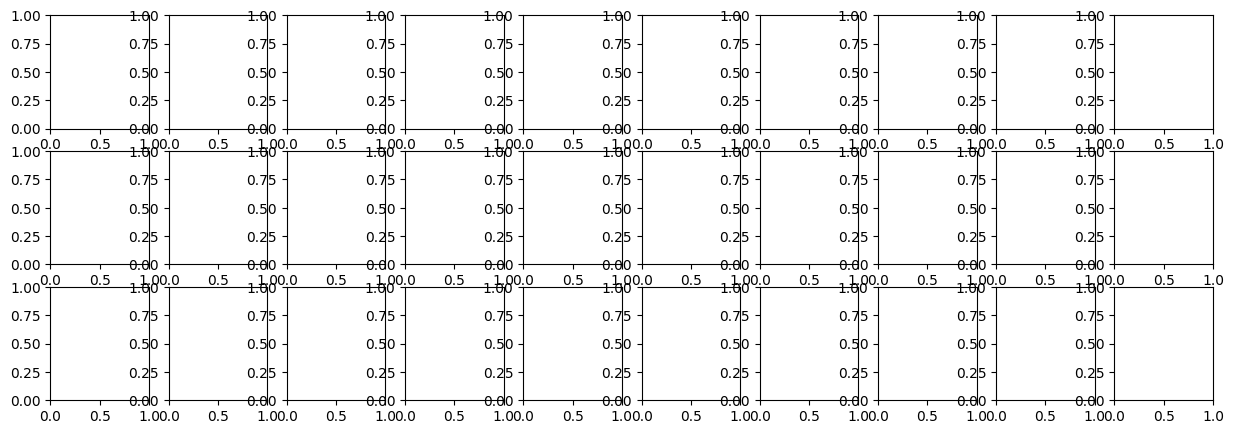

In [ ]:
normalization_factors = 0.5
tx_X = transforms.Compose([transforms.Resize((256, 256)),
                           transforms.ToTensor(),
                           transforms.Normalize(normalization_factors, normalization_factors)])
OUTPUT = "FM"
multi_UNet_dataset = MultiUNetPatientDataset(transform = tx_X,
                 augmented_dataset = False,
                 augment = 5,
                 threshold = False,
                 speckle = False,
                 despeckle = False,
                 number_of_image = 2,
                 crop = [1, 1, 1],
                 output = OUTPUT)

train_size = int(0.8 * len(multi_UNet_dataset))  # 80% for training
test_size = len(multi_UNet_dataset) - train_size  # Remaining 20% for testing
train_dataset, test_dataset = random_split(multi_UNet_dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)
print(len(train_loader))
print(len(test_loader)) # Show if we load the image successfully
for i in range(1):
  first_batch = next(iter(train_loader))
  first_batch_images_A = first_batch[0]
  first_batch_images_B = first_batch[1]
  first_batch_images_Q = first_batch[2]
  first_batch_label = first_batch[3]  # Unused in the plot
  first_batch_W = first_batch[4]       # Unused in the plot
  first_batch_L = first_batch[5]       # Unused in the plot

  batch_size = len(first_batch_images_A)
  fig, axs = plt.subplots(3, batch_size, figsize=(15, 5))

  for i in range(batch_size):
      img = im_converterX(first_batch_images_A[i][0])
      axs[0, i].imshow(img)
      axs[0, i].axis('off')
  for i in range(batch_size):
      img = im_converterX(first_batch_images_B[i][0])
      axs[1, i].imshow(img)
      axs[1, i].axis('off')
  for i in range(batch_size):
      img = im_converterX(first_batch_images_Q[i][0])
      axs[2, i].imshow(img)
      axs[2, i].axis('off')

  plt.show()
  print(first_batch_label)

  print(first_batch_W)
  print(first_batch_L)

In [ ]:
# Define a simple linear regression model
class LinearRegression(nn.Module):
    def __init__(self, input_size, output_size):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        return self.linear(x)

In [ ]:
class RegressionNN(nn.Module):
    def __init__(self):
        super(RegressionNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 7),  # Input layer with 3 features going to hidden layer with 10 neurons
            nn.ReLU(),         # Activation function
            nn.Linear(7, 1)   # Output layer producing a single output
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
linear_model = RegressionNN().cuda()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(linear_model.parameters(), lr=0.00002)

In [ ]:
linear_model = LinearRegression(3, 1).cuda()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(linear_model.parameters(), lr=0.0001)

NameError: name 'LinearRegression' is not defined

In [ ]:
epochs = 10

train_running_loss_history = []
validation_running_loss_history =[]
for e in range(epochs):
  train_running_loss = 0.0
  validation_running_loss = 0.0
  linear_model.train()
  for ith_batch, batch in enumerate(train_loader):
    images_A = [image.to('cuda') for image in batch[0]]
    images_B = [image.to('cuda') for image in batch[1]]
    images_Q = [image.to('cuda') for image in batch[2]]
    A_pred = UNet_A(images_A).unsqueeze(1)
    B_pred = UNet_B(images_B).unsqueeze(1)
    Q_pred = UNet_Q(images_Q).unsqueeze(1)
    combined_input = torch.cat((A_pred, B_pred, Q_pred), 1)
    y_train = batch[3].to('cuda').float()[0]
    y_pred = linear_model(combined_input).to('cuda').float()[0][0]
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    if ith_batch % 5 == 0:
      print('Epoch: ', e + 1, 'Batch: ', ith_batch, 'Current Loss: ', loss.item())
    train_running_loss += loss.item()
  else:
    with torch.no_grad():
      model.eval()
      for ith_batch, batch in enumerate(test_loader):
        images_A = [image.to('cuda') for image in batch[0]]
        images_B = [image.to('cuda') for image in batch[1]]
        images_Q = [image.to('cuda') for image in batch[2]]
        A_pred = UNet_A(images_A).unsqueeze(1)
        B_pred = UNet_B(images_B).unsqueeze(1)
        Q_pred = UNet_Q(images_Q).unsqueeze(1)
        combined_input = torch.cat((A_pred, B_pred, Q_pred), 1)
        y_val = batch[3].to('cuda').float()[0]
        y_out = linear_model(combined_input).to('cuda').float()[0][0]
        val_loss = criterion(y_val, y_out)
        validation_running_loss += val_loss.item()
      print("================================================================================")
      print("Epoch {} completed".format(e + 1))
      train_epoch_loss = train_running_loss / len(train_loader)
      validation_epoch_loss = validation_running_loss / len(test_loader)
      print("Average train loss is {}: ".format(train_epoch_loss))
      print("Average validation loss is {}".format(validation_epoch_loss))
      print("================================================================================")
      train_running_loss_history.append(train_epoch_loss)
      validation_running_loss_history.append(validation_epoch_loss)
  torch.cuda.empty_cache()

Epoch:  1 Batch:  0 Current Loss:  0.07158640772104263
Epoch:  1 Batch:  5 Current Loss:  0.03588522598147392
Epoch:  1 Batch:  10 Current Loss:  0.23172783851623535
Epoch:  1 Batch:  15 Current Loss:  0.05797595530748367
Epoch:  1 Batch:  20 Current Loss:  0.1268920600414276
Epoch:  1 Batch:  25 Current Loss:  0.16078290343284607
Epoch:  1 Batch:  30 Current Loss:  0.10223107039928436
Epoch 1 completed
Average train loss is 0.11802461778279394: 
Average validation loss is 0.08522540628910065
Epoch:  2 Batch:  0 Current Loss:  0.026791000738739967
Epoch:  2 Batch:  5 Current Loss:  0.22876839339733124
Epoch:  2 Batch:  10 Current Loss:  0.07502014935016632
Epoch:  2 Batch:  15 Current Loss:  0.32114318013191223
Epoch:  2 Batch:  20 Current Loss:  0.04136683791875839
Epoch:  2 Batch:  25 Current Loss:  0.1246686652302742
Epoch:  2 Batch:  30 Current Loss:  0.14696349203586578
Epoch 2 completed
Average train loss is 0.11594001622870564: 
Average validation loss is 0.08357122614979744
Epo

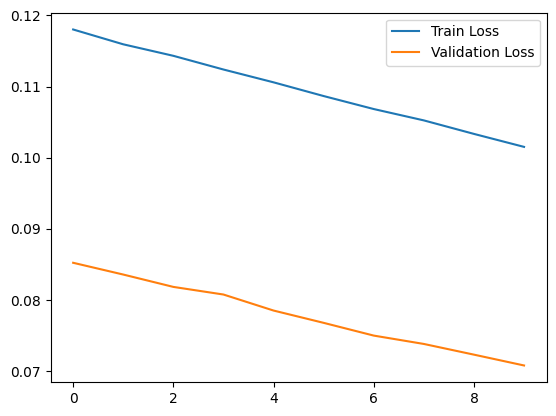

In [ ]:
plt.plot(train_running_loss_history, label = 'Train Loss')
plt.plot(validation_running_loss_history, label = 'Validation Loss')
plt.legend()

In [ ]:
class MultiUNetTestPatientDataset(Dataset):
    def __init__(self, transform = None,
                 augmented_dataset = False,
                 augment = 0, # this can be 0 (no augmentation), 5 (augment by 4 times plus original image), 8 and 15
                 threshold = False,
                 speckle = False,
                 despeckle = False,
                 number_of_image = 3,
                 crop = [1, 1, 1],
                 output = "FM"):
        self.root_dir = '/content/gdrive/MyDrive/Ultrasound Files- Minnesota + Boston Collaboration/cropped_images'
        self.patients = ['17042418', '9021218', '35080318', '58041919', '65050619']#, '6121817', '28062718', '12032118'] #'27061918', '50102518', '57032919', '67062119']
        self.transform = transform
        self.augment = augment
        self.threshold = threshold
        self.speckle = speckle
        self.augmented_dataset = augmented_dataset
        self.despeckle = despeckle
        self.number_of_image = number_of_image
        # Crop in the order of Abdomen, Biceps, and Quadriceps
        self.crop = crop
        self.output = output

    def __len__(self):
        return len(self.patients)

    def __getitem__(self, idx):
        patient_id = self.patients[idx]
        patient_path = os.path.join(self.root_dir, patient_id)
        images_A, images_B, images_Q = self.load_patient_data(patient_path)
        if self.output == "FM":
          return images_A, images_B, images_Q, test_labels_dict[int(patient_id)][0], test_labels_dict[int(patient_id)][2], test_labels_dict[int(patient_id)][3]
        if self.output == "FFM":
          return images_A, images_B, images_Q, test_labels_dict[int(patient_id)][1], test_labels_dict[int(patient_id)][2], test_labels_dict[int(patient_id)][3]

    def preprocess(self, img_path, MF_size, images, threshold, h, templateWindowSize, searchWindowSize, crop):
        image = Image.open(img_path)
        width, height = image.size
        crop_rectangle = (0, 0, width, round(height*crop))
        image = image.crop(crop_rectangle)
        if self.speckle:
          image = image.filter(ImageFilter.MedianFilter(size=MF_size))
        if self.threshold:
          image = torch.where(image < threshold/255, torch.tensor(0.0), image)
        if self.despeckle:
          image_np = np.array(image)
          despeckled_image = cv2.fastNlMeansDenoisingColored(image_np, None, h=10, templateWindowSize=7, searchWindowSize=21)
          image = Image.fromarray(despeckled_image)
        if not self.augmented_dataset:
          image = self.transform(image)
        images.append(image)

        ## Augmentation
        if self.augment >= 5:
          imx = image
          imx = TF.hflip(imx)
          images.append(imx)
          imx = TF.vflip(imx)
          images.append(imx)
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        if self.augment >= 8:
          imx = TF.vflip(imx)
          images.append(imx)
          angle = random.choice([15])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([45])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        if self.augment >= 15:
          imx = image
          angle = random.choice([-30, -90, -60, -45 -15, 0, 15, 30, 45, 60, 90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          imx = image
          angle = random.choice([-90])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          imx = image
          angle = random.choice([-60])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-45])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([-15])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([30])
          imx = TF.rotate(imx, angle)
          images.append(imx)
          angle = random.choice([60])
          imx = TF.rotate(imx, angle)
          images.append(imx)
        return images

    def load_patient_data(self, patient_path):
        images_A = []
        images_B = []
        images_Q = []
        threshold = 100
        AB = 0
        BICEP = 0
        QUAD = 0
        MF_size = 5
        h = 10
        templateWindowSize = 7
        searchWindowSize = 21
        for img_file in os.listdir(patient_path):
          # Process Abdomen images
          if 'AB' in img_file and AB < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images_A = self.preprocess(img_path, MF_size, images_A, threshold, h, templateWindowSize, searchWindowSize, self.crop[0])
              AB += 1
          # Process Bicep images
          elif 'BICEP' in img_file and BICEP < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images_B = self.preprocess(img_path, MF_size, images_B, threshold, h, templateWindowSize, searchWindowSize, self.crop[1])
              BICEP += 1
          # Process Quad images
          elif 'QUAD' in img_file and QUAD < self.number_of_image:
              img_path = os.path.join(patient_path, img_file)
              images_Q = self.preprocess(img_path, MF_size, images_Q, threshold, h, templateWindowSize, searchWindowSize, self.crop[2])
              QUAD += 1
        return images_A, images_B, images_Q

In [ ]:
normalization_factors = 0.5
tx_X = transforms.Compose([transforms.Resize((256, 256)),
                           transforms.ToTensor(),
                           transforms.Normalize(normalization_factors, normalization_factors)])
OUTPUT = "FM"
multi_UNet_dataset = MultiUNetTestPatientDataset(transform = tx_X,
                 augmented_dataset = False,
                 augment = 5,
                 threshold = False,
                 speckle = False,
                 despeckle = False,
                 number_of_image = 2,
                 crop = [1, 1, 1],
                 output = OUTPUT)

test_loader = DataLoader(multi_UNet_dataset, batch_size=1, shuffle=False)
print(len(test_loader))

5


In [ ]:
true_labels = []
prediction = []
for ith_batch, batch in enumerate(test_loader):
  images_A = [image.to('cuda') for image in batch[0]]
  images_B = [image.to('cuda') for image in batch[1]]
  images_Q = [image.to('cuda') for image in batch[2]]
  A_pred = UNet_A(images_A).unsqueeze(1)
  B_pred = UNet_B(images_B).unsqueeze(1)
  Q_pred = UNet_Q(images_Q).unsqueeze(1)
  print("Abdomen prediction:", A_pred)
  print("Biceps prediction:", B_pred)
  print("Quadriceps prediction:", Q_pred)
  combined_input = torch.cat((A_pred, B_pred, Q_pred), 1)
  y_train = batch[3].to('cuda').float()[0]
  y_pred = linear_model(combined_input).to('cuda').float()[0][0]
  # y_pred = (A_pred[0][0]+B_pred[0][0]+Q_pred[0][0])/3
  print("Ground truth:", y_train)
  print("Linear regression prediction based on A+B+Q:", y_pred)
  true_labels.append(y_train)
  prediction.append(y_pred)

Abdomen prediction: tensor([[0.1717]], device='cuda:0', grad_fn=<UnsqueezeBackward0>)
Biceps prediction: tensor([[0.1800]], device='cuda:0', grad_fn=<UnsqueezeBackward0>)
Quadriceps prediction: tensor([[0.1988]], device='cuda:0', grad_fn=<UnsqueezeBackward0>)
Ground truth: tensor(0.1880, device='cuda:0')
Linear regression prediction based on A+B+Q: tensor(-0.1037, device='cuda:0', grad_fn=<SelectBackward0>)
Abdomen prediction: tensor([[0.1820]], device='cuda:0', grad_fn=<UnsqueezeBackward0>)
Biceps prediction: tensor([[0.2049]], device='cuda:0', grad_fn=<UnsqueezeBackward0>)
Quadriceps prediction: tensor([[0.1645]], device='cuda:0', grad_fn=<UnsqueezeBackward0>)
Ground truth: tensor(0.1125, device='cuda:0')
Linear regression prediction based on A+B+Q: tensor(-0.1027, device='cuda:0', grad_fn=<SelectBackward0>)
Abdomen prediction: tensor([[0.1698]], device='cuda:0', grad_fn=<UnsqueezeBackward0>)
Biceps prediction: tensor([[0.1702]], device='cuda:0', grad_fn=<UnsqueezeBackward0>)
Quadric

In [ ]:
GT_FM = []
Pred_FM = []
for i in range(len(true_labels)):
  gt = torch.Tensor.tolist(true_labels[i])
  GT_FM.append(gt)
  pred = torch.Tensor.tolist(prediction[i])
  Pred_FM.append(pred)
print(GT_FM)
print(Pred_FM)

[0.18799999356269836, 0.11249999701976776, 0.15880000591278076, 0.1216999962925911, 0.22089999914169312]
[-0.10068091005086899, -0.10115548223257065, -0.10192520916461945, -0.10443884879350662, -0.10454237461090088]


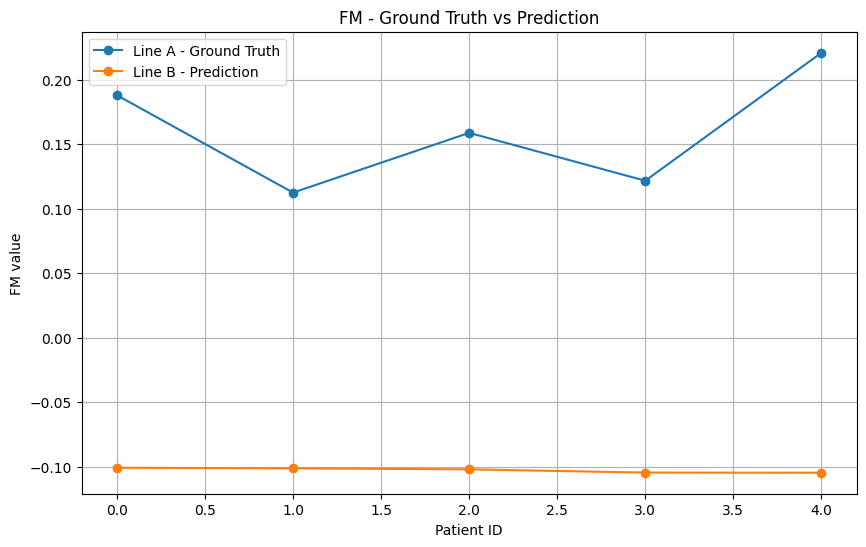

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(GT_FM, label=f'Line A - Ground Truth', marker='o')
plt.plot(Pred_FM, label=f'Line B - Prediction', marker='o')
plt.xlabel('Patient ID')
plt.ylabel('FM value')
plt.legend()
plt.title('FM - Ground Truth vs Prediction')
plt.grid(True)
plt.show()

In [ ]:
mse_list = []
for i in range(len(true_labels)):
  mse = F.mse_loss(true_labels[i], prediction[i])
  mse_list.append(mse.item())
average_mse = sum(mse_list) / len(mse_list)
print("Average MSE between true labels and predictions:", average_mse)

Average MSE between true labels and predictions: 0.07080289423465728


In [ ]:
def mean_absolute_error(y_true, y_pred):
    return torch.mean(torch.abs(y_true - y_pred))
def mean_squared_error(y_true, y_pred):
    return torch.mean((y_true - y_pred)**2)
def root_mean_squared_error(y_true, y_pred):
    return math.sqrt(torch.mean((y_true - y_pred)**2))
def mean_absolute_percentage_error(y_true, y_pred):
    return torch.mean(torch.abs((y_true - y_pred) / y_true)) * 100
def r_squared(y_true, y_pred):
    ss_residual = torch.sum((y_true - y_pred)**2)
    ss_total = torch.sum((y_true - torch.mean(y_true))**2)
    r2 = 1 - (ss_residual / ss_total)
    return r2

In [ ]:
y_true = torch.tensor(GT_FM)
y_pred = torch.tensor(Pred_FM)

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = root_mean_squared_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print("MAE:", mae.item())
print("MSE:", mse.item())
print("RMSE:", rmse)
print("MAPE:", mape.item())

MAE: 0.2629285454750061
MSE: 0.07080289721488953
RMSE: 0.26608813805746684
MAPE: 168.15931701660156
